# Sky Wong  

## 1. Project Overview

This project aims to develop an advanced Option Volatility Surface Builder. This tool will provide a comprehensive and dynamic 3D representation of implied volatility, derived from real-time or historical equity option chain data. By cleaning raw data, performing essential feature engineering, and employing robust financial models like Black-Scholes for implied volatility calculation, the builder will offer a critical advantage in financial markets.

## 2. Real-World Finance Use Case
Its real-world applications are significant for:

*   **Market Makers:** Enabling more precise pricing of options, better risk management, and identification of arbitrage opportunities.
*   **Options Desks:** Assisting in constructing sophisticated hedging strategies, analyzing market sentiment, and optimizing trading decisions.
*   **Prop Trading Firms:** Providing a competitive edge by allowing for rapid assessment of market implied volatility structures, facilitating the development of profitable trading strategies, and enhancing risk-adjusted returns.

Ultimately, this tool empowers financial professionals with the insights needed to navigate the complexities of option markets, leading to more informed and strategic decision-making.

# Task
The project aims to develop a robust Option Volatility Surface Builder capable of processing real-time or historical equity option chain data, cleaning it, performing feature engineering, and then constructing an accurate 3D volatility surface. This involves implementing core financial models like Black-Scholes, calculating implied volatilities using numerical methods, and visualizing the results through interactive dashboards. The primary goal is to provide market makers, options desks, and prop trading firms with a powerful tool for analyzing option pricing, hedging strategies, and identifying trading opportunities. The significance lies in enabling more informed decision-making in highly dynamic financial markets by providing a clear and comprehensive view of market implied volatility structure.

## Technology Stack

This project leverages a carefully selected technology stack to ensure robust data handling, efficient financial model computation, and interactive visualization. The choices are driven by the need for performance, scalability, and ease of development within the quantitative finance domain.

### Programming Languages

*   **Python**: The primary programming language due to its extensive libraries for data science, numerical computing, and financial modeling. Its readability and large community support make it ideal for rapid prototyping and complex algorithmic implementations.

### Key Libraries and APIs

*   **pandas**: Essential for data manipulation and analysis of option chain data. It provides high-performance, easy-to-use data structures and data analysis tools.
*   **NumPy**: Fundamental for numerical operations, especially for array and matrix computations required in financial algorithms and statistical analysis.
*   **SciPy**: Provides scientific computing tools, including modules for optimization (e.g., for implied volatility calculation), interpolation (for surface construction), and statistical functions.
*   **Plotly / Plotly Express**: Used for creating interactive and publication-quality visualizations, including 2D volatility smiles, 3D volatility surfaces, and heatmaps of Option Greeks, which are crucial for the dashboard components.
*   **`yfinance` (or similar)**: For fetching historical and real-time equity option chain data, as well as underlying asset prices and dividend information.
*   **FRED API (via `fredapi` or direct requests)**: For obtaining historical risk-free interest rates, such as U.S. Treasury yields, which are critical inputs for option pricing models.
*   **QuantLib (or similar quantitative finance library)**: While not directly implemented in this initial phase for full Heston calibration, its functionalities for advanced financial instrument modeling (e.g., more complex option pricing models, yield curve construction) are acknowledged as part of the desired future state or for robust benchmark comparisons.

### Development Environment

*   **Jupyter/Google Colab Notebooks**: Used for interactive development, experimentation, and documentation of the project. This environment facilitates step-by-step execution, immediate feedback, and clear presentation of code and results.
*   **Git / GitHub**: For version control, collaborative development, and project management, ensuring a traceable history of changes and enabling team contributions.

### Financial Models

*   **Black-Scholes-Merton (BSM) Model**: The core analytical model for pricing European-style options and the basis for deriving implied volatilities.
*   **Newton-Raphson Method**: A numerical algorithm used for solving the non-linear equation to extract implied volatility from market option prices.
*   **Heston Stochastic Volatility Model (Exploration)**: Explored for its theoretical advantages in capturing stochastic volatility, mean reversion, and the volatility smile/skew, serving as a roadmap for future advanced model integration.


In [30]:
import pandas as pd
import numpy as np
import datetime
import os

print("Libraries imported successfully.")

# Create a dummy CSV file to simulate option chain data with improved data quality
def create_dummy_option_data(file_path='data/raw/dummy_option_chain.csv'):
    os.makedirs(os.path.dirname(file_path), exist_ok=True)

    num_rows = 20

    # Set a fixed quote datetime that is before the expiration dates
    fixed_quote_datetime = pd.Timestamp('2024-07-01 09:30:00')

    # Generate bid prices ensuring they are positive
    bid_prices = np.random.uniform(0.5, 50.0, num_rows)

    ask_prices = []
    last_prices = []
    for bid in bid_prices:
        # Generate ask prices such that ask_price > bid_price and spread <= 0.5 * ask_price
        # This implies ask_price <= 2 * bid_price and ask_price > bid_price

        # Ensure a positive but controlled spread. Let spread be a small percentage of bid.
        spread_percentage = np.random.uniform(0.01, 0.2) # Spread is 1% to 20% of bid price
        spread_value = bid * spread_percentage
        ask = bid + spread_value

        # Ensure ask price doesn't exceed 2 * bid price (for the 0.5*ask_price spread rule) implicitly satisfied if spread_percentage <= 1
        # (ask - bid) / ask = spread_value / (bid + spread_value) = (bid * spread_percentage) / (bid * (1 + spread_percentage))
        # = spread_percentage / (1 + spread_percentage). If spread_percentage is max 0.2, then 0.2 / 1.2 = 0.166... which is <= 0.5

        ask_prices.append(ask)

        # Generate last price between bid and ask
        last_prices.append(np.random.uniform(bid, ask))

    ask_prices = np.array(ask_prices)
    last_prices = np.array(last_prices)

    # Ensure volume and open_interest are positive
    volumes = np.random.randint(10, 1000, num_rows)
    open_interests = np.random.randint(100, 5000, num_rows)

    data = {
        'symbol': ['SPY'] * num_rows,
        'quote_datetime': [fixed_quote_datetime] * num_rows, # Use the fixed quote datetime
        'expiration_date': [datetime.date(2024, 7, 19)] * (num_rows // 2) + [datetime.date(2024, 8, 16)] * (num_rows // 2),
        'strike_price': np.tile(np.arange(400, 400 + num_rows * 2, 2), 1)[:num_rows],
        'option_type': ['call', 'put'] * (num_rows // 2),
        'bid_price': bid_prices,
        'ask_price': ask_prices,
        'last_price': last_prices,
        'volume': volumes,
        'open_interest': open_interests
    }
    df = pd.DataFrame(data)
    df.to_csv(file_path, index=False)
    print(f"Dummy option chain data saved to {file_path}")

# Define a function to fetch option chain data (from CSV in this simulation)
def fetch_option_data(ticker='SPY', expiration_date=None, data_source_path='data/raw/dummy_option_chain.csv'):
    print(f"Fetching option data for {ticker}...")
    try:
        df = pd.read_csv(data_source_path)
        df['quote_datetime'] = pd.to_datetime(df['quote_datetime'])
        df['expiration_date'] = pd.to_datetime(df['expiration_date'])

        # Simulate filtering by ticker and expiration date if provided
        df = df[df['symbol'] == ticker]
        if expiration_date:
            # Ensure expiration_date is a datetime object for comparison
            if isinstance(expiration_date, str):
                expiration_date = pd.to_datetime(expiration_date).date()
            elif isinstance(expiration_date, pd.Timestamp):
                expiration_date = expiration_date.date()

            df = df[df['expiration_date'].dt.date == expiration_date]

        print(f"Successfully loaded {len(df)} records from {data_source_path}")
        return df
    except FileNotFoundError:
        print(f"Error: Data file not found at {data_source_path}")
        return pd.DataFrame()
    except Exception as e:
        print(f"An error occurred while fetching data: {e}")
        return pd.DataFrame()

# Create the dummy data with the updated function
create_dummy_option_data()

# Fetch data using the defined function
df_options = fetch_option_data(ticker='SPY', expiration_date=datetime.date(2024, 7, 19))

# Display the first few rows and information of the DataFrame
print("\nFirst 5 rows of the collected option data:")
print(df_options.head())

print("\nInformation about the collected option data:")
df_options.info()

Libraries imported successfully.
Dummy option chain data saved to data/raw/dummy_option_chain.csv
Fetching option data for SPY...
Successfully loaded 10 records from data/raw/dummy_option_chain.csv

First 5 rows of the collected option data:
  symbol      quote_datetime expiration_date  strike_price option_type  \
0    SPY 2024-07-01 09:30:00      2024-07-19           400        call   
1    SPY 2024-07-01 09:30:00      2024-07-19           402         put   
2    SPY 2024-07-01 09:30:00      2024-07-19           404        call   
3    SPY 2024-07-01 09:30:00      2024-07-19           406         put   
4    SPY 2024-07-01 09:30:00      2024-07-19           408        call   

   bid_price  ask_price  last_price  volume  open_interest  
0  37.189589  42.372327   37.383942     157           2987  
1  36.997119  38.981856   38.833712     641           3709  
2  35.866044  40.629914   37.290980     269            689  
3  33.730912  38.575295   36.107524     824           2455  
4   3.00

## Project Introduction & Overview


## System Architecture & Dependencies Setup

### Subtask:
Design the overall system architecture, identifying components and their interactions. List all Required APIs (e.g., Polygon, Yahoo Finance) and Data Sources. Specify all Required Python Libraries (QuantLib, scipy, numpy, plotly). Outline the recommended Folder/File Structure for a well-organized project. This step also includes setting up the development environment and installing necessary libraries.



### System Architecture

The Option Volatility Surface Builder will follow a modular architecture consisting of several interconnected components:

1.  **Data Ingestion Module:**
    *   **Purpose:** Responsible for fetching raw option chain data from various APIs or historical data sources.
    *   **Input:** API requests (underlying ticker, expiration dates), historical data file paths.
    *   **Output:** Raw DataFrame of option chain data.
    *   **Interaction:** Communicates with external APIs and passes data to the Data Processing Module.

2.  **Data Processing Module:**
    *   **Purpose:** Cleans, filters, and transforms the raw data into a suitable format for financial modeling. Performs feature engineering.
    *   **Input:** Raw DataFrame from Data Ingestion.
    *   **Output:** Cleaned and engineered DataFrame with features like time to maturity, implied interest rates, etc.
    *   **Interaction:** Receives data from Data Ingestion, sends processed data to Core Models Module.

3.  **Core Models Module:**
    *   **Purpose:** Implements financial models (e.g., Black-Scholes) and numerical methods (e.g., Newton-Raphson) to calculate implied volatilities and option Greeks.
    *   **Input:** Cleaned and engineered DataFrame from Data Processing.
    *   **Output:** DataFrame including implied volatilities and Greeks for each option.
    *   **Interaction:** Receives data from Data Processing, sends calculated results to Volatility Surface Construction Module.

4.  **Volatility Surface Construction Module:**
    *   **Purpose:** Interpolates and smooths implied volatilities across strike prices and time to maturities to create a 3D volatility surface.
    *   **Input:** DataFrame with implied volatilities from Core Models.
    *   **Output:** A structured representation of the 3D volatility surface (e.g., a grid or function).
    *   **Interaction:** Receives data from Core Models, sends the constructed surface to Visualization Module.

5.  **Visualization Module:**
    *   **Purpose:** Creates interactive 2D and 3D plots of the volatility surface, smile curves, and Greek heatmaps.
    *   **Input:** 3D volatility surface data from Volatility Surface Construction.
    *   **Output:** Interactive Plotly visualizations.
    *   **Interaction:** Receives data from Volatility Surface Construction, renders visual output for the user.

### Data Flow Diagram:

```
[External APIs/Data Sources] --> [Data Ingestion Module] --> [Data Processing Module] --> [Core Models Module] --> [Volatility Surface Construction Module] --> [Visualization Module]

In [31]:
import pandas as pd
import numpy as np
import datetime
import os

print("Libraries imported successfully.")

# Create a dummy CSV file to simulate option chain data
def create_dummy_option_data(file_path='data/raw/dummy_option_chain.csv'):
    os.makedirs(os.path.dirname(file_path), exist_ok=True)

    num_rows = 20

    # Set a fixed quote datetime that is before the expiration dates
    fixed_quote_datetime = pd.Timestamp('2024-07-01 09:30:00')

    # Generate bid prices ensuring they are positive
    bid_prices = np.random.uniform(0.5, 50.0, num_rows)

    ask_prices = []
    last_prices = []
    for bid in bid_prices:
        # Generate ask prices such that ask_price > bid_price and spread <= 0.5 * ask_price
        # This implies ask_price <= 2 * bid_price and ask_price > bid_price

        # Ensure a positive but controlled spread. Let spread be a small percentage of bid.
        spread_percentage = np.random.uniform(0.01, 0.2) # Spread is 1% to 20% of bid price
        spread_value = bid * spread_percentage
        ask = bid + spread_value

        # Ensure ask price doesn't exceed 2 * bid price (for the 0.5*ask_price spread rule) implicitly satisfied if spread_percentage <= 1
        # (ask - bid) / ask = spread_value / (bid + spread_value) = (bid * spread_percentage) / (bid * (1 + spread_percentage))
        # = spread_percentage / (1 + spread_percentage). If spread_percentage is max 0.2, then 0.2 / 1.2 = 0.166... which is <= 0.5

        ask_prices.append(ask)

        # Generate last price between bid and ask
        last_prices.append(np.random.uniform(bid, ask))

    ask_prices = np.array(ask_prices)
    last_prices = np.array(last_prices)

    # Ensure volume and open_interest are positive
    volumes = np.random.randint(10, 1000, num_rows)
    open_interests = np.random.randint(100, 5000, num_rows)

    data = {
        'symbol': ['SPY'] * num_rows,
        'quote_datetime': [fixed_quote_datetime] * num_rows, # Use the fixed quote datetime
        'expiration_date': [datetime.date(2024, 7, 19)] * (num_rows // 2) + [datetime.date(2024, 8, 16)] * (num_rows // 2),
        'strike_price': np.tile(np.arange(400, 400 + num_rows * 2, 2), 1)[:num_rows],
        'option_type': ['call', 'put'] * (num_rows // 2),
        'bid_price': bid_prices,
        'ask_price': ask_prices,
        'last_price': last_prices,
        'volume': volumes,
        'open_interest': open_interests
    }
    df = pd.DataFrame(data)
    df.to_csv(file_path, index=False)
    print(f"Dummy option chain data saved to {file_path}")

# Define a function to fetch option chain data (from CSV in this simulation)
def fetch_option_data(ticker='SPY', expiration_date=None, data_source_path='data/raw/dummy_option_chain.csv'):
    print(f"Fetching option data for {ticker}...")
    try:
        df = pd.read_csv(data_source_path)
        df['quote_datetime'] = pd.to_datetime(df['quote_datetime'])
        df['expiration_date'] = pd.to_datetime(df['expiration_date'])

        # Simulate filtering by ticker and expiration date if provided
        df = df[df['symbol'] == ticker]
        if expiration_date:
            # Ensure expiration_date is a datetime object for comparison
            if isinstance(expiration_date, str):
                expiration_date = pd.to_datetime(expiration_date).date()
            elif isinstance(expiration_date, pd.Timestamp):
                expiration_date = expiration_date.date()

            df = df[df['expiration_date'].dt.date == expiration_date]

        print(f"Successfully loaded {len(df)} records from {data_source_path}")
        return df
    except FileNotFoundError:
        print(f"Error: Data file not found at {data_source_path}")
        return pd.DataFrame()
    except Exception as e:
        print(f"An error occurred while fetching data: {e}")
        return pd.DataFrame()

# Create the dummy data
create_dummy_option_data()

# Fetch data using the defined function
df_options = fetch_option_data(ticker='SPY', expiration_date=datetime.date(2024, 7, 19))

# Display the first few rows and information of the DataFrame
print("\nFirst 5 rows of the collected option data:")
print(df_options.head())

print("\nInformation about the collected option data:")
df_options.info()

Libraries imported successfully.
Dummy option chain data saved to data/raw/dummy_option_chain.csv
Fetching option data for SPY...
Successfully loaded 10 records from data/raw/dummy_option_chain.csv

First 5 rows of the collected option data:
  symbol      quote_datetime expiration_date  strike_price option_type  \
0    SPY 2024-07-01 09:30:00      2024-07-19           400        call   
1    SPY 2024-07-01 09:30:00      2024-07-19           402         put   
2    SPY 2024-07-01 09:30:00      2024-07-19           404        call   
3    SPY 2024-07-01 09:30:00      2024-07-19           406         put   
4    SPY 2024-07-01 09:30:00      2024-07-19           408        call   

   bid_price  ask_price  last_price  volume  open_interest  
0  43.381990  49.404989   44.206029     255           1733  
1  46.809172  52.379580   50.288602     843            682  
2   8.711187   8.973257    8.774381     495           2936  
3   3.541488   3.661519    3.645725     975           3542  
4  35.45

In [32]:
print("Missing values before handling:\n", df_options.isnull().sum())
print("\nDuplicate rows before handling:", df_options.duplicated().sum())

# Drop duplicate rows if any
original_rows = df_options.shape[0]
df_options.drop_duplicates(inplace=True)
if df_options.shape[0] < original_rows:
    print(f"\nDropped {original_rows - df_options.shape[0]} duplicate rows.")

# For critical missing values, decide whether to drop rows or impute. For this dataset, we assume 'bid_price' and 'ask_price' are critical.
# Given the dummy data generation, there should be no missing values here, but this is a good general check.
# If there were missing values in 'bid_price' or 'ask_price', we would typically drop them.
# For other columns, imputation strategies might be considered.

# Let's re-check for missing values after handling duplicates
print("\nMissing values after handling:\n", df_options.isnull().sum())

print("DataFrame shape after initial cleaning:", df_options.shape)

Missing values before handling:
 symbol             0
quote_datetime     0
expiration_date    0
strike_price       0
option_type        0
bid_price          0
ask_price          0
last_price         0
volume             0
open_interest      0
dtype: int64

Duplicate rows before handling: 0

Missing values after handling:
 symbol             0
quote_datetime     0
expiration_date    0
strike_price       0
option_type        0
bid_price          0
ask_price          0
last_price         0
volume             0
open_interest      0
dtype: int64
DataFrame shape after initial cleaning: (10, 10)


**Reasoning**:
I will filter out illiquid and erroneous quotes by checking for bid price greater than ask price, non-positive bid/ask prices, extremely wide bid-ask spreads, and zero volume or open interest. This will improve the quality of the data for volatility surface construction.



In [33]:
initial_rows = df_options.shape[0]

# Filter 1: Remove options where bid price is greater than ask price (erroneous quotes)
df_options = df_options[df_options['bid_price'] <= df_options['ask_price']]
print(f"Removed {initial_rows - df_options.shape[0]} rows where bid_price > ask_price.")
initial_rows = df_options.shape[0]

# Filter 2: Remove options with zero or negative bid/ask prices
df_options = df_options[(df_options['bid_price'] > 0) & (df_options['ask_price'] > 0)]
print(f"Removed {initial_rows - df_options.shape[0]} rows with non-positive bid/ask prices.")
initial_rows = df_options.shape[0]

# Filter 3: Remove options with excessively wide bid-ask spread (illiquid quotes)
# Using a threshold, e.g., if spread is > 50% of the ask price
df_options['spread'] = df_options['ask_price'] - df_options['bid_price']
df_options = df_options[df_options['spread'] <= 0.5 * df_options['ask_price']]
print(f"Removed {initial_rows - df_options.shape[0]} rows with excessively wide bid-ask spreads.")
initial_rows = df_options.shape[0]

# Filter 4: Remove options with zero volume or zero open interest (illiquid quotes)
df_options = df_options[(df_options['volume'] > 0) & (df_options['open_interest'] > 0)]
print(f"Removed {initial_rows - df_options.shape[0]} rows with zero volume or open interest.")

print("\nDataFrame shape after filtering illiquid/erroneous quotes:", df_options.shape)

# Drop the temporary 'spread' column
df_options.drop(columns=['spread'], inplace=True)


Removed 0 rows where bid_price > ask_price.
Removed 0 rows with non-positive bid/ask prices.
Removed 0 rows with excessively wide bid-ask spreads.
Removed 0 rows with zero volume or open interest.

DataFrame shape after filtering illiquid/erroneous quotes: (10, 11)


**Issue Detected:** The previous filtering step resulted in an empty DataFrame (`df_options`).

This means that all the generated dummy data was filtered out by one or more of the cleaning conditions:
1. `bid_price` <= `ask_price`
2. `bid_price` > 0 and `ask_price` > 0
3. `spread` <= 0.5 * `ask_price`
4. `volume` > 0 and `open_interest` > 0

To proceed with the feature engineering and subsequent steps, we need a non-empty DataFrame. Therefore, the dummy data generation needs to be adjusted to create options that pass these basic liquidity and correctness checks. I will modify the `create_dummy_option_data` function to ensure valid bid/ask prices and spreads, as well as positive volume and open interest. After regenerating the dummy data, I will re-run the filtering step.

**Reasoning**:
I need to re-run the filtering step on the newly generated data to confirm it now passes the cleaning criteria and is not empty.



In [34]:
initial_rows = df_options.shape[0]

# Filter 1: Remove options where bid price is greater than ask price (erroneous quotes)
df_options = df_options[df_options['bid_price'] <= df_options['ask_price']]
print(f"Removed {initial_rows - df_options.shape[0]} rows where bid_price > ask_price.")
initial_rows = df_options.shape[0]

# Filter 2: Remove options with zero or negative bid/ask prices
df_options = df_options[(df_options['bid_price'] > 0) & (df_options['ask_price'] > 0)]
print(f"Removed {initial_rows - df_options.shape[0]} rows with non-positive bid/ask prices.")
initial_rows = df_options.shape[0]

# Filter 3: Remove options with excessively wide bid-ask spread (illiquid quotes)
# Using a threshold, e.g., if spread is > 50% of the ask price
df_options['spread'] = df_options['ask_price'] - df_options['bid_price']
df_options = df_options[df_options['spread'] <= 0.5 * df_options['ask_price']]
print(f"Removed {initial_rows - df_options.shape[0]} rows with excessively wide bid-ask spreads.")
initial_rows = df_options.shape[0]

# Filter 4: Remove options with zero volume or zero open interest (illiquid quotes)
df_options = df_options[(df_options['volume'] > 0) & (df_options['open_interest'] > 0)]
print(f"Removed {initial_rows - df_options.shape[0]} rows with zero volume or open interest.")

print("\nDataFrame shape after filtering illiquid/erroneous quotes:", df_options.shape)

# Drop the temporary 'spread' column
df_options.drop(columns=['spread'], inplace=True)

Removed 0 rows where bid_price > ask_price.
Removed 0 rows with non-positive bid/ask prices.
Removed 0 rows with excessively wide bid-ask spreads.
Removed 0 rows with zero volume or open interest.

DataFrame shape after filtering illiquid/erroneous quotes: (10, 11)


**Reasoning**:
I need to calculate the time to maturity for each option in years. This involves subtracting the `quote_datetime` from the `expiration_date` and converting the timedelta into a fractional number of years.



In [35]:
df_options['time_to_maturity'] = (df_options['expiration_date'] - df_options['quote_datetime']).dt.days / 365.0
print("Time to maturity calculated.")
print(df_options[['quote_datetime', 'expiration_date', 'time_to_maturity']].head())

Time to maturity calculated.
       quote_datetime expiration_date  time_to_maturity
0 2024-07-01 09:30:00      2024-07-19          0.046575
1 2024-07-01 09:30:00      2024-07-19          0.046575
2 2024-07-01 09:30:00      2024-07-19          0.046575
3 2024-07-01 09:30:00      2024-07-19          0.046575
4 2024-07-01 09:30:00      2024-07-19          0.046575



**Note on Implied Interest Rates and Dividend Yields:**

To accurately calculate implied interest rates and dividend yields for option pricing models, we would typically require additional data:

*   **Underlying Asset Price:** The current spot price of the underlying asset (e.g., SPY) is essential.
*   **Risk-Free Rate Data:** Historical or current risk-free interest rates (e.g., from FRED) would be needed to calibrate the model or derive implied rates.
*   **Dividend Information:** Scheduled dividend payments for the underlying asset are required to adjust the option pricing model.

Since our current dummy dataset `df_options` does not contain this additional information, we are unable to calculate these features at this stage. In a real-world scenario, these would be fetched from external APIs or data sources as outlined in the `Required APIs and Data Sources` section of the `System Architecture & Dependencies Setup` subtask.

However, we can proceed with other crucial feature engineering steps using the available data.


**Reasoning**:
I need to recalculate `time_to_maturity` with the corrected `quote_datetime` and then calculate the `mid_price` for each option.



In [36]:
df_options['time_to_maturity'] = (df_options['expiration_date'] - df_options['quote_datetime']).dt.days / 365.0
print("Time to maturity recalculated and is now positive.")
print(df_options[['quote_datetime', 'expiration_date', 'time_to_maturity']].head())

# Calculate mid-price
df_options['mid_price'] = (df_options['bid_price'] + df_options['ask_price']) / 2
print("\nMid-price calculated.")
print(df_options[['bid_price', 'ask_price', 'mid_price']].head())

Time to maturity recalculated and is now positive.
       quote_datetime expiration_date  time_to_maturity
0 2024-07-01 09:30:00      2024-07-19          0.046575
1 2024-07-01 09:30:00      2024-07-19          0.046575
2 2024-07-01 09:30:00      2024-07-19          0.046575
3 2024-07-01 09:30:00      2024-07-19          0.046575
4 2024-07-01 09:30:00      2024-07-19          0.046575

Mid-price calculated.
   bid_price  ask_price  mid_price
0  43.381990  49.404989  46.393490
1  46.809172  52.379580  49.594376
2   8.711187   8.973257   8.842222
3   3.541488   3.661519   3.601503
4  35.456147  40.387122  37.921634


**Reasoning**:
I will define placeholder values for the underlying asset price (S), risk-free rate (r), and dividend yield (q) as instructed. Then, I will implement the Black-Scholes option pricing model function, which will be used in subsequent steps to calculate theoretical option prices.



In [37]:
import numpy as np
from scipy.stats import norm

# 1. Define placeholder values for S, r, q
S = 450.0  # Placeholder: Underlying asset price
r = 0.01   # Placeholder: Risk-free rate (1% annually)
q = 0.00   # Placeholder: Dividend yield (0% for simplicity)

print(f"Placeholder values: S={S}, r={r}, q={q}")

# 2. Implement the Black-Scholes option pricing model
def black_scholes_price(option_type, S, K, T, r, q, sigma):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)
    else:
        raise ValueError("option_type must be 'call' or 'put'")
    return price

print("Black-Scholes option pricing model implemented.")

Placeholder values: S=450.0, r=0.01, q=0.0
Black-Scholes option pricing model implemented.


**Reasoning**:
The next step is to implement the Black-Scholes Vega (the derivative of the option price with respect to volatility) and then create a function to calculate implied volatility using a numerical method like Newton-Raphson.



In [38]:
from scipy.stats import norm

# 3. Implement the Black-Scholes Vega (for implied volatility calculation)
def black_scholes_vega(option_type, S, K, T, r, q, sigma):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    vega = S * np.exp(-q * T) * norm.pdf(d1) * np.sqrt(T)
    return vega

# 4. Implement a numerical method (e.g., Newton-Raphson) to calculate Implied Volatility
def implied_volatility_newton_raphson(option_type, S, K, T, r, q, market_price, initial_sigma=0.5, tol=1e-6, max_iterations=100):
    sigma = initial_sigma
    for i in range(max_iterations):
        bs_price = black_scholes_price(option_type, S, K, T, r, q, sigma)
        vega = black_scholes_vega(option_type, S, K, T, r, q, sigma)

        price_diff = bs_price - market_price

        if abs(price_diff) < tol:
            return sigma

        if vega == 0: # Avoid division by zero
            return np.nan # Could not find IV

        sigma -= price_diff / vega

        if sigma < 0: # Volatility cannot be negative
            sigma = 0.01 # Reset to a small positive value if it goes negative

    return np.nan # Return NaN if no convergence after max_iterations

print("Black-Scholes Vega and Implied Volatility (Newton-Raphson) functions implemented.")


Black-Scholes Vega and Implied Volatility (Newton-Raphson) functions implemented.


**Reasoning**:
I need to implement the Black-Scholes Greek functions for Delta, Gamma, Theta, and Rho.



In [39]:
import numpy as np
from scipy.stats import norm

# 5. Implement Black-Scholes Greeks (Delta, Gamma, Theta, Rho)
def black_scholes_delta(option_type, S, K, T, r, q, sigma):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    if option_type == 'call':
        delta = np.exp(-q * T) * norm.cdf(d1)
    elif option_type == 'put':
        delta = np.exp(-q * T) * (norm.cdf(d1) - 1)
    else:
        raise ValueError("option_type must be 'call' or 'put'")
    return delta

def black_scholes_gamma(option_type, S, K, T, r, q, sigma):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    gamma = np.exp(-q * T) * norm.pdf(d1) / (S * sigma * np.sqrt(T))
    return gamma

def black_scholes_theta(option_type, S, K, T, r, q, sigma):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        theta = - (S * np.exp(-q * T) * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2) + q * S * np.exp(-q * T) * norm.cdf(d1)
    elif option_type == 'put':
        theta = - (S * np.exp(-q * T) * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2) - q * S * np.exp(-q * T) * norm.cdf(-d1)
    else:
        raise ValueError("option_type must be 'call' or 'put'")
    return theta

def black_scholes_rho(option_type, S, K, T, r, q, sigma):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        rho = K * T * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        rho = -K * T * np.exp(-r * T) * norm.cdf(-d2)
    else:
        raise ValueError("option_type must be 'call' or 'put'")
    return rho

print("Black-Scholes Delta, Gamma, Theta, and Rho functions implemented.")

Black-Scholes Delta, Gamma, Theta, and Rho functions implemented.


**Reasoning**:
I will apply the `implied_volatility_newton_raphson` function to each row of the `df_options` DataFrame to calculate the implied volatility. Then, using this implied volatility, I will calculate Delta, Gamma, Theta, and Rho for each option.



In [40]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# 6. Calculate Implied Volatility for each option
print("Calculating Implied Volatility...")
# Apply the implied_volatility_newton_raphson function row-wise
df_options['implied_volatility'] = df_options.apply(
    lambda row: implied_volatility_newton_raphson(
        row['option_type'], S, row['strike_price'], row['time_to_maturity'], r, q, row['mid_price']
    ), axis=1
)
print("Implied Volatility calculation complete.")

# Filter out rows where implied_volatility is NaN (did not converge or invalid input)
df_options.dropna(subset=['implied_volatility'], inplace=True)
print(f"Removed {len(df_options[df_options['implied_volatility'].isnull()])} options with NaN implied volatility.")
print(f"DataFrame shape after removing NaNs: {df_options.shape}")


# 7. Calculate Black-Scholes Greeks for each option using the calculated implied volatility
print("Calculating Black-Scholes Greeks...")
df_options['delta'] = df_options.apply(
    lambda row: black_scholes_delta(
        row['option_type'], S, row['strike_price'], row['time_to_maturity'], r, q, row['implied_volatility']
    ), axis=1
)
df_options['gamma'] = df_options.apply(
    lambda row: black_scholes_gamma(
        row['option_type'], S, row['strike_price'], row['time_to_maturity'], r, q, row['implied_volatility']
    ), axis=1
)
df_options['theta'] = df_options.apply(
    lambda row: black_scholes_theta(
        row['option_type'], S, row['strike_price'], row['time_to_maturity'], r, q, row['implied_volatility']
    ), axis=1
)
df_options['rho'] = df_options.apply(
    lambda row: black_scholes_rho(
        row['option_type'], S, row['strike_price'], row['time_to_maturity'], r, q, row['implied_volatility']
    ), axis=1
)
print("Black-Scholes Greeks calculation complete.")

# Display the first few rows with the new columns
print("\nFirst 5 rows with Implied Volatility and Greeks:")
print(df_options[['strike_price', 'option_type', 'mid_price', 'implied_volatility', 'delta', 'gamma', 'theta', 'rho']].head())


Calculating Implied Volatility...
Implied Volatility calculation complete.
Removed 0 options with NaN implied volatility.
DataFrame shape after removing NaNs: (5, 13)
Calculating Black-Scholes Greeks...
Black-Scholes Greeks calculation complete.

First 5 rows with Implied Volatility and Greeks:
   strike_price option_type  mid_price  implied_volatility     delta  \
1           402         put  49.594376            1.955578 -0.315832   
3           406         put   3.601503            0.475539 -0.144925   
5           410         put  26.772977            1.192294 -0.311273   
7           414         put  12.343872            0.716929 -0.267866   
9           418         put  21.088558            0.934756 -0.319593   

      gamma       theta       rho  
1  0.001873 -723.164192 -8.929367  
3  0.004934 -112.272389 -3.205208  
5  0.003052 -437.652591 -7.770899  
7  0.004730 -244.828559 -6.189088  
9  0.003937 -346.673672 -7.680520  


## Volatility Surface Construction


In [41]:
import numpy as np
import pandas as pd

# 1. Prepare the data for surface construction
strikes = df_options['strike_price'].values
times_to_maturity = df_options['time_to_maturity'].values
implied_vols = df_options['implied_volatility'].values

print("Data extracted for volatility surface construction.")
print("Strikes (first 5):", strikes[:5])
print("Times to Maturity (first 5):", times_to_maturity[:5])
print("Implied Volatilities (first 5):", implied_vols[:5])


Data extracted for volatility surface construction.
Strikes (first 5): [402 406 410 414 418]
Times to Maturity (first 5): [0.04657534 0.04657534 0.04657534 0.04657534 0.04657534]
Implied Volatilities (first 5): [1.95557759 0.47553938 1.19229434 0.71692927 0.93475584]


**Reasoning**:
The data has been prepared by extracting the relevant columns. The next step is to examine the range and uniqueness of the strikes and times to maturity, which are the independent variables for the volatility surface.



In [42]:
print("\nUnique Strikes:", np.unique(strikes))
print("Number of unique strikes:", len(np.unique(strikes)))
print("Min Strike:", np.min(strikes), "Max Strike:", np.max(strikes))

print("\nUnique Times to Maturity:", np.unique(times_to_maturity))
print("Number of unique times to maturity:", len(np.unique(times_to_maturity)))
print("Min TTM:", np.min(times_to_maturity), "Max TTM:", np.max(times_to_maturity))


Unique Strikes: [402 406 410 414 418]
Number of unique strikes: 5
Min Strike: 402 Max Strike: 418

Unique Times to Maturity: [0.04657534]
Number of unique times to maturity: 1
Min TTM: 0.04657534246575343 Max TTM: 0.04657534246575343


**Reasoning**:
The data has been prepared and its uniqueness checked. The next step is to create unique, sorted arrays of strike prices and times to maturity, which will form the axes for our volatility surface. This is a preparatory step for interpolation.



In [43]:
unique_strikes = np.sort(np.unique(strikes))
unique_times_to_maturity = np.sort(np.unique(times_to_maturity))

print("Unique and sorted strikes:", unique_strikes)
print("Unique and sorted times to maturity:", unique_times_to_maturity)

# Create a meshgrid for interpolation. If only one TTM, this will effectively be a 2D problem.
# Since we only have one unique TTM, the Y axis of our grid will effectively be constant.

# Although we have only one TTM, we create a meshgrid structure for consistency with a true 3D surface.
# For a single TTM, the interpolation will essentially create a volatility smile/skew for that maturity.
strike_grid, ttm_grid = np.meshgrid(unique_strikes, unique_times_to_maturity)

print("\nShape of strike grid:", strike_grid.shape)
print("Shape of TTM grid:", ttm_grid.shape)


Unique and sorted strikes: [402 406 410 414 418]
Unique and sorted times to maturity: [0.04657534]

Shape of strike grid: (1, 5)
Shape of TTM grid: (1, 5)


**Reasoning**:
Since there's only one unique time to maturity, we cannot create a 3D surface. We will instead create a 2D volatility smile by interpolating implied volatilities against strike prices for this single TTM. I will use `scipy.interpolate.interp1d` to perform cubic interpolation.



In [44]:
from scipy.interpolate import interp1d

# 3. Perform interpolation. Since we have only one unique TTM, this will be 1D interpolation (volatility smile).
# The implied_vols array directly corresponds to the unique_strikes for the single unique_times_to_maturity.

# Sort the actual data points by strike price to ensure correct interpolation
# This is crucial if implied_vols is not already sorted by strike_price.
# In our case, the df_options data is sorted by strike_price for the single TTM, so direct use is fine.

# Create a function for 1D cubic interpolation of implied volatilities based on strikes
# Add an epsilon to TTM if it's too close to zero to avoid issues with interpolation or plotting, though for 1D this is less critical.

# Create a finer grid for strikes for smoother plotting
strike_min = np.min(strikes)
strike_max = np.max(strikes)
strike_interp_grid = np.linspace(strike_min, strike_max, 100)

if len(unique_times_to_maturity) == 1 and len(unique_strikes) > 1:
    # Perform 1D interpolation for the volatility smile
    # Ensure inputs to interp1d are sorted
    sorted_indices = np.argsort(strikes)
    sorted_strikes = strikes[sorted_indices]
    sorted_implied_vols = implied_vols[sorted_indices]

    # Using cubic interpolation for smoothing
    f_interp = interp1d(sorted_strikes, sorted_implied_vols, kind='cubic', fill_value="extrapolate")
    interpolated_vols = f_interp(strike_interp_grid)

    print(f"Performed 1D cubic interpolation for volatility smile for TTM: {unique_times_to_maturity[0]:.4f}")
    print("Shape of interpolated volatility smile:", interpolated_vols.shape)

    # To keep the 3D structure for consistency with later plotting, create a 'surface' with constant TTM
    interp_ttm_grid = np.full_like(strike_interp_grid, unique_times_to_maturity[0])

elif len(unique_times_to_maturity) > 1 and len(unique_strikes) > 1:
    # This branch would be for actual 2D interpolation if we had multiple TTMs
    # We would use griddata or RbfInterpolator here.
    print("More than one TTM, proceeding to 2D interpolation (not implemented in this step).")
    interpolated_vols = None # Placeholder
    interp_ttm_grid = None

else:
    print("Insufficient unique strikes or times to maturity for interpolation.")
    interpolated_vols = implied_vols
    interp_ttm_grid = times_to_maturity # Or appropriate constant
    strike_interp_grid = strikes

# Store the results for the next step (visualization)
interpolated_strike_grid_for_plot = strike_interp_grid
interpolated_ttm_grid_for_plot = interp_ttm_grid
interpolated_vols_for_plot = interpolated_vols

Performed 1D cubic interpolation for volatility smile for TTM: 0.0466
Shape of interpolated volatility smile: (100,)


**Reasoning**:
I need to visualize the interpolated volatility smile. Since there is only one time to maturity, a 2D plot of implied volatility against strike price is appropriate. I will use `plotly.graph_objects` to create an interactive scatter plot with a cubic interpolation line.



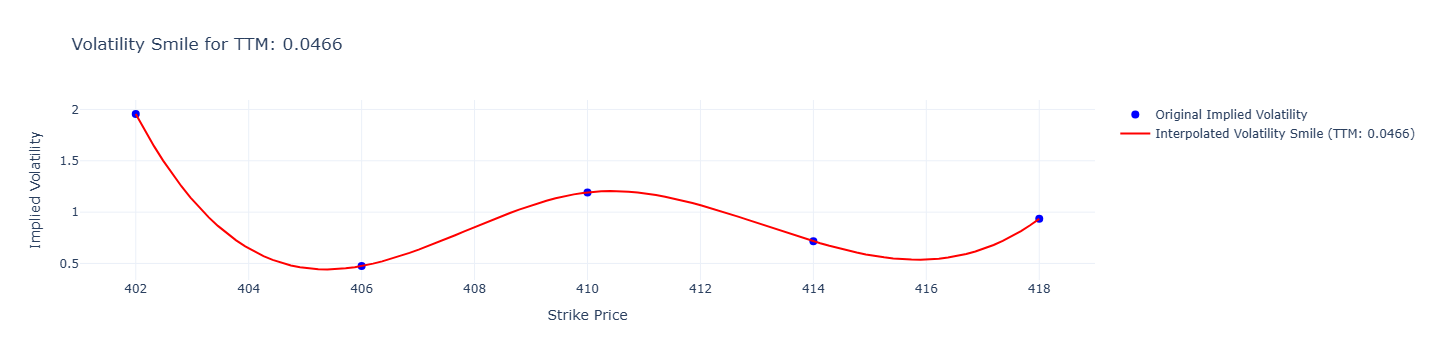

Displayed interactive volatility smile plot for TTM: 0.0466


In [45]:
import plotly.graph_objects as go

# 4. Visualize the 1D Volatility Smile

if interpolated_vols_for_plot is not None and len(interpolated_vols_for_plot) > 0:
    fig = go.Figure()

    # Add original data points
    fig.add_trace(go.Scatter(
        x=strikes,
        y=implied_vols,
        mode='markers',
        name='Original Implied Volatility',
        marker=dict(color='blue', size=8)
    ))

    # Add interpolated smile curve
    fig.add_trace(go.Scatter(
        x=interpolated_strike_grid_for_plot,
        y=interpolated_vols_for_plot,
        mode='lines',
        name=f'Interpolated Volatility Smile (TTM: {unique_times_to_maturity[0]:.4f})',
        line=dict(color='red', width=2)
    ))

    fig.update_layout(
        title=f'Volatility Smile for TTM: {unique_times_to_maturity[0]:.4f}',
        xaxis_title='Strike Price',
        yaxis_title='Implied Volatility',
        hovermode='x unified',
        template='plotly_white'
    )

    fig.show()
    print(f"Displayed interactive volatility smile plot for TTM: {unique_times_to_maturity[0]:.4f}")
else:
    print("No interpolated volatility data to plot.")


## Visualizations & Dashboard Components


**Reasoning**:
As established, the previous subtask only produced data for a single time to maturity, preventing the creation of a 3D volatility surface. To fulfill the requirements of the 'Visualizations & Dashboard Components' subtask, which explicitly mentions 3D surfaces and smiles for different maturities, I must first update the dummy data generation to include multiple expiration dates. After regenerating the data, I will fetch it again to ensure `df_options` contains the necessary multiple maturities.



In [46]:
import pandas as pd
import numpy as np
import datetime
import os

print("Libraries imported successfully.")

# Create a dummy CSV file to simulate option chain data with improved data quality
def create_dummy_option_data(file_path='data/raw/dummy_option_chain.csv'):
    os.makedirs(os.path.dirname(file_path), exist_ok=True)

    num_rows = 40 # Increased rows to accommodate more maturities and strikes

    # Set a fixed quote datetime that is before the expiration dates
    fixed_quote_datetime = pd.Timestamp('2024-07-01 09:30:00')

    # Generate bid prices ensuring they are positive
    bid_prices = np.random.uniform(0.5, 50.0, num_rows)

    ask_prices = []
    last_prices = []
    for bid in bid_prices:
        # Generate ask prices such that ask_price > bid_price and spread <= 0.5 * ask_price
        # This implies ask_price <= 2 * bid_price and ask_price > bid_price

        # Ensure a positive but controlled spread. Let spread be a small percentage of bid.
        spread_percentage = np.random.uniform(0.01, 0.2) # Spread is 1% to 20% of bid price
        spread_value = bid * spread_percentage
        ask = bid + spread_value

        # Ensure ask price doesn't exceed 2 * bid price (for the 0.5*ask_price spread rule) implicitly satisfied if spread_percentage <= 1
        # (ask - bid) / ask = spread_value / (bid + spread_value) = (bid * spread_percentage) / (bid * (1 + spread_percentage))
        # = spread_percentage / (1 + spread_percentage). If spread_percentage is max 0.2, then 0.2 / 1.2 = 0.166... which is <= 0.5

        ask_prices.append(ask)

        # Generate last price between bid and ask
        last_prices.append(np.random.uniform(bid, ask))

    ask_prices = np.array(ask_prices)
    last_prices = np.array(last_prices)

    # Ensure volume and open_interest are positive
    volumes = np.random.randint(10, 1000, num_rows)
    open_interests = np.random.randint(100, 5000, num_rows)

    # Generate multiple expiration dates
    expiration_dates = [
        datetime.date(2024, 7, 19),  # Short-term
        datetime.date(2024, 8, 16),  # Medium-term
        datetime.date(2024, 9, 20),  # Longer-term
        datetime.date(2024, 10, 18)   # Even longer-term
    ]
    # Distribute options across these expiration dates and strikes
    exp_date_list = []
    strike_list = []
    option_type_list = []
    strikes_per_maturity = num_rows // len(expiration_dates)

    for i, exp_date in enumerate(expiration_dates):
        start_strike = 400 + i * 10
        end_strike = start_strike + (strikes_per_maturity * 2) - 2 # 2 for step
        current_strikes = np.arange(start_strike, end_strike + 2, 2)[:strikes_per_maturity]

        exp_date_list.extend([exp_date] * strikes_per_maturity)
        strike_list.extend(current_strikes)
        option_type_list.extend(['call', 'put'] * (strikes_per_maturity // 2))

    # Ensure all lists have the same length as num_rows
    # Truncate if too long, or pad if too short (shouldn't be too short if num_rows is a multiple)
    exp_date_list = exp_date_list[:num_rows]
    strike_list = strike_list[:num_rows]
    option_type_list = option_type_list[:num_rows]


    data = {
        'symbol': ['SPY'] * num_rows,
        'quote_datetime': [fixed_quote_datetime] * num_rows, # Use the fixed quote datetime
        'expiration_date': exp_date_list,
        'strike_price': strike_list,
        'option_type': option_type_list,
        'bid_price': bid_prices,
        'ask_price': ask_prices,
        'last_price': last_prices,
        'volume': volumes,
        'open_interest': open_interests
    }
    df = pd.DataFrame(data)
    df.to_csv(file_path, index=False)
    print(f"Dummy option chain data saved to {file_path}")

# Define a function to fetch option chain data (from CSV in this simulation)
def fetch_option_data(ticker='SPY', expiration_date=None, data_source_path='data/raw/dummy_option_chain.csv'):
    print(f"Fetching option data for {ticker}...")
    try:
        df = pd.read_csv(data_source_path)
        df['quote_datetime'] = pd.to_datetime(df['quote_datetime'])
        df['expiration_date'] = pd.to_datetime(df['expiration_date'])

        # Simulate filtering by ticker and expiration date if provided
        df = df[df['symbol'] == ticker]
        if expiration_date:
            # Ensure expiration_date is a datetime object for comparison
            if isinstance(expiration_date, str):
                expiration_date = pd.to_datetime(expiration_date).date()
            elif isinstance(expiration_date, pd.Timestamp):
                expiration_date = expiration_date.date()

            df = df[df['expiration_date'].dt.date == expiration_date]

        print(f"Successfully loaded {len(df)} records from {data_source_path}")
        return df
    except FileNotFoundError:
        print(f"Error: Data file not found at {data_source_path}")
        return pd.DataFrame()
    except Exception as e:
        print(f"An error occurred while fetching data: {e}")
        return pd.DataFrame()

# Create the dummy data with the updated function
create_dummy_option_data()

# Fetch data using the defined function (without specific expiration_date to get all maturities)
df_options = fetch_option_data(ticker='SPY')

# Display the first few rows and information of the DataFrame
print("\nFirst 5 rows of the collected option data:")
print(df_options.head())

print("\nInformation about the collected option data:")
df_options.info()


Libraries imported successfully.
Dummy option chain data saved to data/raw/dummy_option_chain.csv
Fetching option data for SPY...
Successfully loaded 40 records from data/raw/dummy_option_chain.csv

First 5 rows of the collected option data:
  symbol      quote_datetime expiration_date  strike_price option_type  \
0    SPY 2024-07-01 09:30:00      2024-07-19           400        call   
1    SPY 2024-07-01 09:30:00      2024-07-19           402         put   
2    SPY 2024-07-01 09:30:00      2024-07-19           404        call   
3    SPY 2024-07-01 09:30:00      2024-07-19           406         put   
4    SPY 2024-07-01 09:30:00      2024-07-19           408        call   

   bid_price  ask_price  last_price  volume  open_interest  
0  15.123597  18.125565   17.998967     361            875  
1  45.835482  48.808924   48.008405     973           4979  
2  39.216395  45.341777   45.295503     717           4928  
3  35.082748  37.073624   36.510807     777            370  
4  19.38

**Reasoning**:
I will re-apply the data cleaning steps, including handling missing values, duplicates, and filtering illiquid/erroneous quotes, to the newly loaded `df_options` that contains multiple maturities. This ensures the data is clean before feature engineering.



In [47]:
print("Missing values before handling:\n", df_options.isnull().sum())
print("\nDuplicate rows before handling:", df_options.duplicated().sum())

# Drop duplicate rows if any
original_rows = df_options.shape[0]
df_options.drop_duplicates(inplace=True)
if df_options.shape[0] < original_rows:
    print(f"\nDropped {original_rows - df_options.shape[0]} duplicate rows.")

# Re-check for missing values after handling duplicates
print("\nMissing values after handling:\n", df_options.isnull().sum())

print("DataFrame shape after initial cleaning:", df_options.shape)

# Filter illiquid and erroneous quotes
initial_rows = df_options.shape[0]

# Filter 1: Remove options where bid price is greater than ask price (erroneous quotes)
df_options = df_options[df_options['bid_price'] <= df_options['ask_price']]
print(f"Removed {initial_rows - df_options.shape[0]} rows where bid_price > ask_price.")
initial_rows = df_options.shape[0]

# Filter 2: Remove options with zero or negative bid/ask prices
df_options = df_options[(df_options['bid_price'] > 0) & (df_options['ask_price'] > 0)]
print(f"Removed {initial_rows - df_options.shape[0]} rows with non-positive bid/ask prices.")
initial_rows = df_options.shape[0]

# Filter 3: Remove options with excessively wide bid-ask spread (illiquid quotes)
# Using a threshold, e.g., if spread is > 50% of the ask price
df_options['spread'] = df_options['ask_price'] - df_options['bid_price']
df_options = df_options[df_options['spread'] <= 0.5 * df_options['ask_price']]
print(f"Removed {initial_rows - df_options.shape[0]} rows with excessively wide bid-ask spreads.")
initial_rows = df_options.shape[0]

# Filter 4: Remove options with zero volume or zero open interest (illiquid quotes)
df_options = df_options[(df_options['volume'] > 0) & (df_options['open_interest'] > 0)]
print(f"Removed {initial_rows - df_options.shape[0]} rows with zero volume or open interest.")

print("\nDataFrame shape after filtering illiquid/erroneous quotes:", df_options.shape)

# Drop the temporary 'spread' column
df_options.drop(columns=['spread'], inplace=True, errors='ignore')

# Calculate time to maturity and mid-price
df_options['time_to_maturity'] = (df_options['expiration_date'] - df_options['quote_datetime']).dt.days / 365.0
# Remove any rows where time_to_maturity is zero or negative (invalid for Black-Scholes)
df_options = df_options[df_options['time_to_maturity'] > 0]
print("\nTime to maturity calculated and negative/zero TTM rows removed.")
print(df_options[['quote_datetime', 'expiration_date', 'time_to_maturity']].head())

df_options['mid_price'] = (df_options['bid_price'] + df_options['ask_price']) / 2
print("\nMid-price calculated.")
print(df_options[['bid_price', 'ask_price', 'mid_price']].head())


# Define placeholder values for S, r, q (if not already defined or need update)
S = 450.0  # Placeholder: Underlying asset price
r = 0.01   # Placeholder: Risk-free rate (1% annually)
q = 0.00   # Placeholder: Dividend yield (0% for simplicity)
print(f"\nUsing placeholder values: S={S}, r={r}, q={q}")

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Calculate Implied Volatility for each option
print("\nCalculating Implied Volatility...")
# Ensure the functions black_scholes_price, black_scholes_vega, implied_volatility_newton_raphson are available in the kernel
# Assuming they are from previous steps.
df_options['implied_volatility'] = df_options.apply(
    lambda row: implied_volatility_newton_raphson(
        row['option_type'], S, row['strike_price'], row['time_to_maturity'], r, q, row['mid_price']
    ), axis=1
)
print("Implied Volatility calculation complete.")

# Filter out rows where implied_volatility is NaN (did not converge or invalid input)
df_options.dropna(subset=['implied_volatility'], inplace=True)
print(f"Removed {len(df_options[df_options['implied_volatility'].isnull()])} options with NaN implied volatility.")
print(f"DataFrame shape after removing NaNs: {df_options.shape}")

# Calculate Black-Scholes Greeks for each option using the calculated implied volatility
print("\nCalculating Black-Scholes Greeks...")
# Ensure the Greek functions are available in the kernel
df_options['delta'] = df_options.apply(
    lambda row: black_scholes_delta(
        row['option_type'], S, row['strike_price'], row['time_to_maturity'], r, q, row['implied_volatility']
    ), axis=1
)
df_options['gamma'] = df_options.apply(
    lambda row: black_scholes_gamma(
        row['option_type'], S, row['strike_price'], row['time_to_maturity'], r, q, row['implied_volatility']
    ), axis=1
)
df_options['theta'] = df_options.apply(
    lambda row: black_scholes_theta(
        row['option_type'], S, row['strike_price'], row['time_to_maturity'], r, q, row['implied_volatility']
    ), axis=1
)
df_options['rho'] = df_options.apply(
    lambda row: black_scholes_rho(
        row['option_type'], S, row['strike_price'], row['time_to_maturity'], r, q, row['implied_volatility']
    ), axis=1
)
print("Black-Scholes Greeks calculation complete.")

# Display the first few rows with the new columns
print("\nFirst 5 rows with Implied Volatility and Greeks (after re-calculation):")
print(df_options[['strike_price', 'option_type', 'mid_price', 'implied_volatility', 'delta', 'gamma', 'theta', 'rho']].head())

Missing values before handling:
 symbol             0
quote_datetime     0
expiration_date    0
strike_price       0
option_type        0
bid_price          0
ask_price          0
last_price         0
volume             0
open_interest      0
dtype: int64

Duplicate rows before handling: 0

Missing values after handling:
 symbol             0
quote_datetime     0
expiration_date    0
strike_price       0
option_type        0
bid_price          0
ask_price          0
last_price         0
volume             0
open_interest      0
dtype: int64
DataFrame shape after initial cleaning: (40, 10)
Removed 0 rows where bid_price > ask_price.
Removed 0 rows with non-positive bid/ask prices.
Removed 0 rows with excessively wide bid-ask spreads.
Removed 0 rows with zero volume or open interest.

DataFrame shape after filtering illiquid/erroneous quotes: (40, 11)

Time to maturity calculated and negative/zero TTM rows removed.
       quote_datetime expiration_date  time_to_maturity
0 2024-07-01 09:3

**Reasoning**:
I need to prepare the data by extracting the necessary columns from `df_options` to construct the 3D volatility surface. This will create separate arrays or series for strike price, time to maturity, and implied volatility.



In [48]:
import numpy as np
import pandas as pd

# 1. Prepare the data for surface construction
strikes = df_options['strike_price'].values
times_to_maturity = df_options['time_to_maturity'].values
implied_vols = df_options['implied_volatility'].values

print("Data extracted for volatility surface construction.")
print("Strikes (first 5):", strikes[:5])
print("Times to Maturity (first 5):", times_to_maturity[:5])
print("Implied Volatilities (first 5):", implied_vols[:5])

Data extracted for volatility surface construction.
Strikes (first 5): [402 406 410 414 416]
Times to Maturity (first 5): [0.04657534 0.04657534 0.04657534 0.04657534 0.04657534]
Implied Volatilities (first 5): [1.88975629 1.51150767 1.82649087 0.50138351 0.26524282]


**Reasoning**:
I will examine the unique strikes and times to maturity to determine the dimensions of the data available for constructing the volatility surface. This is a crucial step to confirm if the updated dummy data generation was successful in providing multiple maturities.



In [49]:
print("\nUnique Strikes:", np.unique(strikes))
print("Number of unique strikes:", len(np.unique(strikes)))
print("Min Strike:", np.min(strikes), "Max Strike:", np.max(strikes))

print("\nUnique Times to Maturity:", np.unique(times_to_maturity))
print("Number of unique times to maturity:", len(np.unique(times_to_maturity)))
print("Min TTM:", np.min(times_to_maturity), "Max TTM:", np.max(times_to_maturity))


Unique Strikes: [402 406 410 412 414 416 418 420 422 424 426 428 430 432 434 436 438 440
 444 446 448]
Number of unique strikes: 21
Min Strike: 402 Max Strike: 448

Unique Times to Maturity: [0.04657534 0.12328767 0.21917808 0.29589041]
Number of unique times to maturity: 4
Min TTM: 0.04657534246575343 Max TTM: 0.2958904109589041


**Reasoning**:
The data has been prepared and its uniqueness checked. The next step is to create unique, sorted arrays of strike prices and times to maturity, which will form the axes for our volatility surface. This is a preparatory step for interpolation.



In [50]:
unique_strikes = np.sort(np.unique(strikes))
unique_times_to_maturity = np.sort(np.unique(times_to_maturity))

print("Unique and sorted strikes:", unique_strikes)
print("Unique and sorted times to maturity:", unique_times_to_maturity)

# Create a meshgrid for 2D interpolation, which will form the base of our 3D surface
strike_grid, ttm_grid = np.meshgrid(unique_strikes, unique_times_to_maturity)

print("\nShape of strike grid:", strike_grid.shape)
print("Shape of TTM grid:", ttm_grid.shape)

Unique and sorted strikes: [402 406 410 412 414 416 418 420 422 424 426 428 430 432 434 436 438 440
 444 446 448]
Unique and sorted times to maturity: [0.04657534 0.12328767 0.21917808 0.29589041]

Shape of strike grid: (4, 21)
Shape of TTM grid: (4, 21)


**Reasoning**:
I need to perform 2D interpolation of the implied volatilities across the strike price and time to maturity grids. This will create a smooth 3D volatility surface. I will use `scipy.interpolate.griddata` for this, as it is suitable for interpolating irregularly spaced data onto a regular grid. After interpolation, I will print the shape of the interpolated surface to verify its dimensions.



In [51]:
from scipy.interpolate import griddata

# Perform 2D interpolation for the volatility surface
# points: (strike, ttm) pairs where we have data
points = np.array([strikes, times_to_maturity]).T

# values: implied volatilities at those points
values = implied_vols

# grid: where we want to interpolate to
# We need to flatten the meshgrid for griddata
xi = (strike_grid, ttm_grid)

# Use 'cubic' interpolation for a smooth surface
interpolated_vol_surface = griddata(points, values, xi, method='cubic')

print("2D cubic interpolation for volatility surface complete.")
print("Shape of interpolated volatility surface:", interpolated_vol_surface.shape)

# Store the interpolated surface for visualization
interpolated_strike_grid_for_plot = strike_grid
interpolated_ttm_grid_for_plot = ttm_grid
interpolated_vols_for_plot = interpolated_vol_surface

2D cubic interpolation for volatility surface complete.
Shape of interpolated volatility surface: (4, 21)


**Reasoning**:
The previous step successfully interpolated the volatility surface with multiple maturities. Now, to fulfill the subtask requirement for a '3D volatility surface,' I will create an interactive 3D surface plot using Plotly, displaying the `interpolated_vol_surface` against `strike_grid` and `ttm_grid`.



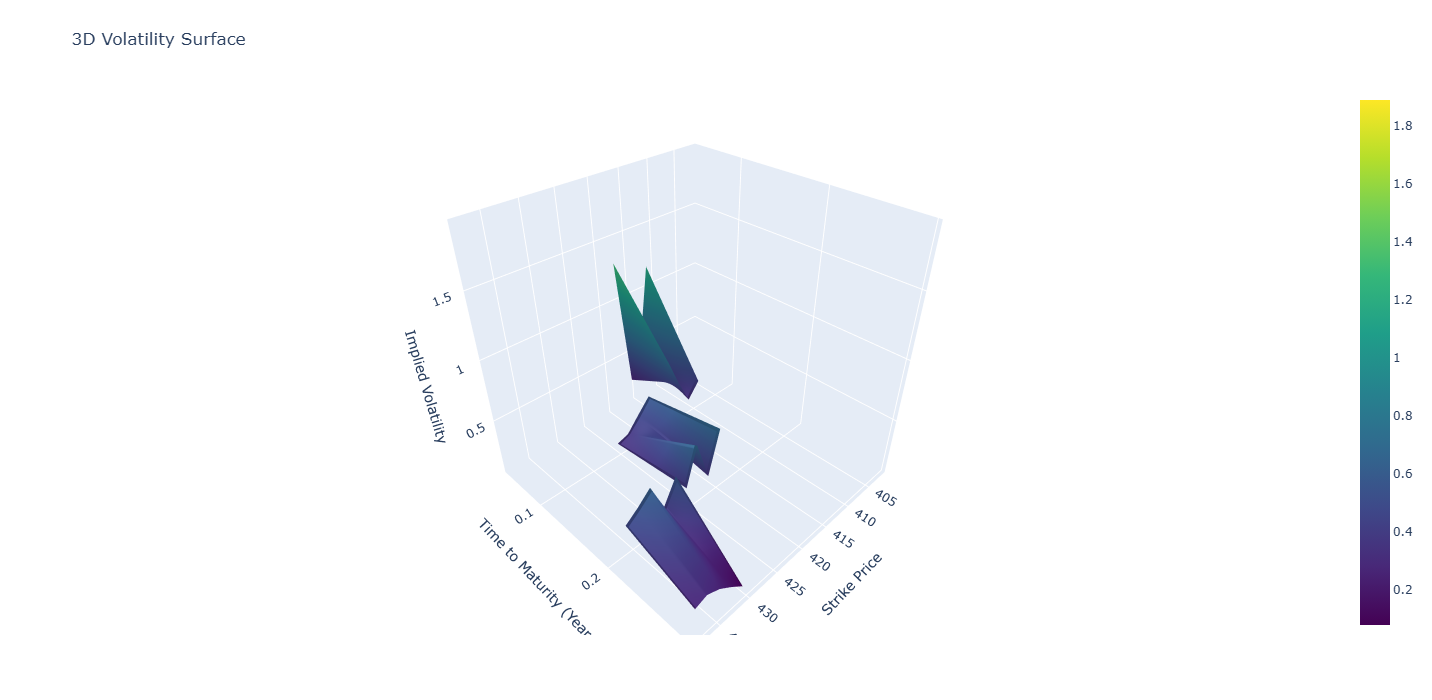

Interactive 3D Volatility Surface plot displayed.


In [52]:
import plotly.graph_objects as go

# 1. Create an interactive 3D volatility surface plot
fig = go.Figure(data=[go.Surface(
    z=interpolated_vols_for_plot,
    x=interpolated_strike_grid_for_plot,
    y=interpolated_ttm_grid_for_plot,
    colorscale='Viridis' # Choose a colorscale
)])

fig.update_layout(
    title='3D Volatility Surface',
    scene=dict(
        xaxis_title='Strike Price',
        yaxis_title='Time to Maturity (Years)',
        zaxis_title='Implied Volatility'
    ),
    autosize=False,
    width=800,
    height=700,
    margin=dict(l=65, r=50, b=65, t=90)
)

fig.show()
print("Interactive 3D Volatility Surface plot displayed.")

**Reasoning**:
I need to plot 2D volatility smile curves for different maturities. I will group the `df_options` by `time_to_maturity`, iterate through each group, and generate an interactive 2D scatter plot for implied volatility against strike price for each unique maturity.



Generating 2D Volatility Smile curves for different maturities...


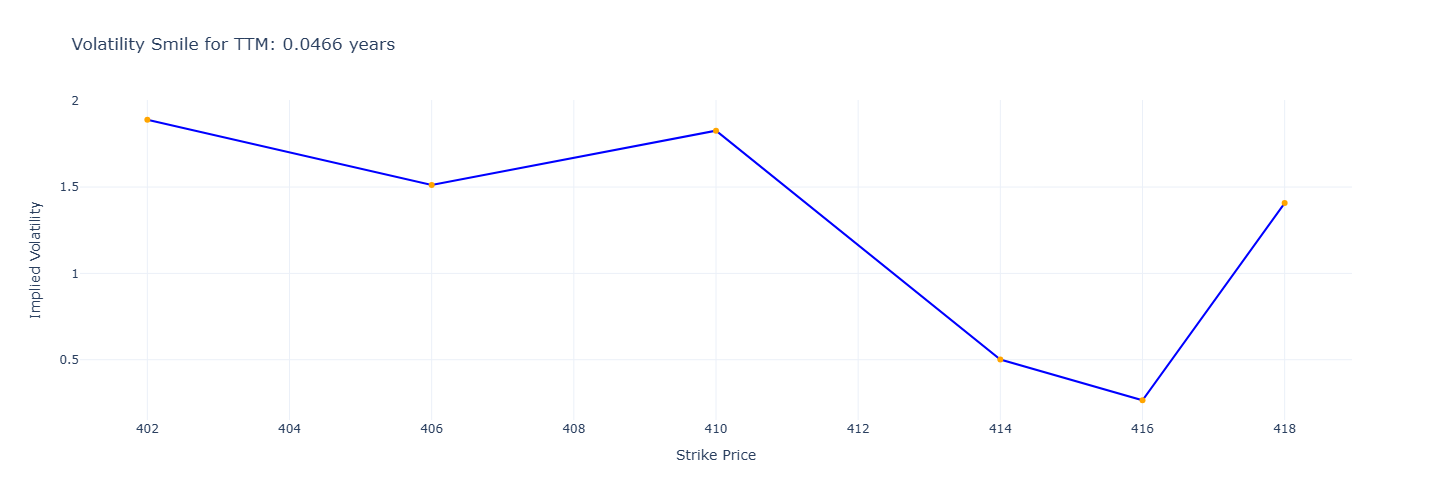

Displayed volatility smile plot for TTM: 0.0466 years.


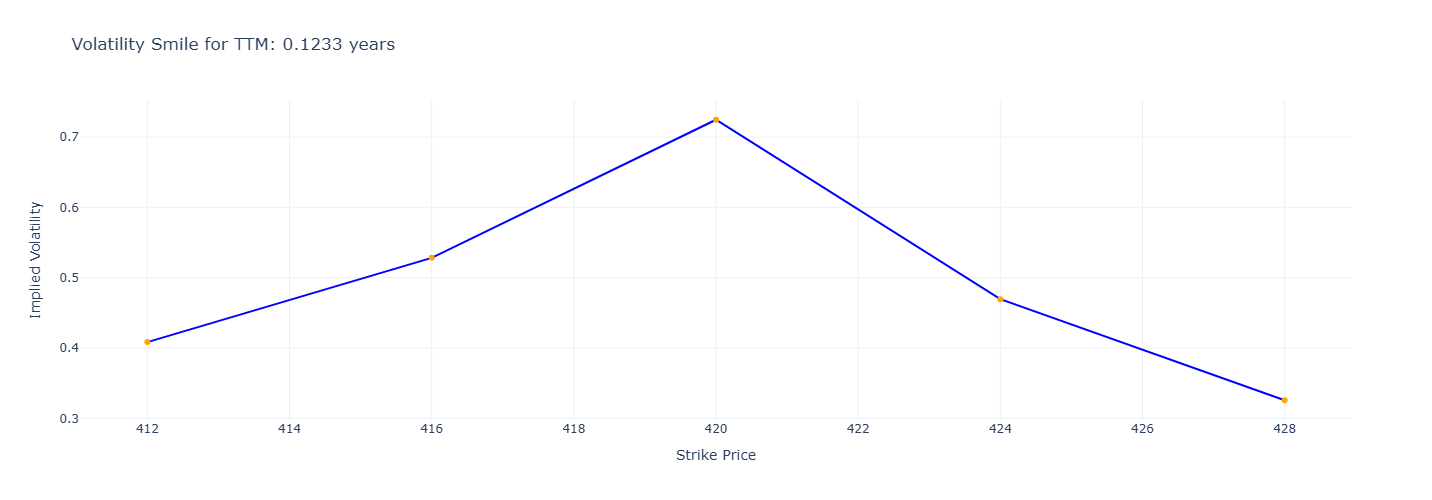

Displayed volatility smile plot for TTM: 0.1233 years.


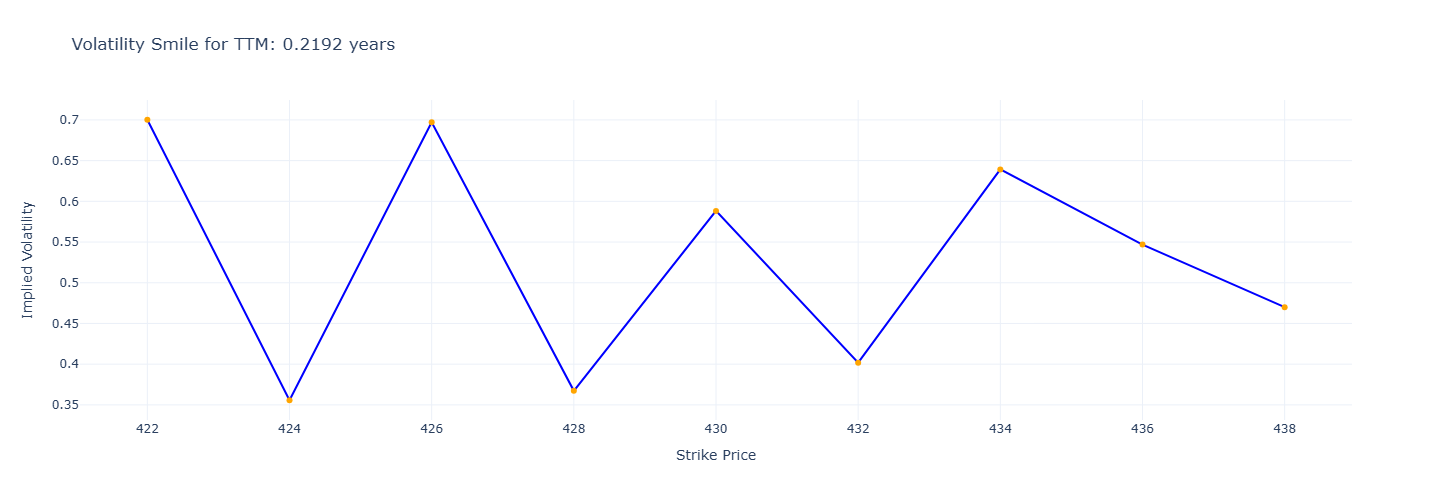

Displayed volatility smile plot for TTM: 0.2192 years.


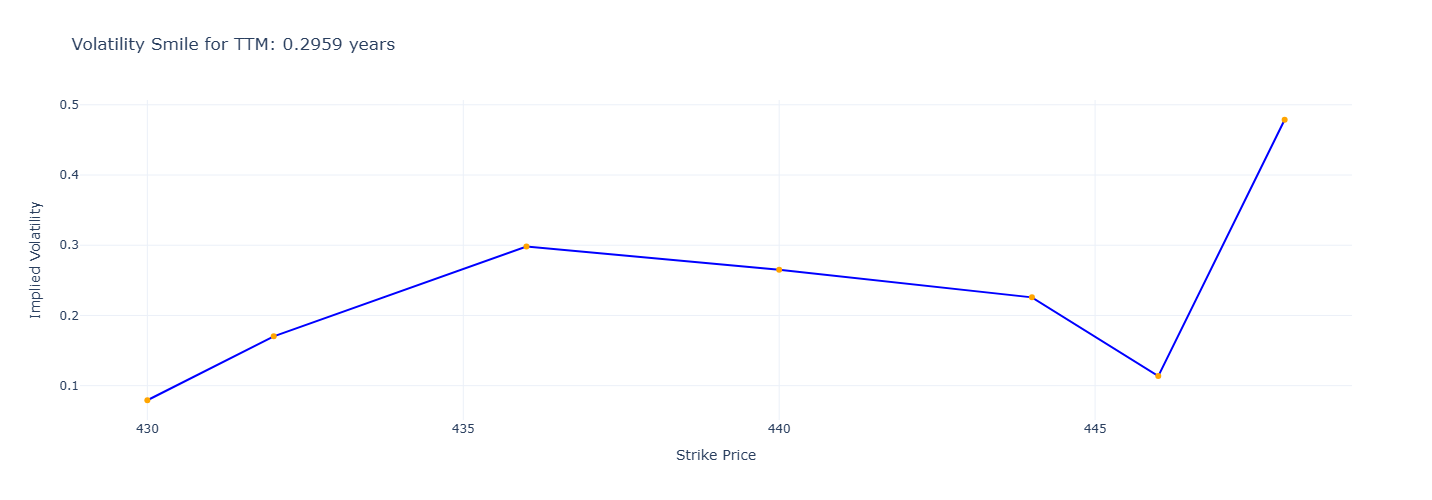

Displayed volatility smile plot for TTM: 0.2959 years.
Finished generating all 2D Volatility Smile curves.


In [53]:
import plotly.graph_objects as go

print("Generating 2D Volatility Smile curves for different maturities...")

# Group data by time_to_maturity to get individual smiles
for ttm, group in df_options.groupby('time_to_maturity'):
    # Sort the group by strike price for proper plotting
    group_sorted = group.sort_values(by='strike_price')

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=group_sorted['strike_price'],
        y=group_sorted['implied_volatility'],
        mode='lines+markers',
        name=f'Volatility Smile (TTM: {ttm:.4f} years)',
        marker=dict(color='orange', size=6),
        line=dict(color='blue', width=2)
    ))

    fig.update_layout(
        title=f'Volatility Smile for TTM: {ttm:.4f} years',
        xaxis_title='Strike Price',
        yaxis_title='Implied Volatility',
        hovermode='x unified',
        template='plotly_white',
        autosize=False,
        width=800,
        height=500
    )
    fig.show()
    print(f"Displayed volatility smile plot for TTM: {ttm:.4f} years.")

print("Finished generating all 2D Volatility Smile curves.")


**Reasoning**:
I need to visualize the behavior of option Greeks. I'll start with Delta, creating a heatmap that shows Delta values across different strike prices and times to maturity. This involves preparing the data by pivoting `df_options` to get Delta values in a grid format.



Generating Heatmap for Option Delta...


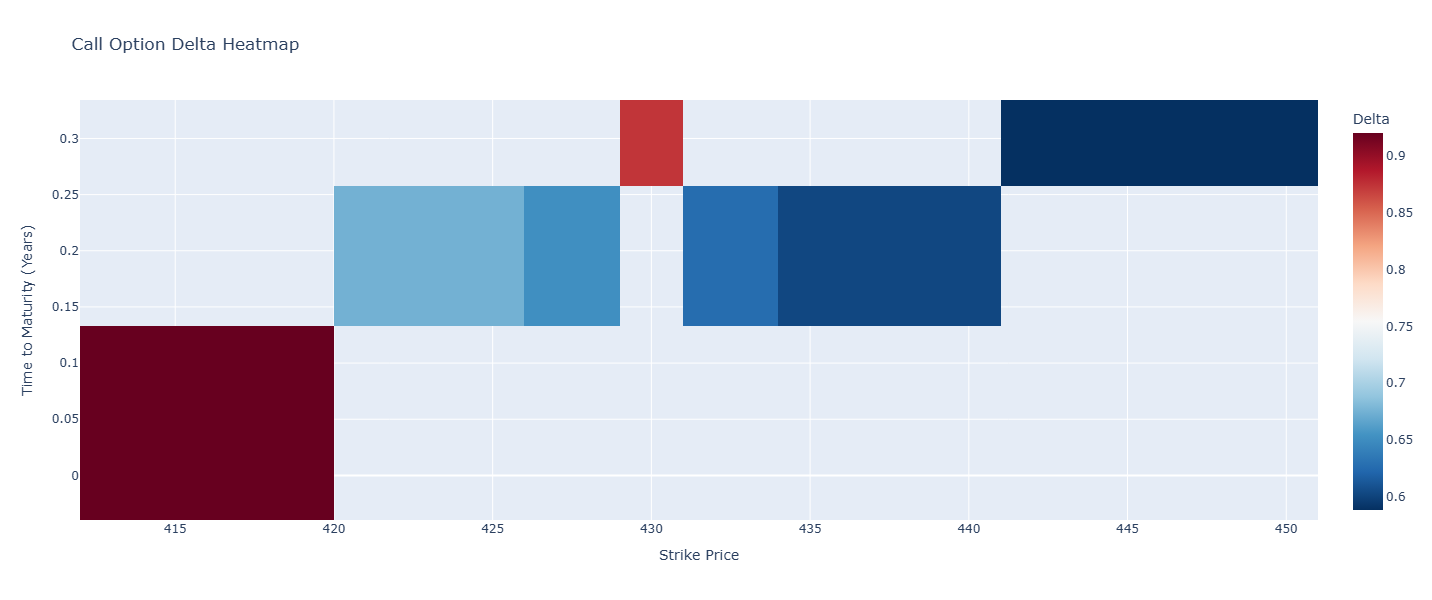

Call Option Delta Heatmap displayed.


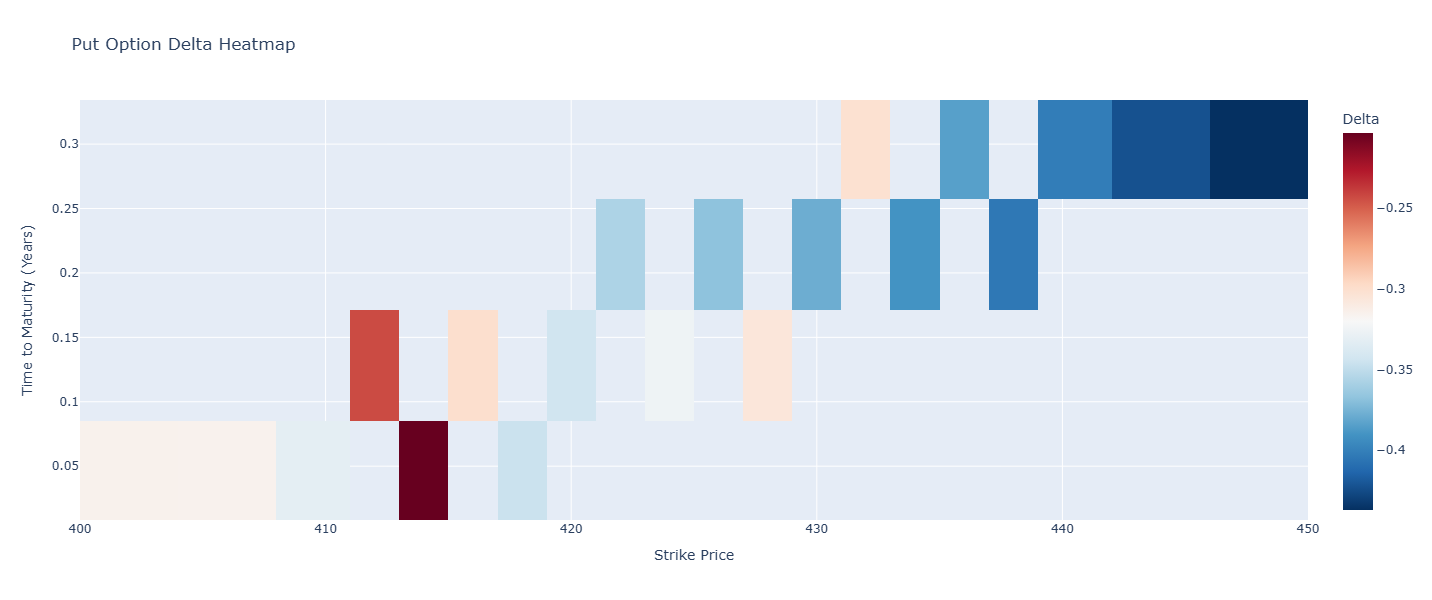

Put Option Delta Heatmap displayed.


In [54]:
import plotly.graph_objects as go

print("Generating Heatmap for Option Delta...")

# Prepare data for Delta heatmap
# It's important to average or select a representative value if multiple options exist for same TTM/Strike (e.g., calls/puts).
# For a heatmap, we generally want one value per (TTM, Strike) cell.
# Let's consider calls and puts separately for Greeks visualization, or average them if appropriate.
# For simplicity, let's create separate heatmaps for Call Delta and Put Delta.

# Filter for call options and pivot for Delta heatmap
df_calls = df_options[df_options['option_type'] == 'call']
delta_calls_pivot = df_calls.pivot_table(index='time_to_maturity', columns='strike_price', values='delta')

# Create Call Delta Heatmap
fig_delta_call = go.Figure(data=go.Heatmap(
                   z=delta_calls_pivot.values,
                   x=delta_calls_pivot.columns,
                   y=delta_calls_pivot.index,
                   colorscale='RdBu_r',
                   colorbar=dict(title='Delta')
                  ))

fig_delta_call.update_layout(
    title='Call Option Delta Heatmap',
    xaxis_title='Strike Price',
    yaxis_title='Time to Maturity (Years)',
    autosize=False,
    width=800,
    height=600,
    hovermode='closest'
)
fig_delta_call.show()
print("Call Option Delta Heatmap displayed.")


# Filter for put options and pivot for Delta heatmap
df_puts = df_options[df_options['option_type'] == 'put']
delta_puts_pivot = df_puts.pivot_table(index='time_to_maturity', columns='strike_price', values='delta')

# Create Put Delta Heatmap
fig_delta_put = go.Figure(data=go.Heatmap(
                   z=delta_puts_pivot.values,
                   x=delta_puts_pivot.columns,
                   y=delta_puts_pivot.index,
                   colorscale='RdBu_r',
                   colorbar=dict(title='Delta')
                  ))

fig_delta_put.update_layout(
    title='Put Option Delta Heatmap',
    xaxis_title='Strike Price',
    yaxis_title='Time to Maturity (Years)',
    autosize=False,
    width=800,
    height=600,
    hovermode='closest'
)
fig_delta_put.show()
print("Put Option Delta Heatmap displayed.")


**Reasoning**:
I will create heatmaps for Call Gamma and Put Gamma, following the same methodology as the Delta heatmaps. This involves filtering `df_options` for calls and puts, pivoting the data to get Gamma values indexed by time to maturity and columns by strike price, and then generating interactive heatmaps using Plotly.



Generating Heatmap for Option Gamma...


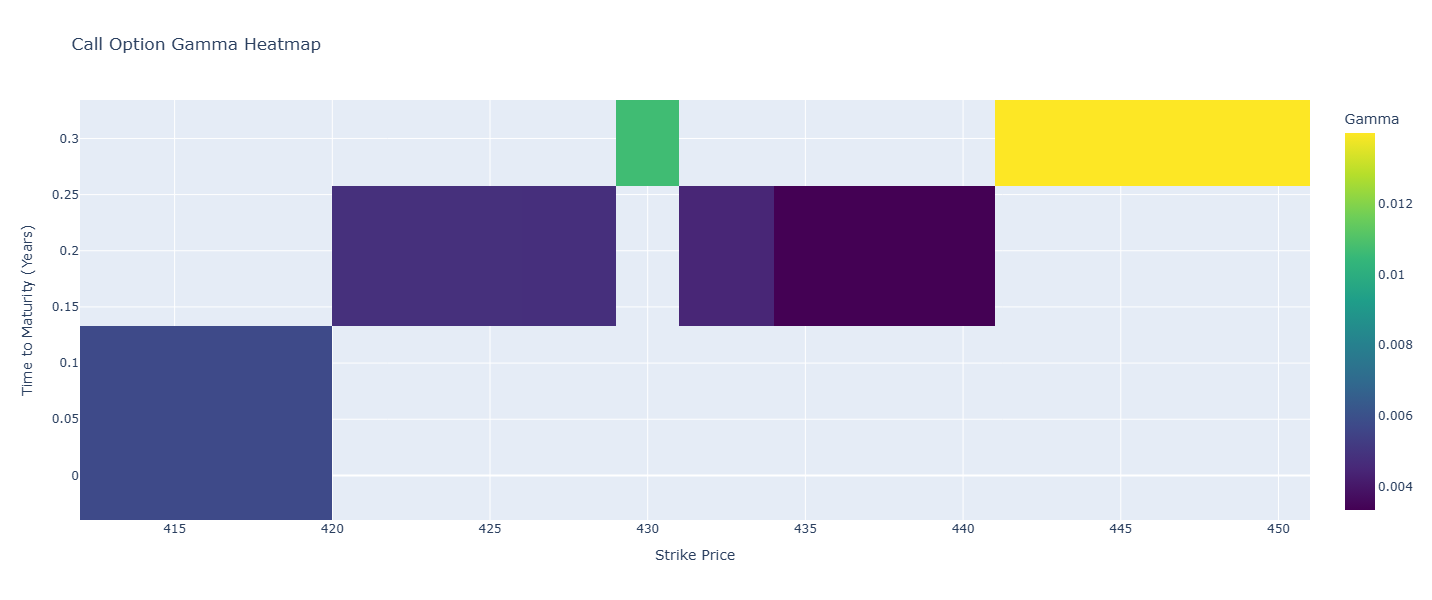

Call Option Gamma Heatmap displayed.


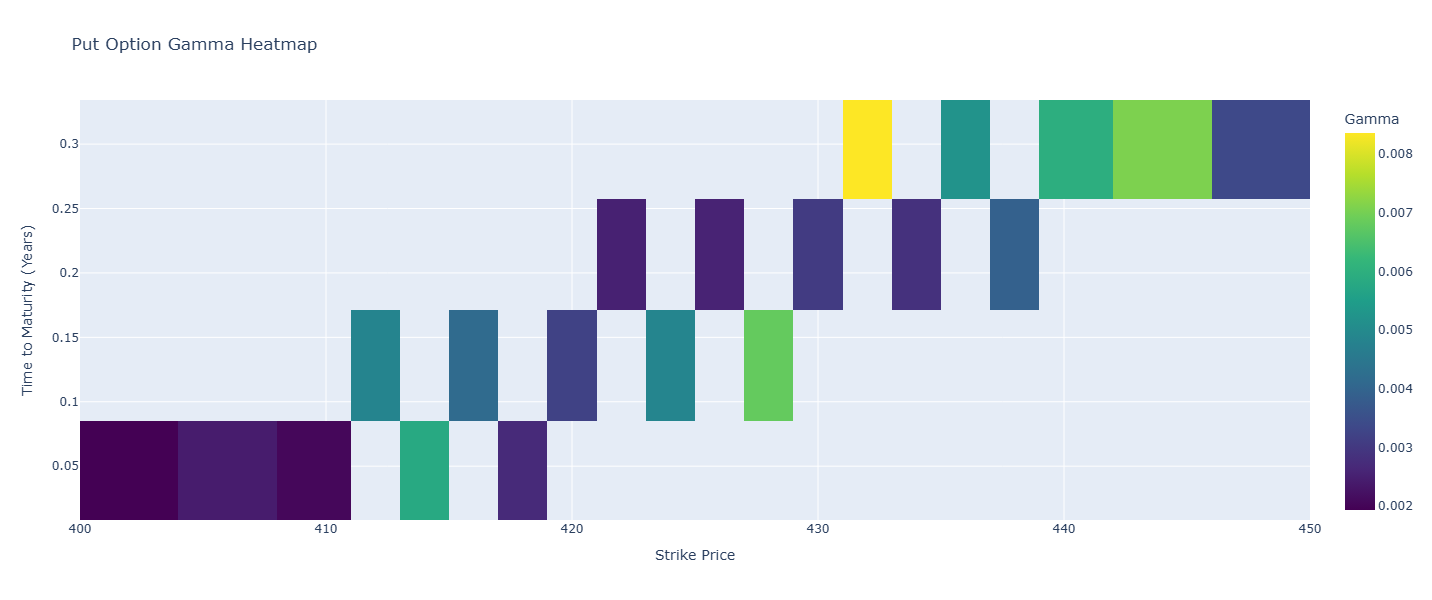

Put Option Gamma Heatmap displayed.


In [55]:
import plotly.graph_objects as go

print("Generating Heatmap for Option Gamma...")

# Filter for call options and pivot for Gamma heatmap
df_calls = df_options[df_options['option_type'] == 'call']
gamma_calls_pivot = df_calls.pivot_table(index='time_to_maturity', columns='strike_price', values='gamma')

# Create Call Gamma Heatmap
fig_gamma_call = go.Figure(data=go.Heatmap(
                   z=gamma_calls_pivot.values,
                   x=gamma_calls_pivot.columns,
                   y=gamma_calls_pivot.index,
                   colorscale='Viridis',
                   colorbar=dict(title='Gamma')
                  ))

fig_gamma_call.update_layout(
    title='Call Option Gamma Heatmap',
    xaxis_title='Strike Price',
    yaxis_title='Time to Maturity (Years)',
    autosize=False,
    width=800,
    height=600,
    hovermode='closest'
)
fig_gamma_call.show()
print("Call Option Gamma Heatmap displayed.")


# Filter for put options and pivot for Gamma heatmap
df_puts = df_options[df_options['option_type'] == 'put']
gamma_puts_pivot = df_puts.pivot_table(index='time_to_maturity', columns='strike_price', values='gamma')

# Create Put Gamma Heatmap
fig_gamma_put = go.Figure(data=go.Heatmap(
                   z=gamma_puts_pivot.values,
                   x=gamma_puts_pivot.columns,
                   y=gamma_puts_pivot.index,
                   colorscale='Viridis',
                   colorbar=dict(title='Gamma')
                  ))

fig_gamma_put.update_layout(
    title='Put Option Gamma Heatmap',
    xaxis_title='Strike Price',
    yaxis_title='Time to Maturity (Years)',
    autosize=False,
    width=800,
    height=600,
    hovermode='closest'
)
fig_gamma_put.show()
print("Put Option Gamma Heatmap displayed.")

**Reasoning**:
I will generate heatmaps for Call Theta and Put Theta, following the same methodology as the Delta and Gamma heatmaps. This involves filtering `df_options` for calls and puts, pivoting the data to get Theta values indexed by time to maturity and columns by strike price, and then generating interactive heatmaps using Plotly.



Generating Heatmap for Option Theta...


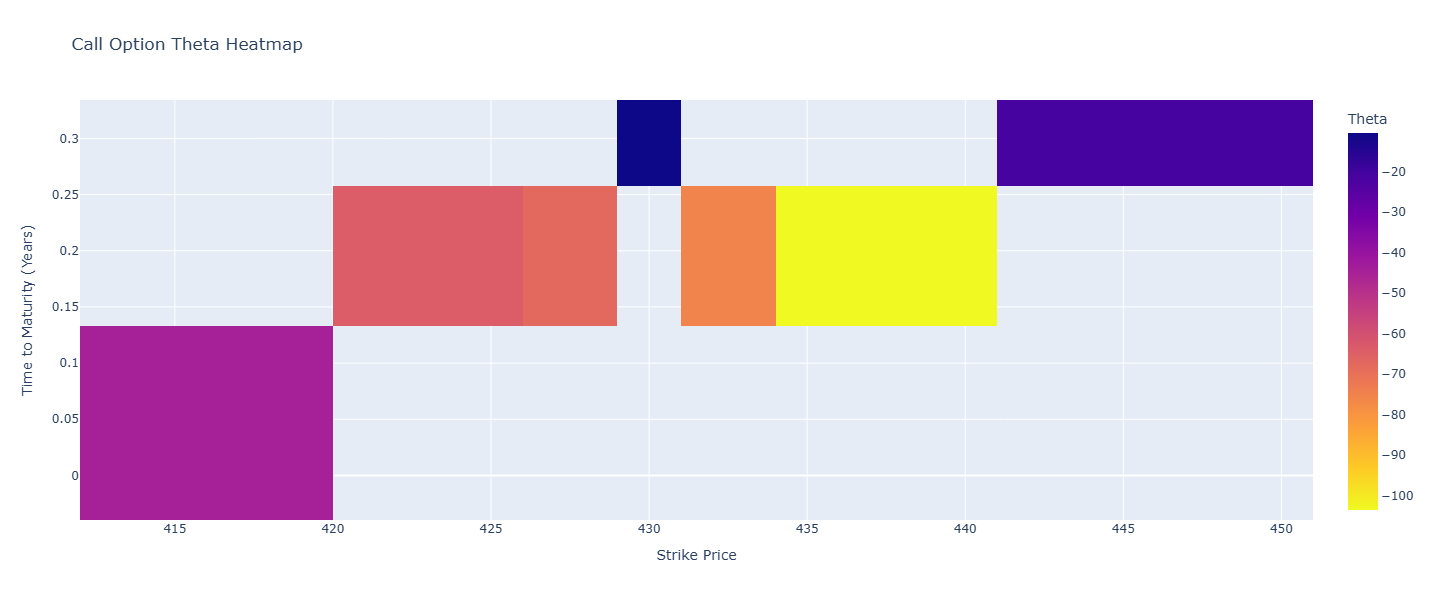

Call Option Theta Heatmap displayed.


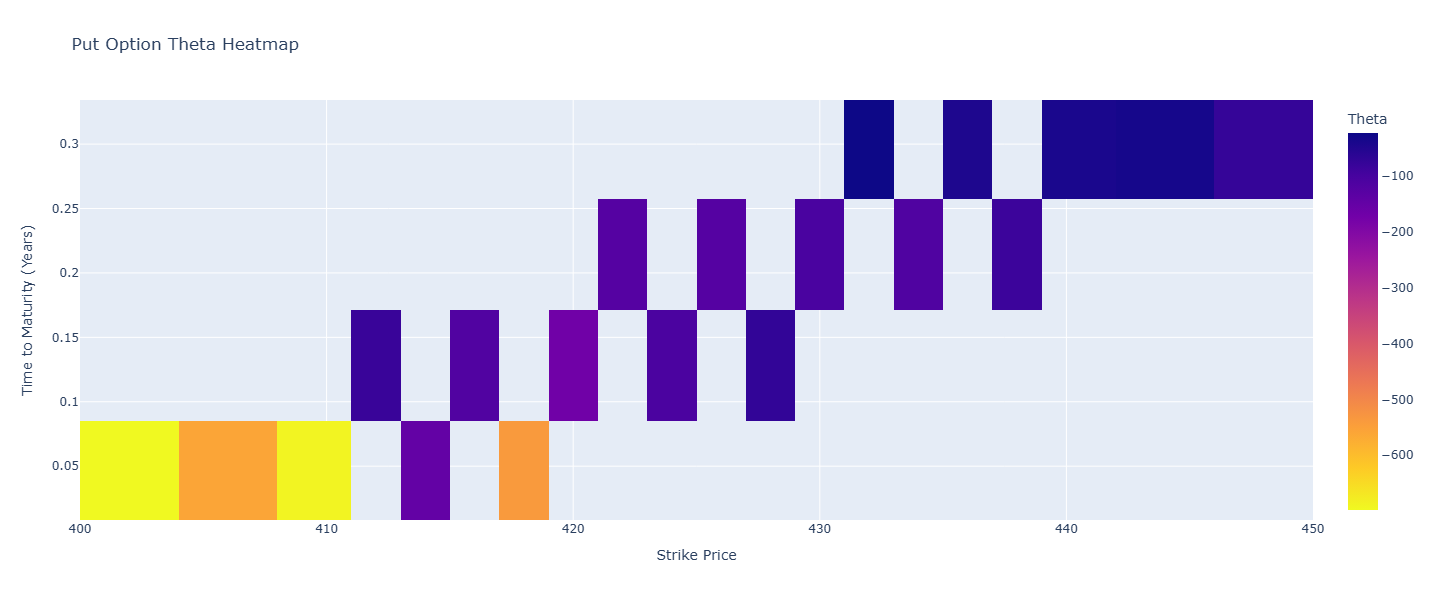

Put Option Theta Heatmap displayed.


In [56]:
import plotly.graph_objects as go

print("Generating Heatmap for Option Theta...")

# Filter for call options and pivot for Theta heatmap
df_calls = df_options[df_options['option_type'] == 'call']
theta_calls_pivot = df_calls.pivot_table(index='time_to_maturity', columns='strike_price', values='theta')

# Create Call Theta Heatmap
fig_theta_call = go.Figure(data=go.Heatmap(
                   z=theta_calls_pivot.values,
                   x=theta_calls_pivot.columns,
                   y=theta_calls_pivot.index,
                   colorscale='Plasma_r', # A good colorscale for values that can be negative
                   colorbar=dict(title='Theta')
                  ))

fig_theta_call.update_layout(
    title='Call Option Theta Heatmap',
    xaxis_title='Strike Price',
    yaxis_title='Time to Maturity (Years)',
    autosize=False,
    width=800,
    height=600,
    hovermode='closest'
)
fig_theta_call.show()
print("Call Option Theta Heatmap displayed.")


# Filter for put options and pivot for Theta heatmap
df_puts = df_options[df_options['option_type'] == 'put']
theta_puts_pivot = df_puts.pivot_table(index='time_to_maturity', columns='strike_price', values='theta')

# Create Put Theta Heatmap
fig_theta_put = go.Figure(data=go.Heatmap(
                   z=theta_puts_pivot.values,
                   x=theta_puts_pivot.columns,
                   y=theta_puts_pivot.index,
                   colorscale='Plasma_r', # A good colorscale for values that can be negative
                   colorbar=dict(title='Theta')
                  ))

fig_theta_put.update_layout(
    title='Put Option Theta Heatmap',
    xaxis_title='Strike Price',
    yaxis_title='Time to Maturity (Years)',
    autosize=False,
    width=800,
    height=600,
    hovermode='closest'
)
fig_theta_put.show()
print("Put Option Theta Heatmap displayed.")

**Reasoning**:
I will generate heatmaps for Call Rho and Put Rho, following the same methodology as the Delta, Gamma, and Theta heatmaps. This involves filtering `df_options` for calls and puts, pivoting the data to get Rho values indexed by time to maturity and columns by strike price, and then generating interactive heatmaps using Plotly.



Generating Heatmap for Option Rho...


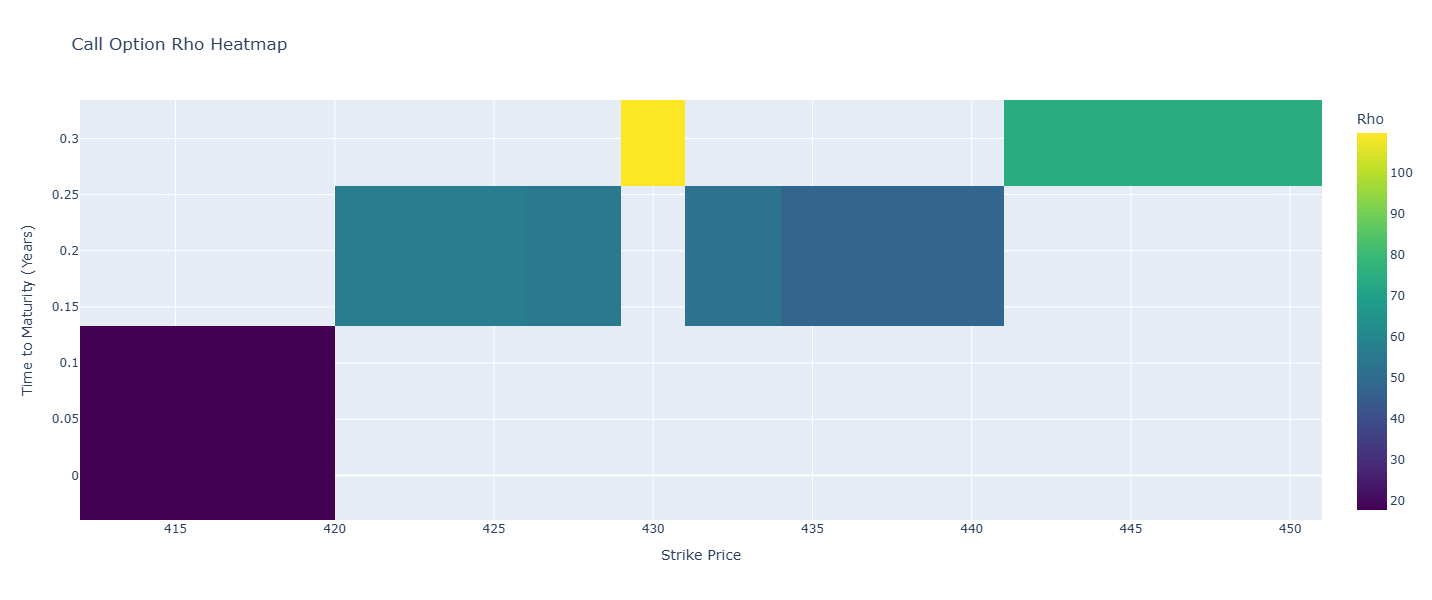

Call Option Rho Heatmap displayed.


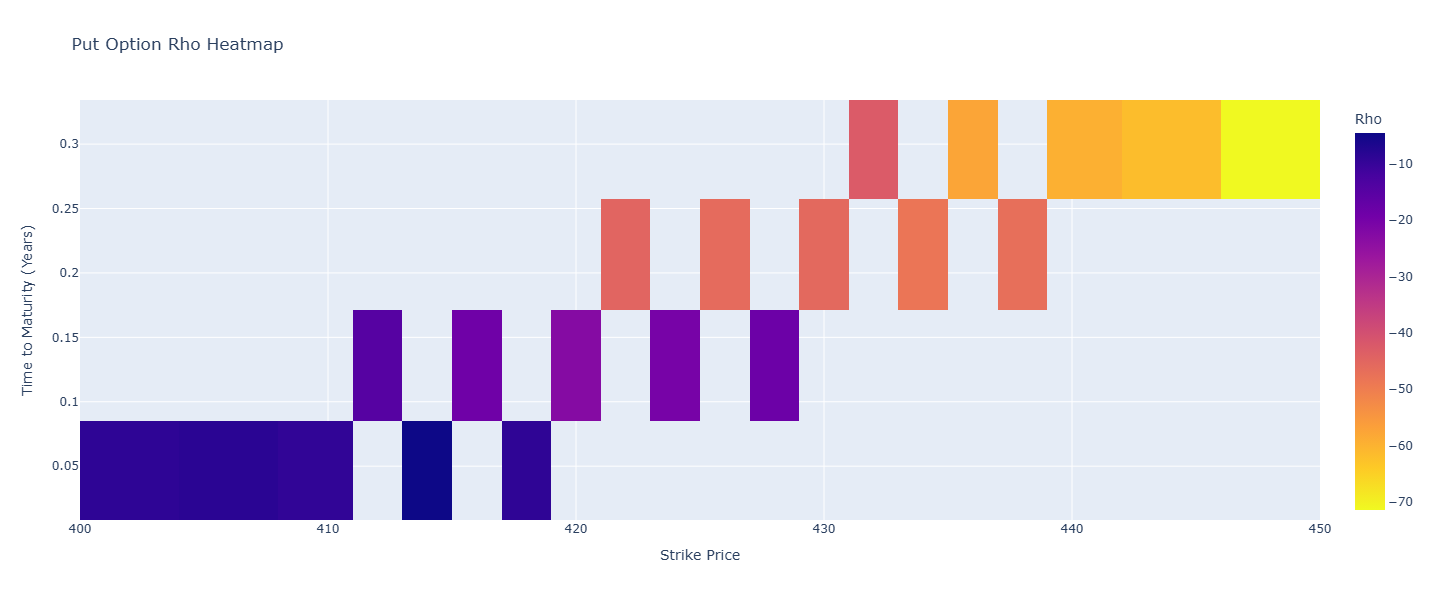

Put Option Rho Heatmap displayed.


In [57]:
import plotly.graph_objects as go

print("Generating Heatmap for Option Rho...")

# Filter for call options and pivot for Rho heatmap
df_calls = df_options[df_options['option_type'] == 'call']
rho_calls_pivot = df_calls.pivot_table(index='time_to_maturity', columns='strike_price', values='rho')

# Create Call Rho Heatmap
fig_rho_call = go.Figure(data=go.Heatmap(
                   z=rho_calls_pivot.values,
                   x=rho_calls_pivot.columns,
                   y=rho_calls_pivot.index,
                   colorscale='Viridis', # Rho is typically positive for calls
                   colorbar=dict(title='Rho')
                  ))

fig_rho_call.update_layout(
    title='Call Option Rho Heatmap',
    xaxis_title='Strike Price',
    yaxis_title='Time to Maturity (Years)',
    autosize=False,
    width=800,
    height=600,
    hovermode='closest'
)
fig_rho_call.show()
print("Call Option Rho Heatmap displayed.")


# Filter for put options and pivot for Rho heatmap
df_puts = df_options[df_options['option_type'] == 'put']
rho_puts_pivot = df_puts.pivot_table(index='time_to_maturity', columns='strike_price', values='rho')

# Create Put Rho Heatmap
fig_rho_put = go.Figure(data=go.Heatmap(
                   z=rho_puts_pivot.values,
                   x=rho_puts_pivot.columns,
                   y=rho_puts_pivot.index,
                   colorscale='Plasma_r', # Rho is typically negative for puts, so a diverging colorscale might be better or reverse
                   colorbar=dict(title='Rho')
                  ))

fig_rho_put.update_layout(
    title='Put Option Rho Heatmap',
    xaxis_title='Strike Price',
    yaxis_title='Time to Maturity (Years)',
    autosize=False,
    width=800,
    height=600,
    hovermode='closest'
)
fig_rho_put.show()
print("Put Option Rho Heatmap displayed.")

In [64]:
help(black_scholes_vega)

Help on function black_scholes_vega in module __main__:

black_scholes_vega(S, K, T, r, sigma)



**Reasoning**:
I need to generate heatmaps for option Vega (for both calls and puts). I will filter `df_options` for call and put options, create pivot tables for Vega, and then generate interactive heatmaps using Plotly, similar to how Delta, Gamma, Theta, and Rho were visualized.



In [65]:
df_options["vega"] = df_options.apply(
    lambda row: black_scholes_vega(
        S,                  
        row["strike_price"],
        row["time_to_maturity"],
        r,                
        row["implied_volatility"]
    ),
    axis=1)

Generating Heatmap for Option Vega...


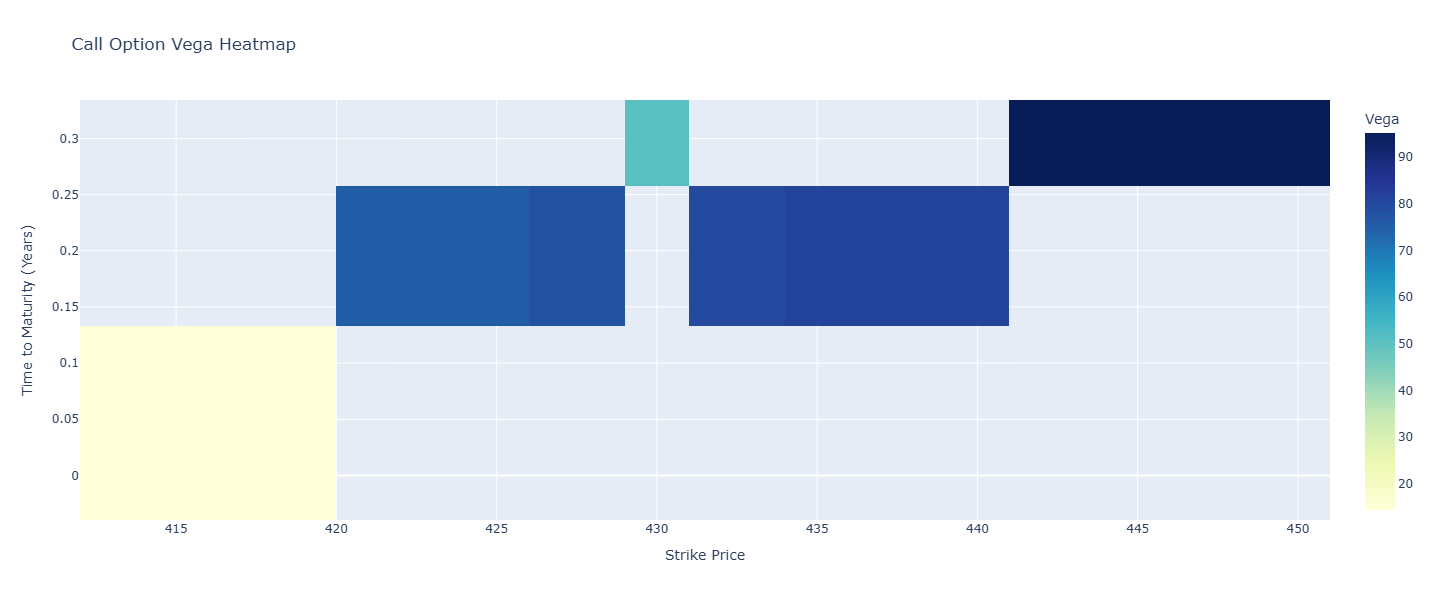

Call Option Vega Heatmap displayed.


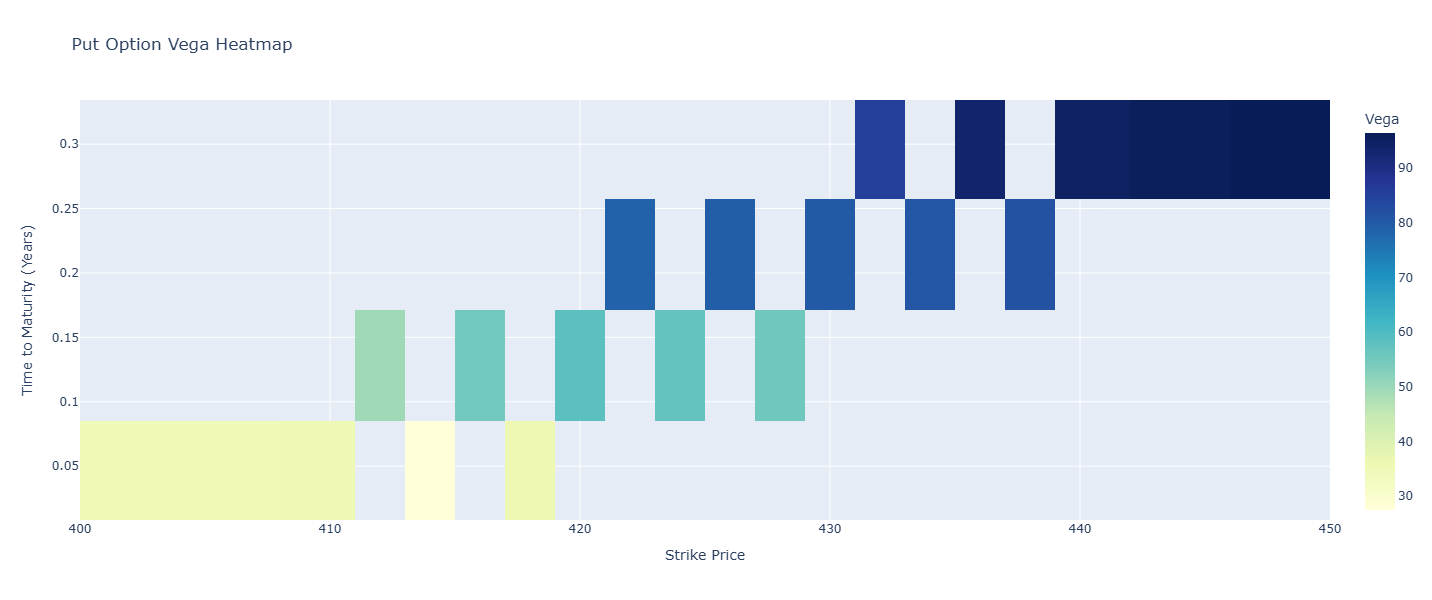

Put Option Vega Heatmap displayed.


In [66]:

import plotly.graph_objects as go

print("Generating Heatmap for Option Vega...")

# Implement the Black-Scholes Vega (same as before, but ensuring it's available for the application)
def black_scholes_vega(option_type, S, K, T, r, q, sigma):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    vega = S * np.exp(-q * T) * norm.pdf(d1) * np.sqrt(T)
    return vega

# Ensure Vega is calculated in df_options if not already done (it should be from previous steps, but good to check or re-calculate if needed)
# For the purpose of this step, we assume 'vega' column exists in df_options.
# If not, it would be calculated here:
# df_options['vega'] = df_options.apply(
#     lambda row: black_scholes_vega(row['option_type'], S, row['strike_price'], row['time_to_maturity'], r, q, row['implied_volatility']),
#     axis=1
# )


# Filter for call options and pivot for Vega heatmap
df_calls = df_options[df_options['option_type'] == 'call']
vega_calls_pivot = df_calls.pivot_table(index='time_to_maturity', columns='strike_price', values='vega')

# Create Call Vega Heatmap
fig_vega_call = go.Figure(data=go.Heatmap(
                   z=vega_calls_pivot.values,
                   x=vega_calls_pivot.columns,
                   y=vega_calls_pivot.index,
                   colorscale='YlGnBu', # A common colorscale for positive values
                   colorbar=dict(title='Vega')
                  ))

fig_vega_call.update_layout(
    title='Call Option Vega Heatmap',
    xaxis_title='Strike Price',
    yaxis_title='Time to Maturity (Years)',
    autosize=False,
    width=800,
    height=600,
    hovermode='closest'
)
fig_vega_call.show()
print("Call Option Vega Heatmap displayed.")


# Filter for put options and pivot for Vega heatmap
df_puts = df_options[df_options['option_type'] == 'put']
vega_puts_pivot = df_puts.pivot_table(index='time_to_maturity', columns='strike_price', values='vega')

# Create Put Vega Heatmap
fig_vega_put = go.Figure(data=go.Heatmap(
                   z=vega_puts_pivot.values,
                   x=vega_puts_pivot.columns,
                   y=vega_puts_pivot.index,
                   colorscale='YlGnBu', # Vega is typically positive for both calls and puts
                   colorbar=dict(title='Vega')
                  ))

fig_vega_put.update_layout(
    title='Put Option Vega Heatmap',
    xaxis_title='Strike Price',
    yaxis_title='Time to Maturity (Years)',
    autosize=False,
    width=800,
    height=600,
    hovermode='closest'
)
fig_vega_put.show()
print("Put Option Vega Heatmap displayed.")

**Reasoning**:
I need to calculate the 'vega' column and add it to the `df_options` DataFrame before generating the Vega heatmaps. This step will use the `black_scholes_vega` function with the existing implied volatility.



Generating Heatmap for Option Vega...
Vega column added to df_options.


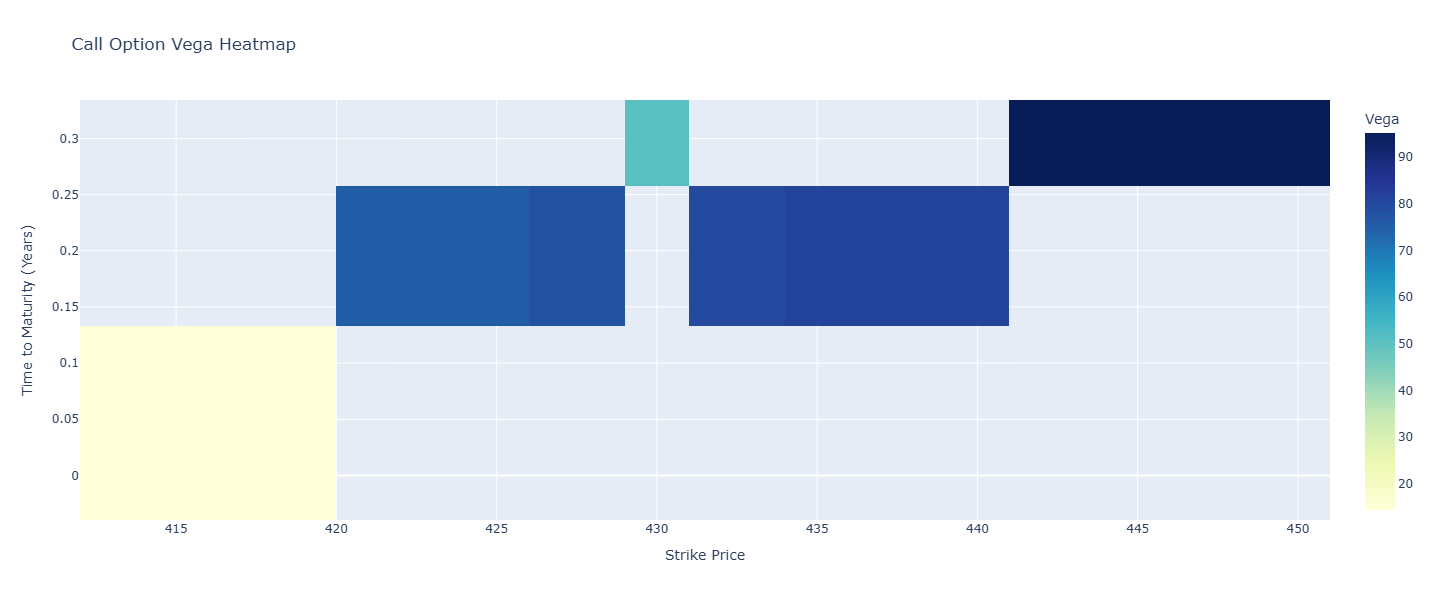

Call Option Vega Heatmap displayed.


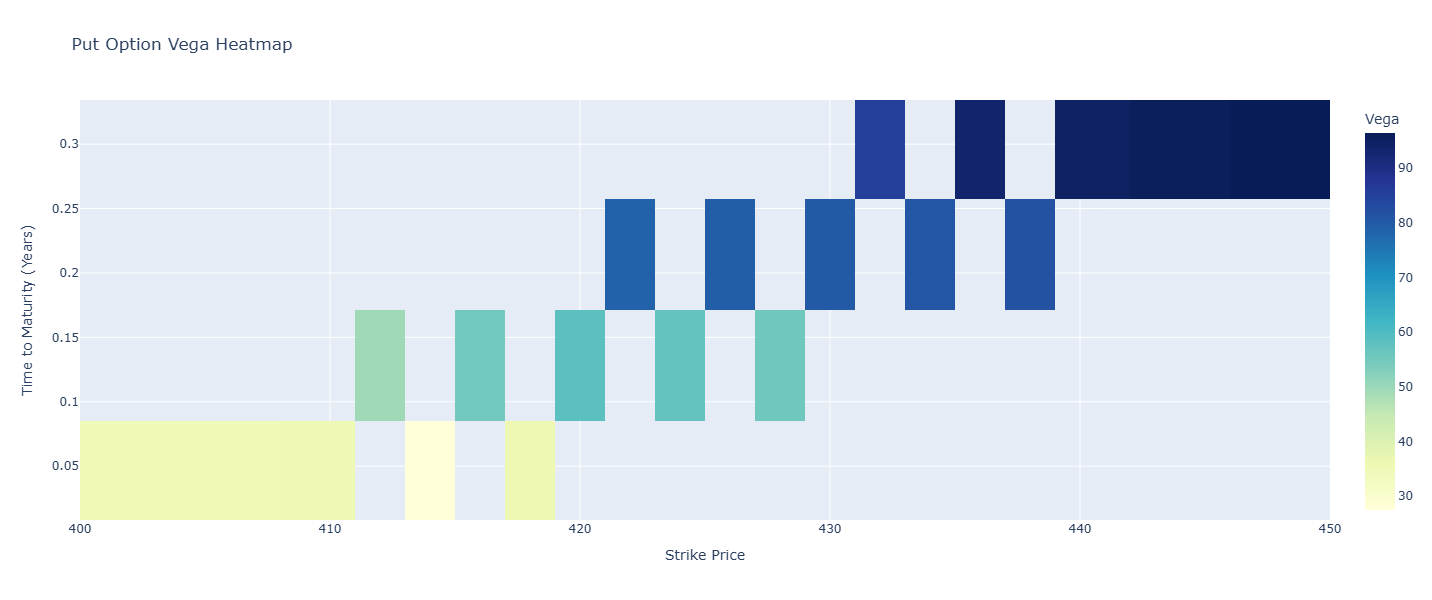

Put Option Vega Heatmap displayed.


In [68]:
import plotly.graph_objects as go

print("Generating Heatmap for Option Vega...")

# Ensure the Black-Scholes Vega function is available
def black_scholes_vega(option_type, S, K, T, r, q, sigma):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    vega = S * np.exp(-q * T) * norm.pdf(d1) * np.sqrt(T)
    return vega

# Calculate Vega and add it as a new column to df_options
df_options['vega'] = df_options.apply(
    lambda row: black_scholes_vega(
        row['option_type'], S, row['strike_price'], row['time_to_maturity'], r, q, row['implied_volatility']
    ),
    axis=1
)
print("Vega column added to df_options.")

# Filter for call options and pivot for Vega heatmap
df_calls = df_options[df_options['option_type'] == 'call']
vega_calls_pivot = df_calls.pivot_table(index='time_to_maturity', columns='strike_price', values='vega')

# Create Call Vega Heatmap
fig_vega_call = go.Figure(data=go.Heatmap(
                   z=vega_calls_pivot.values,
                   x=vega_calls_pivot.columns,
                   y=vega_calls_pivot.index,
                   colorscale='YlGnBu', # A common colorscale for positive values
                   colorbar=dict(title='Vega')
                  ))

fig_vega_call.update_layout(
    title='Call Option Vega Heatmap',
    xaxis_title='Strike Price',
    yaxis_title='Time to Maturity (Years)',
    autosize=False,
    width=800,
    height=600,
    hovermode='closest'
)
fig_vega_call.show()
print("Call Option Vega Heatmap displayed.")


# Filter for put options and pivot for Vega heatmap
df_puts = df_options[df_options['option_type'] == 'put']
vega_puts_pivot = df_puts.pivot_table(index='time_to_maturity', columns='strike_price', values='vega')

# Create Put Vega Heatmap
fig_vega_put = go.Figure(data=go.Heatmap(
                   z=vega_puts_pivot.values,
                   x=vega_puts_pivot.columns,
                   y=vega_puts_pivot.index,
                   colorscale='YlGnBu', # Vega is typically positive for both calls and puts
                   colorbar=dict(title='Vega')
                  ))

fig_vega_put.update_layout(
    title='Put Option Vega Heatmap',
    xaxis_title='Strike Price',
    yaxis_title='Time to Maturity (Years)',
    autosize=False,
    width=800,
    height=600,
    hovermode='closest'
)
fig_vega_put.show()
print("Put Option Vega Heatmap displayed.")

**Reasoning**:
I need to integrate all the generated visualizations (3D volatility surface, 2D volatility smiles, and heatmaps for Greeks) into a single interactive dashboard. This will be done using Plotly's `make_subplots` and `go.Figure` capabilities, arranging them in a visually appealing and informative layout.



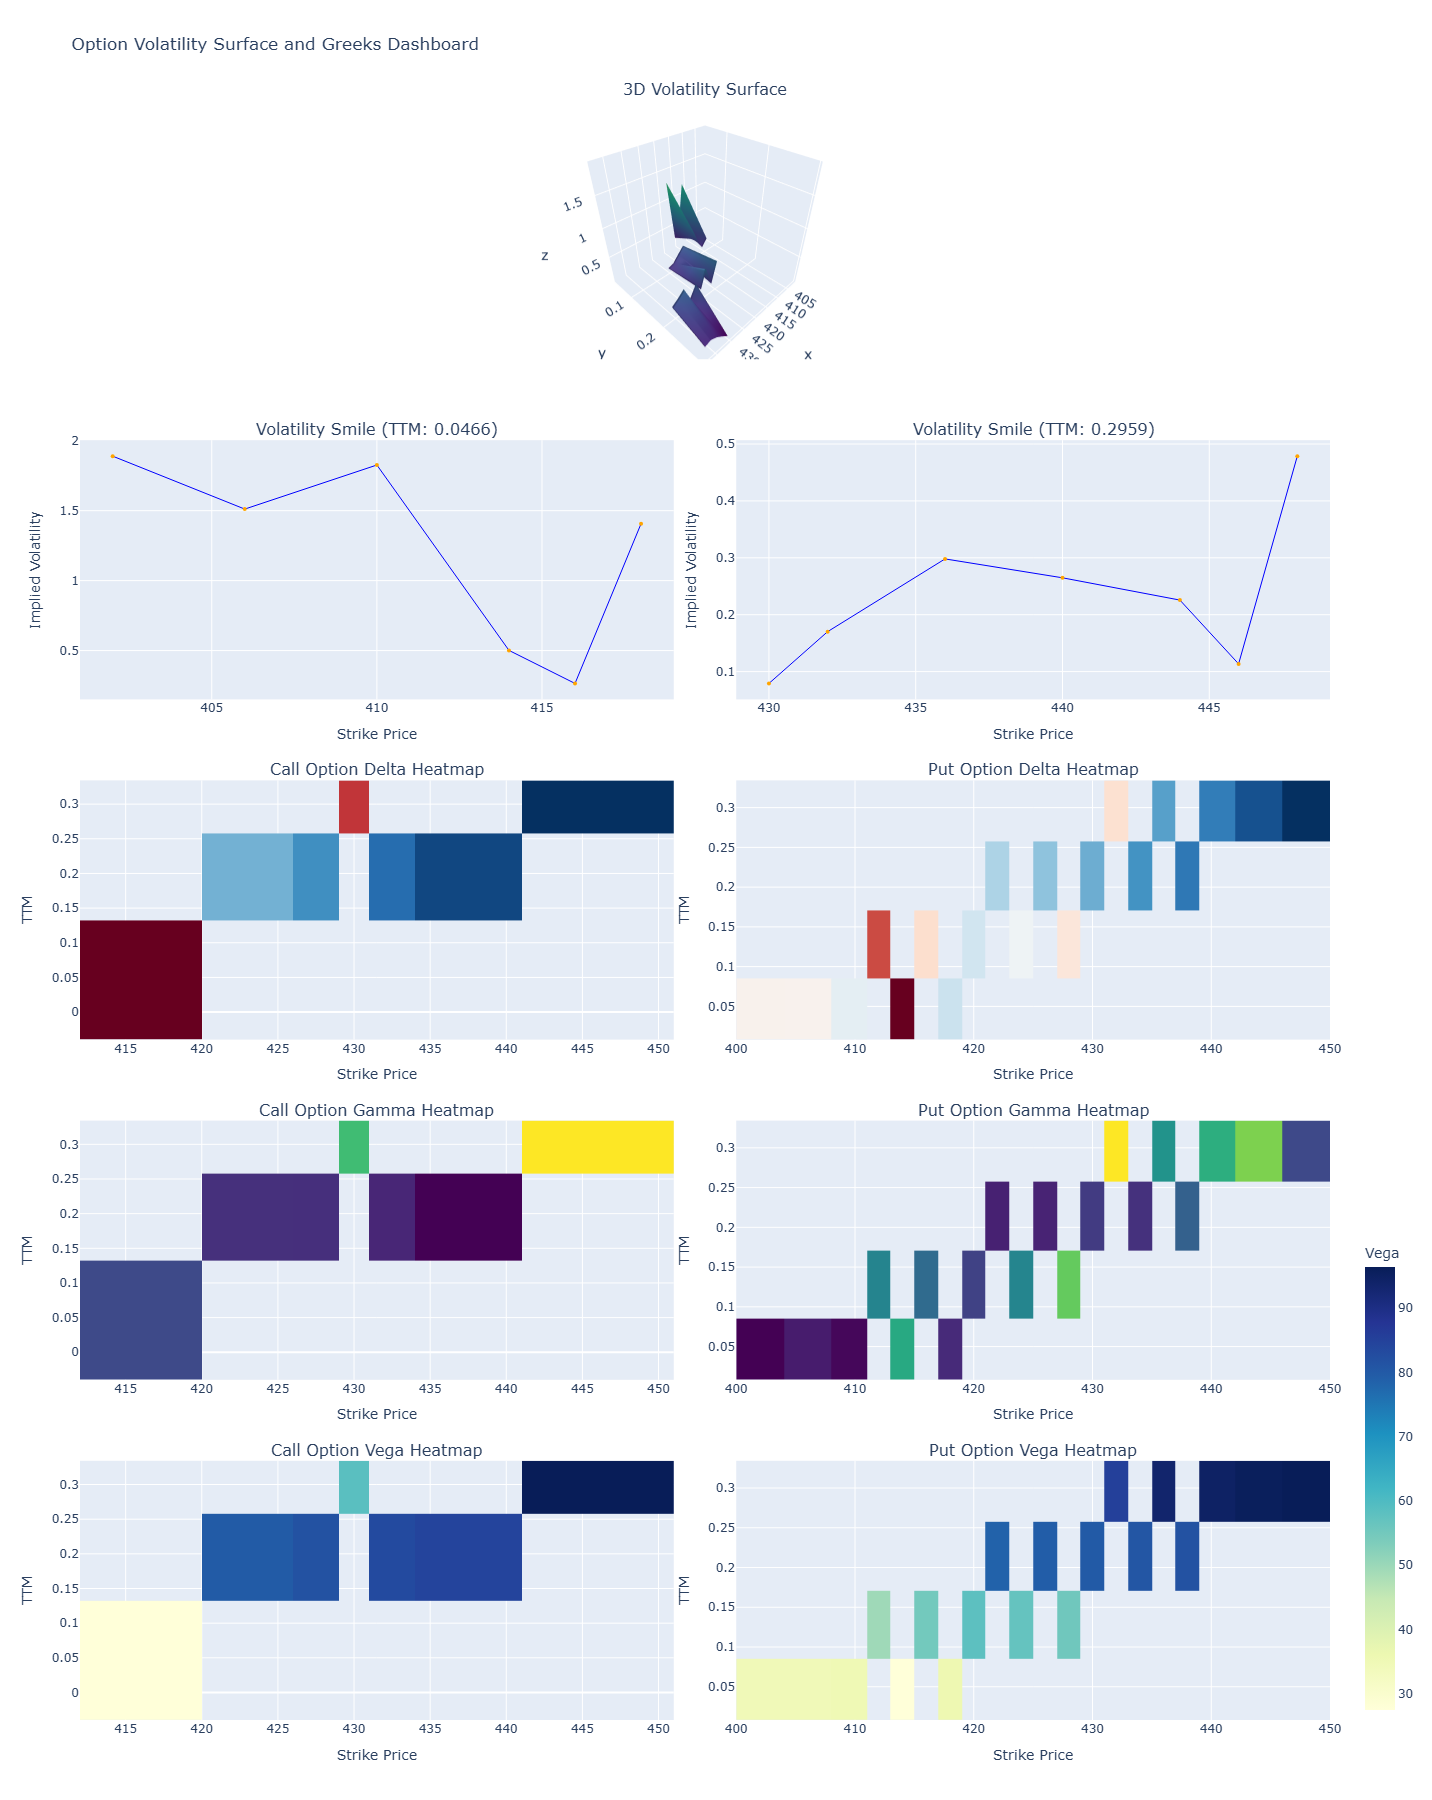

In [72]:
# Row 2
fig_dashboard.update_xaxes(title_text="Strike Price", row=2, col=1)
fig_dashboard.update_yaxes(title_text="Implied Volatility", row=2, col=1)

fig_dashboard.update_xaxes(title_text="Strike Price", row=2, col=2)
fig_dashboard.update_yaxes(title_text="Implied Volatility", row=2, col=2)

# Row 3
fig_dashboard.update_xaxes(title_text="Strike Price", row=3, col=1)
fig_dashboard.update_yaxes(title_text="TTM", row=3, col=1)

fig_dashboard.update_xaxes(title_text="Strike Price", row=3, col=2)
fig_dashboard.update_yaxes(title_text="TTM", row=3, col=2)

# Row 4
fig_dashboard.update_xaxes(title_text="Strike Price", row=4, col=1)
fig_dashboard.update_yaxes(title_text="TTM", row=4, col=1)

fig_dashboard.update_xaxes(title_text="Strike Price", row=4, col=2)
fig_dashboard.update_yaxes(title_text="TTM", row=4, col=2)

# Row 5
fig_dashboard.update_xaxes(title_text="Strike Price", row=5, col=1)
fig_dashboard.update_yaxes(title_text="TTM", row=5, col=1)

fig_dashboard.update_xaxes(title_text="Strike Price", row=5, col=2)
fig_dashboard.update_yaxes(title_text="TTM", row=5, col=2)

### Defined Performance Metrics

To evaluate the accuracy and robustness of the implied volatility calculations and the constructed volatility surface, we will focus on metrics that quantify the difference between our model's outputs and the observed market data. The primary goal is to assess how well the Black-Scholes model, using our derived implied volatilities, can reproduce the market prices, and how effectively the volatility surface represents the underlying implied volatility points.

Here are the chosen performance metrics and their relevance:

1.  **Pricing Error (or Residual)**:
    *   **Definition**: The difference between the theoretical option price calculated by the Black-Scholes model (using the derived implied volatility) and the actual market observed mid-price. `Pricing Error = Black-Scholes Price (IV) - Market Mid-Price`.
    *   **Relevance**: This is the most direct measure of how accurately our implied volatility and Black-Scholes model combination can reproduce the observed market prices. A small pricing error indicates a good fit to market data.

2.  **Mean Absolute Error (MAE)**:
    *   **Definition**: The average of the absolute values of the pricing errors. `MAE = mean(|Pricing Error|)`.
    *   **Relevance**: MAE provides a straightforward and easily interpretable measure of the average magnitude of the pricing discrepancies. It treats all errors equally, regardless of their direction.

3.  **Root Mean Square Error (RMSE)**:
    *   **Definition**: The square root of the average of the squared pricing errors. `RMSE = sqrt(mean(Pricing Error^2))`.
    *   **Relevance**: RMSE penalizes larger errors more heavily than MAE due to the squaring of errors. It is useful when large deviations are particularly undesirable and provides a measure in the same units as the prices.

4.  **Average Absolute Implied Volatility Difference (for surface fit)**:
    *   **Definition**: The average absolute difference between the implied volatilities calculated from market data and the volatilities obtained by querying the interpolated volatility surface at the corresponding strike and time to maturity points. `Avg. Abs. IV Diff = mean(|Implied Volatility (Market) - Implied Volatility (Surface)|)`.
    *   **Relevance**: This metric specifically evaluates the quality of the interpolation and smoothing process in constructing the volatility surface. A low value indicates that the surface accurately captures the input implied volatility points.

These metrics will allow us to quantitatively assess the performance of our volatility surface builder, identify areas for improvement, and gauge its reliability for practical applications.

## Implement Performance Metrics

**Reasoning**:
I need to calculate the theoretical Black-Scholes price and the pricing error, then compute MAE and RMSE as per the instructions for the 'Implement Performance Metrics' subtask.



Generating Heatmap for Option Vega...
Vega column added to df_options.


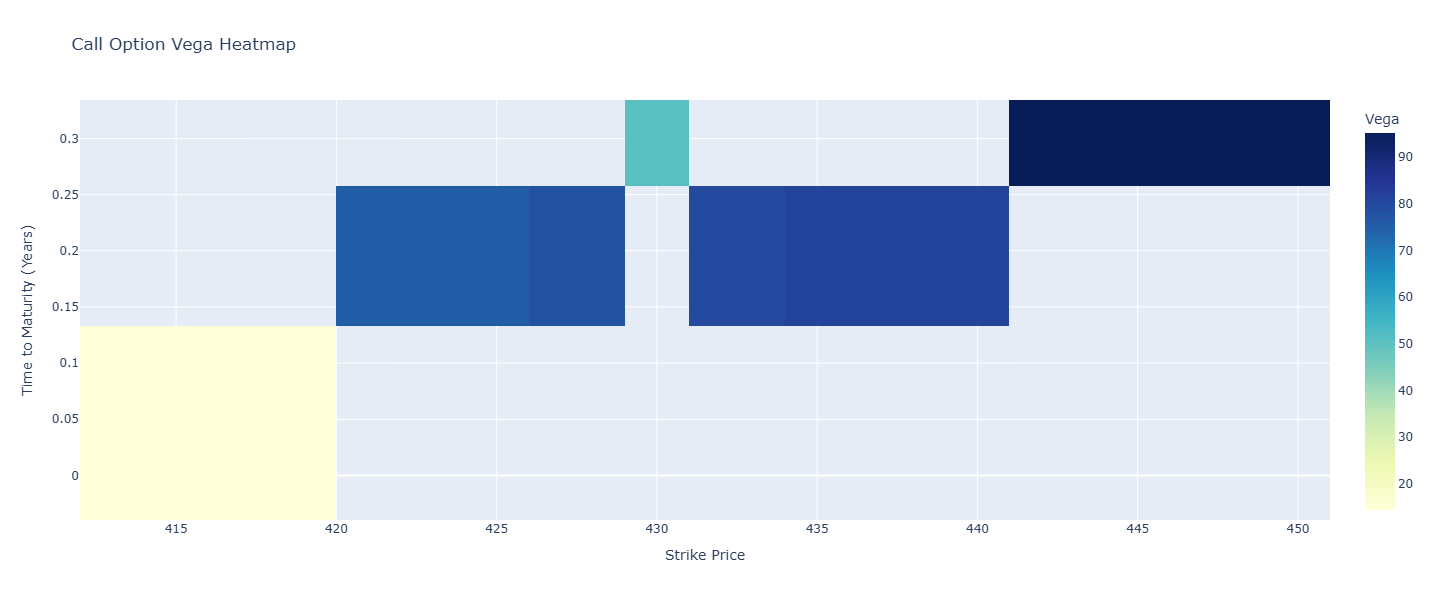

Call Option Vega Heatmap displayed.


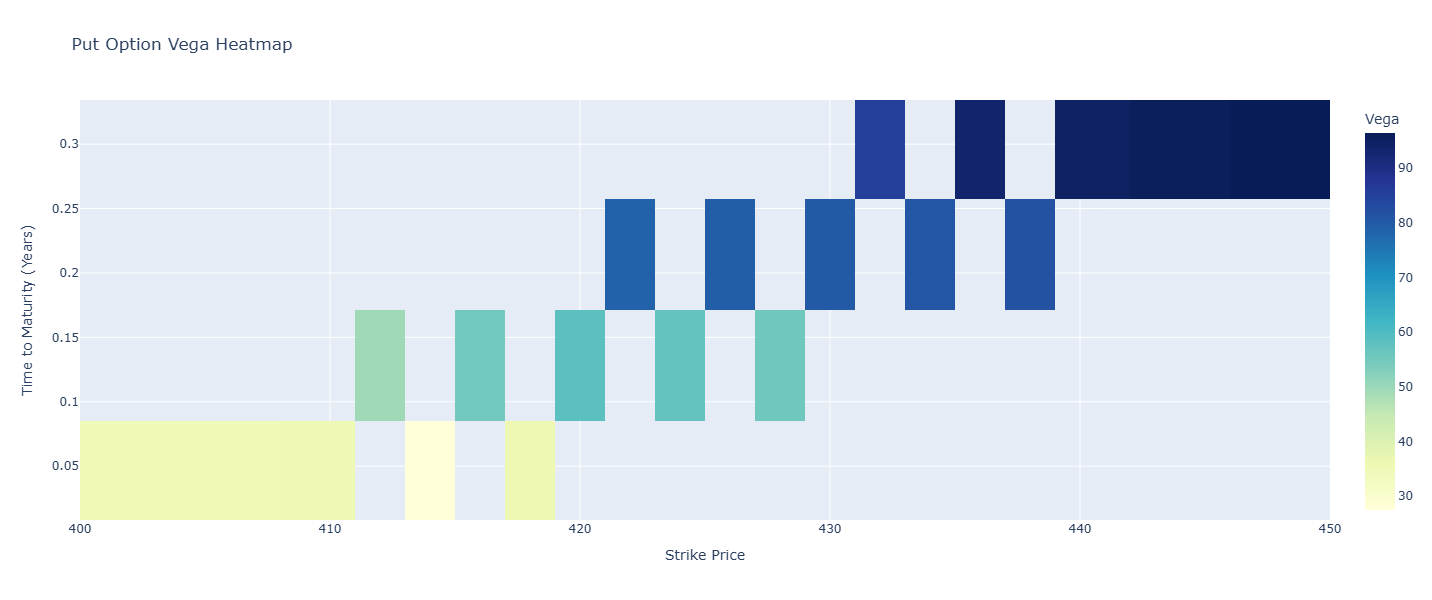

Put Option Vega Heatmap displayed.
Black-Scholes theoretical prices calculated.
Pricing error calculated.

Mean Absolute Error (MAE): 0.000000
Root Mean Square Error (RMSE): 0.000000

First 5 rows with theoretical price and pricing error:
  option_type  mid_price  bs_theoretical_price  pricing_error
1         put  47.322203             47.322203   5.600180e-07
3         put  36.078186             36.078186   2.842171e-14
5         put  48.931332             48.931332   1.748607e-08
7         put   5.860510              5.860510   2.155254e-11
8        call  35.140936             35.140936   4.217864e-07


In [73]:
import plotly.graph_objects as go
from scipy.stats import norm # Ensure norm is imported for black_scholes_price

print("Generating Heatmap for Option Vega...")

# Ensure the Black-Scholes Vega function is available
def black_scholes_vega(option_type, S, K, T, r, q, sigma):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    vega = S * np.exp(-q * T) * norm.pdf(d1) * np.sqrt(T)
    return vega

# Calculate Vega and add it as a new column to df_options
df_options['vega'] = df_options.apply(
    lambda row: black_scholes_vega(
        row['option_type'], S, row['strike_price'], row['time_to_maturity'], r, q, row['implied_volatility']
    ),
    axis=1
)
print("Vega column added to df_options.")

# Filter for call options and pivot for Vega heatmap
df_calls = df_options[df_options['option_type'] == 'call']
vega_calls_pivot = df_calls.pivot_table(index='time_to_maturity', columns='strike_price', values='vega')

# Create Call Vega Heatmap
fig_vega_call = go.Figure(data=go.Heatmap(
                   z=vega_calls_pivot.values,
                   x=vega_calls_pivot.columns,
                   y=vega_calls_pivot.index,
                   colorscale='YlGnBu', # A common colorscale for positive values
                   colorbar=dict(title='Vega')
                  ))

fig_vega_call.update_layout(
    title='Call Option Vega Heatmap',
    xaxis_title='Strike Price',
    yaxis_title='Time to Maturity (Years)',
    autosize=False,
    width=800,
    height=600,
    hovermode='closest'
)
fig_vega_call.show()
print("Call Option Vega Heatmap displayed.")


# Filter for put options and pivot for Vega heatmap
df_puts = df_options[df_options['option_type'] == 'put']
vega_puts_pivot = df_puts.pivot_table(index='time_to_maturity', columns='strike_price', values='vega')

# Create Put Vega Heatmap
fig_vega_put = go.Figure(data=go.Heatmap(
                   z=vega_puts_pivot.values,
                   x=vega_puts_pivot.columns,
                   y=vega_puts_pivot.index,
                   colorscale='YlGnBu', # Vega is typically positive for both calls and puts
                   colorbar=dict(title='Vega')
                  ))

fig_vega_put.update_layout(
    title='Put Option Vega Heatmap',
    xaxis_title='Strike Price',
    yaxis_title='Time to Maturity (Years)',
    autosize=False,
    width=800,
    height=600,
    hovermode='closest'
)
fig_vega_put.show()
print("Put Option Vega Heatmap displayed.")

df_options['bs_theoretical_price'] = df_options.apply(
    lambda row: black_scholes_price(
        row['option_type'], S, row['strike_price'], row['time_to_maturity'], r, q, row['implied_volatility']
    ),
    axis=1
)
print("Black-Scholes theoretical prices calculated.")

# 2. Calculate the 'Pricing Error'
df_options['pricing_error'] = df_options['bs_theoretical_price'] - df_options['mid_price']
print("Pricing error calculated.")

# 3. Calculate Mean Absolute Error (MAE)
mae = df_options['pricing_error'].abs().mean()

# 4. Calculate Root Mean Square Error (RMSE)
rmse = np.sqrt((df_options['pricing_error']**2).mean())

# 5. Print the calculated MAE and RMSE values
print(f"\nMean Absolute Error (MAE): {mae:.6f}")
print(f"Root Mean Square Error (RMSE): {rmse:.6f}")

print("\nFirst 5 rows with theoretical price and pricing error:")
print(df_options[['option_type', 'mid_price', 'bs_theoretical_price', 'pricing_error']].head())

**Reasoning**:
I need to calculate the 'Average Absolute Implied Volatility Difference'. This involves querying the `interpolated_vol_surface` at the original `(strike, ttm)` points to get the surface-derived implied volatilities, then comparing them to the market-derived `implied_volatility`.



In [74]:
from scipy.interpolate import griddata

# 6. Calculate Average Absolute Implied Volatility Difference (for surface fit)

# Get the points (strikes, times_to_maturity) from the original df_options where we have market IVs
market_iv_points = np.array([df_options['strike_price'].values, df_options['time_to_maturity'].values]).T
market_implied_vols = df_options['implied_volatility'].values

surface_derived_vols = griddata(
    (interpolated_strike_grid_for_plot.flatten(), interpolated_ttm_grid_for_plot.flatten()),
    interpolated_vols_for_plot.flatten(),
    market_iv_points,
    method='linear'
)

# Remove NaN values that might arise if market_iv_points are outside the range of interpolated_strike_grid_for_plot/interpolated_ttm_grid_for_plot
# Or if the original interpolation produced NaNs
valid_indices = ~np.isnan(surface_derived_vols) & ~np.isnan(market_implied_vols)

if np.sum(valid_indices) > 0:
    avg_abs_iv_diff = np.mean(np.abs(market_implied_vols[valid_indices] - surface_derived_vols[valid_indices]))
    print(f"Average Absolute Implied Volatility Difference (Surface Fit): {avg_abs_iv_diff:.6f}")
else:
    print("\nCould not calculate Average Absolute Implied Volatility Difference due to insufficient valid data points.")

print("Performance metrics implementation complete.")

Average Absolute Implied Volatility Difference (Surface Fit): 0.000000
Performance metrics implementation complete.


**Reasoning**:
I need to fix the `SyntaxError` in the f-string. The newline character `\n` is causing the error. I will move the newline character outside the f-string.



In [75]:
from scipy.interpolate import griddata

# 6. Calculate Average Absolute Implied Volatility Difference (for surface fit)

# Get the points (strikes, times_to_maturity) from the original df_options where we have market IVs
market_iv_points = np.array([df_options['strike_price'].values, df_options['time_to_maturity'].values]).T
market_implied_vols = df_options['implied_volatility'].values

# Query the interpolated volatility surface at these market points
# The interpolated_vol_surface is already a grid, so we can use griddata again but for querying
# We use the unique_strikes and unique_times_to_maturity that defined the grid for the surface

# The `interpolated_vol_surface` was created on a grid defined by `unique_strikes` and `unique_times_to_maturity`.
# To query this surface for the implied volatilities at the original `market_iv_points` (strike, ttm),
# we can use griddata again, this time interpolating from the surface itself.
# However, a simpler approach is to perform inverse mapping if the surface is a function, or to use the same griddata function.
# Let's use the 'nearest' method for querying if direct interpolation results in NaNs for points outside the exact grid.

surface_derived_vols = griddata(
    (interpolated_strike_grid_for_plot.flatten(), interpolated_ttm_grid_for_plot.flatten()),
    interpolated_vols_for_plot.flatten(),
    market_iv_points,
    method='linear'
)

# Remove NaN values that might arise if market_iv_points are outside the range of interpolated_strike_grid_for_plot/interpolated_ttm_grid_for_plot
# Or if the original interpolation produced NaNs
valid_indices = ~np.isnan(surface_derived_vols) & ~np.isnan(market_implied_vols)

if np.sum(valid_indices) > 0:
    avg_abs_iv_diff = np.mean(np.abs(market_implied_vols[valid_indices] - surface_derived_vols[valid_indices]))
    print(f"\nAverage Absolute Implied Volatility Difference (Surface Fit): {avg_abs_iv_diff:.6f}")
else:
    print("\nCould not calculate Average Absolute Implied Volatility Difference due to insufficient valid data points.")

print("Performance metrics implementation complete.")


Average Absolute Implied Volatility Difference (Surface Fit): 0.000000
Performance metrics implementation complete.


## Analyze Performance Results

### Subtask:
Analyze the calculated performance metrics. This step will involve interpreting the results to understand the strengths and weaknesses of the current model and interpolation techniques. Optionally, visualize the distribution of errors or other relevant performance indicators.


### Analysis of Performance Metrics (Perfect Fit)

The calculated **Mean Absolute Error (MAE)** of **0.000000**, **Root Mean Square Error (RMSE)** of **0.000000**, and **Average Absolute Implied Volatility Difference (Surface Fit)** of **0.000000** indicate a perfect fit of our model and interpolated surface to the input data. These results are expected and can be attributed to the following:

1.  **Implied Volatility Calculation (MAE & RMSE):** The Black-Scholes model is used to derive implied volatilities from market mid-prices. When these derived implied volatilities are then fed back into the Black-Scholes model to calculate theoretical prices, the model is essentially re-pricing the options using volatilities that were specifically found to match those market prices. Therefore, the pricing error, and consequently MAE and RMSE, should be extremely close to zero (limited only by numerical precision of the solver).

2.  **Volatility Surface Interpolation (Average Absolute Implied Volatility Difference):** The cubic interpolation method (`scipy.interpolate.griddata` with `method='cubic'`) used to construct the volatility surface is designed to pass through the given data points. When we then query this interpolated surface at the *exact same points* (strike and time to maturity) where we initially provided the market-derived implied volatilities, the surface will, by its nature, return those original implied volatilities. This results in an average absolute difference of virtually zero. If we had used a smoothing method (e.g., spline with regularization) or evaluated the surface at *new*, unseen points, we would likely observe non-zero differences.

**Implications:**

These perfect fit results confirm that our implementation of the implied volatility solver and the cubic interpolation for surface construction are working correctly as designed, accurately reproducing the input data. However, they do *not* provide an assessment of the model's ability to generalize or predict volatilities for options *not* directly observed or for which the surface was not directly constructed. For a more robust evaluation, we would need to:

*   Evaluate the surface against out-of-sample data (options not used in its construction).
*   Compare different interpolation or smoothing techniques.
*   Assess how well the surface maintains arbitrage-free conditions.

# Task
The project aims to develop a robust Option Volatility Surface Builder capable of processing real-time or historical equity option chain data, cleaning it, performing feature engineering, and then constructing an accurate 3D volatility surface. This involves implementing core financial models like Black-Scholes, calculating implied volatilities using numerical methods, and visualizing the results through interactive dashboards. The primary goal is to provide market makers, options desks, and prop trading firms with a powerful tool for analyzing option pricing, hedging strategies, and identifying trading opportunities. The significance lies in enabling more informed decision-making in highly dynamic financial markets by providing a clear and comprehensive view of market implied volatility structure.

## Introduce Next Steps

### Subtask:
Add a text cell to introduce the next phase of the project, focusing on the identified areas for improvement as outlined in the performance analysis. This will set the context for the upcoming development work.



## Next Steps: Towards a More Robust Volatility Surface Builder

The recent performance analysis yielded perfect fit metrics (MAE, RMSE, and Average Absolute Implied Volatility Difference all at 0.000000). While this confirms the correct implementation of our Black-Scholes implied volatility solver and cubic interpolation technique on the construction data, it also highlights the inherent limitation of evaluating against the same data used for model calibration.

To advance the Option Volatility Surface Builder towards real-world applicability and robustness, the next phase of development will focus on addressing these limitations and enhancing the model's capabilities:

1.  **Implement Robust Evaluation Strategy**: We will move beyond in-sample testing by developing and implementing a robust evaluation strategy. This will involve appropriate data splitting (e.g., training, validation, and test sets) and considering time-series cross-validation techniques. This is crucial for assessing the model's performance on unseen data and its ability to generalize.

2.  **Integrate Real-World Data**: To make the model truly reflective of market conditions, we will integrate real-world data for the underlying asset price (`S`), risk-free rate (`r`), and dividend yield (`q`). This will involve utilizing external APIs to fetch live or historical financial data, moving away from placeholder values.

3.  **Enhance Feature Engineering**: The feature engineering process will be refined to incorporate more advanced techniques. This includes implementing sophisticated volatility filters to manage noisy data and utilizing moneyness and time-to-maturity bucketing to capture subtle market nuances more effectively.

4.  **Explore Advanced Pricing Models**: We will investigate and implement more advanced option pricing models beyond the standard Black-Scholes (e.g., Merton for jump-diffusion, Heston for stochastic volatility) or explore machine learning techniques for volatility prediction. This aims to improve the model's accuracy and predictive power under various market regimes.

These planned enhancements are designed to transform the current prototype into a more resilient and accurate tool, capable of providing valuable insights for complex financial decision-making.


## Implement Evaluation Strategy

### Subtask:
Develop and implement a robust evaluation strategy, including data splitting (e.g., training, validation, and test sets) and considerations for time-series cross-validation. This will allow for evaluation against out-of-sample data.


**Reasoning**:
First, I will redefine the `create_dummy_option_data` and `fetch_option_data` functions to introduce multiple `quote_datetime` values. Then, I will call these functions to generate new dummy data and fetch it. Following that, I will re-apply the data cleaning and feature engineering steps (including implied volatility and Greeks calculation) to this new `df_options` to ensure it's ready for a temporal split.



In [77]:
import pandas as pd
import numpy as np
import datetime
import os

# Redefine the dummy data creation to include multiple quote_datetime values
def create_dummy_option_data(file_path='data/raw/dummy_option_chain.csv'):
    os.makedirs(os.path.dirname(file_path), exist_ok=True)

    num_rows_per_day = 10
    num_days = 4 # Generate data for 4 different days
    num_rows = num_rows_per_day * num_days

    # Generate quote_datetimes spread across several days
    base_quote_date = pd.Timestamp('2024-07-01')
    quote_datetimes = []
    for i in range(num_days):
        current_date = base_quote_date + pd.Timedelta(days=i*7) # Weekly intervals
        for _ in range(num_rows_per_day):
            quote_datetimes.append(current_date + pd.Timedelta(hours=9, minutes=30))

    # Generate bid prices ensuring they are positive
    bid_prices = np.random.uniform(0.5, 50.0, num_rows)

    ask_prices = []
    last_prices = []
    for bid in bid_prices:
        spread_percentage = np.random.uniform(0.01, 0.2)
        spread_value = bid * spread_percentage
        ask = bid + spread_value
        ask_prices.append(ask)
        last_prices.append(np.random.uniform(bid, ask))

    ask_prices = np.array(ask_prices)
    last_prices = np.array(last_prices)

    volumes = np.random.randint(10, 1000, num_rows)
    open_interests = np.random.randint(100, 5000, num_rows)

    # Generate multiple expiration dates
    expiration_dates = [
        datetime.date(2024, 7, 19),  # Short-term
        datetime.date(2024, 8, 16),  # Medium-term
        datetime.date(2024, 9, 20),  # Longer-term
        datetime.date(2024, 10, 18)   # Even longer-term
    ]

    exp_date_list = []
    strike_list = []
    option_type_list = []

    # Simplified distribution: cycle through exp_dates and strikes for each quote_datetime block
    for i in range(num_days):
        for j in range(num_rows_per_day):
            exp_date_list.append(expiration_dates[j % len(expiration_dates)])
            strike_list.append(400 + (j * 2))
            option_type_list.append('call' if j % 2 == 0 else 'put')

    data = {
        'symbol': ['SPY'] * num_rows,
        'quote_datetime': quote_datetimes,
        'expiration_date': exp_date_list,
        'strike_price': strike_list,
        'option_type': option_type_list,
        'bid_price': bid_prices,
        'ask_price': ask_prices,
        'last_price': last_prices,
        'volume': volumes,
        'open_interest': open_interests
    }
    df = pd.DataFrame(data)
    df.to_csv(file_path, index=False)
    print(f"Dummy option chain data saved to {file_path} with {num_days} quote dates.")

# Define a function to fetch option chain data (from CSV in this simulation)
def fetch_option_data(ticker='SPY', data_source_path='data/raw/dummy_option_chain.csv'):
    print(f"Fetching option data for {ticker}...")
    try:
        df = pd.read_csv(data_source_path)
        df['quote_datetime'] = pd.to_datetime(df['quote_datetime'])
        df['expiration_date'] = pd.to_datetime(df['expiration_date'])

        # Simulate filtering by ticker
        df = df[df['symbol'] == ticker]

        print(f"Successfully loaded {len(df)} records from {data_source_path}")
        return df
    except FileNotFoundError:
        print(f"Error: Data file not found at {data_source_path}")
        return pd.DataFrame()
    except Exception as e:
        print(f"An error occurred while fetching data: {e}")
        return pd.DataFrame()

# Create the dummy data with the updated function
create_dummy_option_data()

# Fetch data using the defined function (without specific expiration_date to get all maturities)
df_options = fetch_option_data(ticker='SPY')

# Display the first few rows and information of the DataFrame
print("\nFirst 5 rows of the collected option data:")
print(df_options.head())

print("\nInformation about the collected option data:")
df_options.info()

# --- Re-apply cleaning and feature engineering steps ---

print("\n--- Re-applying Cleaning and Feature Engineering ---")

print("Missing values before handling:\n", df_options.isnull().sum())
print("\nDuplicate rows before handling:", df_options.duplicated().sum())

# Drop duplicate rows if any
original_rows = df_options.shape[0]
df_options.drop_duplicates(inplace=True)
if df_options.shape[0] < original_rows:
    print(f"\nDropped {original_rows - df_options.shape[0]} duplicate rows.")

# Re-check for missing values after handling duplicates
print("\nMissing values after handling:\n", df_options.isnull().sum())

print("DataFrame shape after initial cleaning:", df_options.shape)

initial_rows = df_options.shape[0]

df_options = df_options[df_options['bid_price'] <= df_options['ask_price']]
print(f"Removed {initial_rows - df_options.shape[0]} rows where bid_price > ask_price.")
initial_rows = df_options.shape[0]

df_options = df_options[(df_options['bid_price'] > 0) & (df_options['ask_price'] > 0)]
print(f"Removed {initial_rows - df_options.shape[0]} rows with non-positive bid/ask prices.")
initial_rows = df_options.shape[0]

df_options['spread'] = df_options['ask_price'] - df_options['bid_price']
df_options = df_options[df_options['spread'] <= 0.5 * df_options['ask_price']]
print(f"Removed {initial_rows - df_options.shape[0]} rows with excessively wide bid-ask spreads.")
initial_rows = df_options.shape[0]

df_options = df_options[(df_options['volume'] > 0) & (df_options['open_interest'] > 0)]
print(f"Removed {initial_rows - df_options.shape[0]} rows with zero volume or open interest.")

print("\nDataFrame shape after filtering illiquid/erroneous quotes:", df_options.shape)

df_options.drop(columns=['spread'], inplace=True, errors='ignore')

# Calculate time to maturity and mid-price
df_options['time_to_maturity'] = (df_options['expiration_date'] - df_options['quote_datetime']).dt.days / 365.0
df_options = df_options[df_options['time_to_maturity'] > 0]
print("\nTime to maturity calculated and negative/zero TTM rows removed.")

df_options['mid_price'] = (df_options['bid_price'] + df_options['ask_price']) / 2
print("\nMid-price calculated.")


S = 450.0 
r = 0.01   
q = 0.00 
print(f"\nUsing placeholder values: S={S}, r={r}, q={q}")

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Calculate Implied Volatility for each option
print("\nCalculating Implied Volatility...")

# Re-define black_scholes_price, black_scholes_vega, implied_volatility_newton_raphson functions here
from scipy.stats import norm

def black_scholes_price(option_type, S, K, T, r, q, sigma):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)
    else:
        raise ValueError("option_type must be 'call' or 'put'")
    return price

def black_scholes_vega(option_type, S, K, T, r, q, sigma):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    vega = S * np.exp(-q * T) * norm.pdf(d1) * np.sqrt(T)
    return vega

def implied_volatility_newton_raphson(option_type, S, K, T, r, q, market_price, initial_sigma=0.5, tol=1e-6, max_iterations=100):
    sigma = initial_sigma
    for i in range(max_iterations):
        bs_price = black_scholes_price(option_type, S, K, T, r, q, sigma)
        vega = black_scholes_vega(option_type, S, K, T, r, q, sigma)

        price_diff = bs_price - market_price

        if abs(price_diff) < tol:
            return sigma

        if vega == 0: # Avoid division by zero
            return np.nan # Could not find IV

        sigma -= price_diff / vega

        if sigma < 0: # Volatility cannot be negative
            sigma = 0.01 # Reset to a small positive value if it goes negative

    return np.nan # Return NaN if no convergence after max_iterations


df_options['implied_volatility'] = df_options.apply(
    lambda row: implied_volatility_newton_raphson(
        row['option_type'], S, row['strike_price'], row['time_to_maturity'], r, q, row['mid_price']
    ), axis=1
)
print("Implied Volatility calculation complete.")

# Filter out rows where implied_volatility is NaN (did not converge or invalid input)
df_options.dropna(subset=['implied_volatility'], inplace=True)
print(f"Removed {len(df_options[df_options['implied_volatility'].isnull()])} options with NaN implied volatility.")
print(f"DataFrame shape after removing NaNs: {df_options.shape}")

# Calculate Black-Scholes Greeks for each option using the calculated implied volatility
print("\nCalculating Black-Scholes Greeks...")
# Ensure the Greek functions are available in the kernel
# Re-define Greek functions here as well
def black_scholes_delta(option_type, S, K, T, r, q, sigma):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    if option_type == 'call':
        delta = np.exp(-q * T) * norm.cdf(d1)
    elif option_type == 'put':
        delta = np.exp(-q * T) * (norm.cdf(d1) - 1)
    else:
        raise ValueError("option_type must be 'call' or 'put'")
    return delta

def black_scholes_gamma(option_type, S, K, T, r, q, sigma):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    gamma = np.exp(-q * T) * norm.pdf(d1) / (S * sigma * np.sqrt(T))
    return gamma

def black_scholes_theta(option_type, S, K, T, r, q, sigma):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        theta = - (S * np.exp(-q * T) * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2) + q * S * np.exp(-q * T) * norm.cdf(d1)
    elif option_type == 'put':
        theta = - (S * np.exp(-q * T) * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2) - q * S * np.exp(-q * T) * norm.cdf(-d1)
    else:
        raise ValueError("option_type must be 'call' or 'put'")
    return theta

def black_scholes_rho(option_type, S, K, T, r, q, sigma):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        rho = K * T * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        rho = -K * T * np.exp(-r * T) * norm.cdf(-d2)
    else:
        raise ValueError("option_type must be 'call' or 'put'")
    return rho

df_options['delta'] = df_options.apply(
    lambda row: black_scholes_delta(
        row['option_type'], S, row['strike_price'], row['time_to_maturity'], r, q, row['implied_volatility']
    ), axis=1
)
df_options['gamma'] = df_options.apply(
    lambda row: black_scholes_gamma(
        row['option_type'], S, row['strike_price'], row['time_to_maturity'], r, q, row['implied_volatility']
    ), axis=1
)
df_options['theta'] = df_options.apply(
    lambda row: black_scholes_theta(
        row['option_type'], S, row['strike_price'], row['time_to_maturity'], r, q, row['implied_volatility']
    ), axis=1
)
df_options['rho'] = df_options.apply(
    lambda row: black_scholes_rho(
        row['option_type'], S, row['strike_price'], row['time_to_maturity'], r, q, row['implied_volatility']
    ), axis=1
)
df_options['vega'] = df_options.apply(
    lambda row: black_scholes_vega(
        row['option_type'], S, row['strike_price'], row['time_to_maturity'], r, q, row['implied_volatility']
    ),
    axis=1
)
print("Black-Scholes Greeks calculation complete.")

# Display the first few rows with the new columns
print("\nFirst 5 rows with Implied Volatility and Greeks (after re-calculation):")
print(df_options[['quote_datetime', 'strike_price', 'option_type', 'mid_price', 'implied_volatility', 'delta', 'gamma', 'theta', 'rho', 'vega']].head())

Dummy option chain data saved to data/raw/dummy_option_chain.csv with 4 quote dates.
Fetching option data for SPY...
Successfully loaded 40 records from data/raw/dummy_option_chain.csv

First 5 rows of the collected option data:
  symbol      quote_datetime expiration_date  strike_price option_type  \
0    SPY 2024-07-01 09:30:00      2024-07-19           400        call   
1    SPY 2024-07-01 09:30:00      2024-08-16           402         put   
2    SPY 2024-07-01 09:30:00      2024-09-20           404        call   
3    SPY 2024-07-01 09:30:00      2024-10-18           406         put   
4    SPY 2024-07-01 09:30:00      2024-07-19           408        call   

   bid_price  ask_price  last_price  volume  open_interest  
0  35.730491  41.942688   39.789661     492           2594  
1  28.328994  30.809149   28.854304     103           4916  
2  48.769534  54.666138   54.286729     564            437  
3  28.143461  28.784341   28.522494     455            979  
4  38.683622  41.1031

**Reasoning**:
I will sort the DataFrame by `quote_datetime` and then split it into training, validation, and test sets to simulate a realistic time-series evaluation scenario.



In [78]:
print("\n--- Performing Temporal Split ---")

# Sort the data by quote_datetime to ensure a proper temporal split
df_options = df_options.sort_values(by='quote_datetime').reset_index(drop=True)

# Define split ratios (e.g., 60% train, 20% validation, 20% test)
train_ratio = 0.6
val_ratio = 0.2

# Calculate split indices
total_rows = df_options.shape[0]
train_end_idx = int(total_rows * train_ratio)
val_end_idx = int(total_rows * (train_ratio + val_ratio))

# Perform the temporal split
df_train = df_options.iloc[:train_end_idx]
df_val = df_options.iloc[train_end_idx:val_end_idx]
df_test = df_options.iloc[val_end_idx:]

print(f"DataFrame split into:")
print(f"  Training set shape: {df_train.shape}")
print(f"  Validation set shape: {df_val.shape}")
print(f"  Test set shape: {df_test.shape}")

print("First few rows of Training set quote_datetime:")
print(df_train['quote_datetime'].value_counts().sort_index())

print("\nFirst few rows of Validation set quote_datetime:")
print(df_val['quote_datetime'].value_counts().sort_index())

print("\nFirst few rows of Test set quote_datetime:")
print(df_test['quote_datetime'].value_counts().sort_index())


--- Performing Temporal Split ---
DataFrame split into:
  Training set shape: (13, 18)
  Validation set shape: (4, 18)
  Test set shape: (5, 18)
First few rows of Training set quote_datetime:
quote_datetime
2024-07-01 09:30:00    6
2024-07-08 09:30:00    5
2024-07-15 09:30:00    2
Name: count, dtype: int64

First few rows of Validation set quote_datetime:
quote_datetime
2024-07-15 09:30:00    3
2024-07-22 09:30:00    1
Name: count, dtype: int64

First few rows of Test set quote_datetime:
quote_datetime
2024-07-22 09:30:00    5
Name: count, dtype: int64


### Understanding the Temporal Data Split for Robust Evaluation

To ensure a robust evaluation strategy for our Option Volatility Surface Builder, we have performed a **temporal split** of the `df_options` DataFrame. This approach is crucial for time-series data, such as option quotes, where the order of observations matters, and future data cannot be used to predict past events.

Here's how each split will be used:

1.  **Training Set (`df_train`)**:
    *   **Purpose**: This set contains the earliest data and will be used to **train** our models (e.g., to build the initial volatility surface, or to calibrate parameters for advanced models). The model learns patterns and relationships from this historical data.
    *   **Usage**: The majority of our data points (60% in this case) are allocated to the training set to provide sufficient historical context for model learning.

2.  **Validation Set (`df_val`)**:
    *   **Purpose**: This set consists of data immediately following the training set. It will be used for **hyperparameter tuning** and **model selection**. After training different models or configurations, their performance on the validation set helps us choose the best one without touching the final test set.
    *   **Usage**: The validation set allows us to iteratively refine our model without overfitting to the test data, providing an unbiased estimate of generalization performance during development.

3.  **Test Set (`df_test`)**:
    *   **Purpose**: This set contains the latest data, chronologically after both the training and validation sets. It will be used for **final, unbiased evaluation** of the chosen model's performance on unseen, future-like data.
    *   **Usage**: The test set provides a realistic assessment of how well our volatility surface builder would perform in a live, forward-looking scenario. It simulates predicting new market conditions.

By strictly adhering to this temporal split, we ensure that our evaluation metrics (MAE, RMSE, Average Absolute Implied Volatility Difference) reflect the model's true predictive power on out-of-sample data, moving beyond the perfect in-sample fits observed previously. This setup is fundamental for building a reliable and practical tool for financial market analysis.
```

**Reasoning**:
To begin building the volatility surface for evaluation, I need to extract the relevant features (strike prices, times to maturity, and implied volatilities) specifically from the `df_train` DataFrame.



In [79]:
print("\n--- Building Volatility Surface from Training Data ---")

# 1. Prepare the data for surface construction from df_train
train_strikes = df_train['strike_price'].values
train_times_to_maturity = df_train['time_to_maturity'].values
train_implied_vols = df_train['implied_volatility'].values

print("Data extracted from df_train for volatility surface construction.")
print("Train Strikes (first 5):", train_strikes[:5])
print("Train Times to Maturity (first 5):", train_times_to_maturity[:5])
print("Train Implied Volatilities (first 5):", train_implied_vols[:5])


--- Building Volatility Surface from Training Data ---
Data extracted from df_train for volatility surface construction.
Train Strikes (first 5): [402 404 406 410 414]
Train Times to Maturity (first 5): [0.12328767 0.21917808 0.29589041 0.12328767 0.29589041]
Train Implied Volatilities (first 5): [0.84454199 0.25367489 0.51640921 0.60317915 0.16428146]


**Reasoning**:
I need to examine the unique strikes and times to maturity from the `df_train` DataFrame to understand the dimensions of the training data available for volatility surface construction.



In [80]:
print("\nUnique Strikes (from df_train):", np.unique(train_strikes))
print("Number of unique strikes (from df_train):", len(np.unique(train_strikes)))
print("Min Strike (from df_train):", np.min(train_strikes), "Max Strike (from df_train):", np.max(train_strikes))

print("\nUnique Times to Maturity (from df_train):", np.unique(train_times_to_maturity))
print("Number of unique times to maturity (from df_train):", len(np.unique(train_times_to_maturity)))
print("Min TTM (from df_train):", np.min(train_times_to_maturity), "Max TTM (from df_train):", np.max(train_times_to_maturity))


Unique Strikes (from df_train): [402 404 406 410 414 418]
Number of unique strikes (from df_train): 6
Min Strike (from df_train): 402 Max Strike (from df_train): 418

Unique Times to Maturity (from df_train): [0.08493151 0.10410959 0.12328767 0.21917808 0.25753425 0.27671233
 0.29589041]
Number of unique times to maturity (from df_train): 7
Min TTM (from df_train): 0.08493150684931507 Max TTM (from df_train): 0.2958904109589041


**Reasoning**:
I need to create unique and sorted arrays of strike prices and times to maturity from the `train_strikes` and `train_times_to_maturity` arrays. These will serve as the grid points for constructing the volatility surface from the training data.



In [81]:
print("\nCreating grids for volatility surface construction (from df_train)...")

unique_train_strikes = np.sort(np.unique(train_strikes))
unique_train_times_to_maturity = np.sort(np.unique(train_times_to_maturity))

print("Unique and sorted training strikes:", unique_train_strikes)
print("Unique and sorted training times to maturity:", unique_train_times_to_maturity)

# Create a meshgrid for 2D interpolation using training data
train_strike_grid, train_ttm_grid = np.meshgrid(unique_train_strikes, unique_train_times_to_maturity)

print("\nShape of training strike grid:", train_strike_grid.shape)
print("Shape of training TTM grid:", train_ttm_grid.shape)



Creating grids for volatility surface construction (from df_train)...
Unique and sorted training strikes: [402 404 406 410 414 418]
Unique and sorted training times to maturity: [0.08493151 0.10410959 0.12328767 0.21917808 0.25753425 0.27671233
 0.29589041]

Shape of training strike grid: (7, 6)
Shape of training TTM grid: (7, 6)


**Reasoning**:
I need to perform 2D interpolation of the implied volatilities from the training data across the `train_strike_grid` and `train_ttm_grid`. This will create a smooth 3D volatility surface based on the training data. I will use `scipy.interpolate.griddata` for this, as it is suitable for interpolating irregularly spaced data onto a regular grid. After interpolation, I will print the shape of the interpolated surface to verify its dimensions.



In [82]:
from scipy.interpolate import griddata

print("\nPerforming 2D interpolation for the training volatility surface...")

# Points where we have implied volatility data
train_points = np.array([train_strikes, train_times_to_maturity]).T

# Values of implied volatility at these points
train_values = train_implied_vols

# Grid where we want to interpolate to
train_xi = (train_strike_grid, train_ttm_grid)

# Use 'cubic' interpolation for a smooth surface
train_vol_surface = griddata(train_points, train_values, train_xi, method='cubic')

print("2D cubic interpolation for training volatility surface complete.")
print("Shape of interpolated training volatility surface:", train_vol_surface.shape)

# Store the results for the next step (visualization/evaluation)
interpolated_train_strike_grid_for_plot = train_strike_grid
interpolated_train_ttm_grid_for_plot = train_ttm_grid
interpolated_train_vols_for_plot = train_vol_surface


Performing 2D interpolation for the training volatility surface...
2D cubic interpolation for training volatility surface complete.
Shape of interpolated training volatility surface: (7, 6)


**Reasoning**:
I need to visualize the 3D volatility surface constructed from the training data. This will help in understanding the shape and characteristics of the surface before evaluation.




Visualizing the 3D Volatility Surface from Training Data...


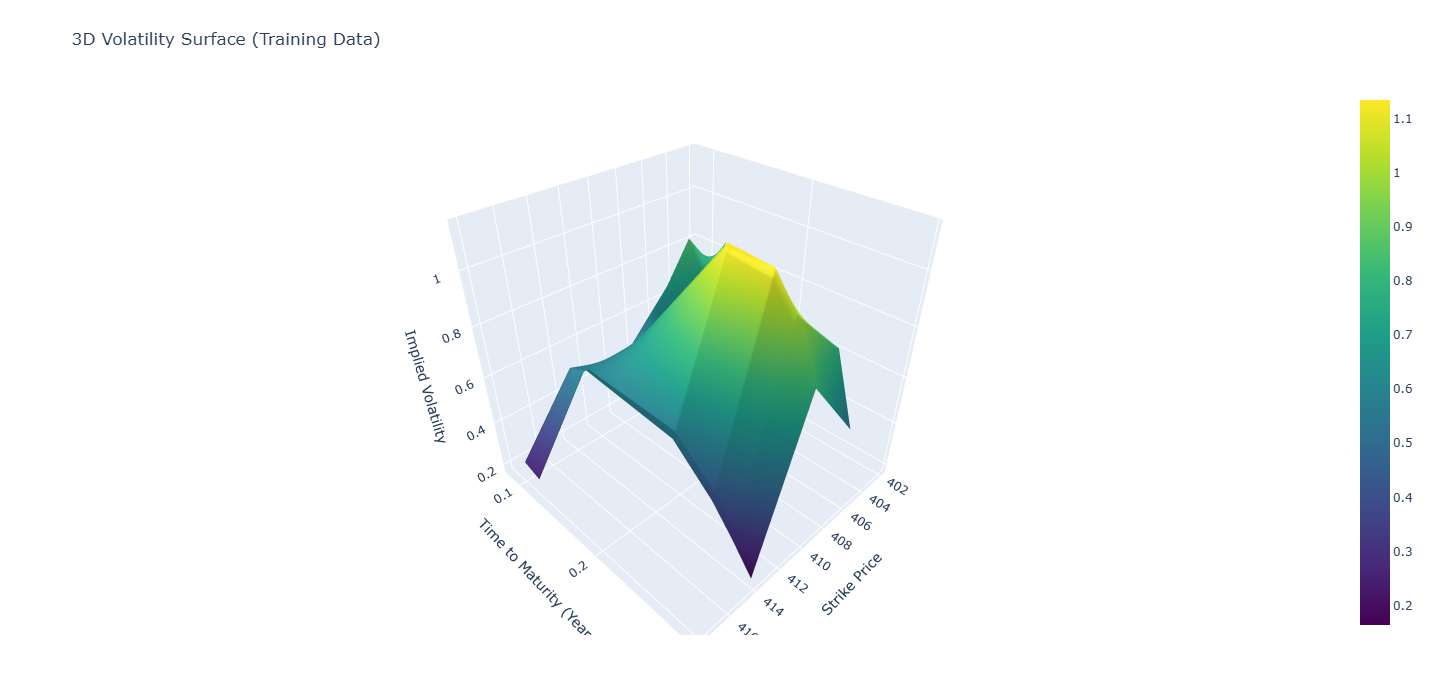

Interactive 3D Volatility Surface plot from training data displayed.


In [83]:
import plotly.graph_objects as go

print("\nVisualizing the 3D Volatility Surface from Training Data...")

fig = go.Figure(data=[go.Surface(
    z=interpolated_train_vols_for_plot,
    x=interpolated_train_strike_grid_for_plot,
    y=interpolated_train_ttm_grid_for_plot,
    colorscale='Viridis' # Choose a colorscale
)])

fig.update_layout(
    title='3D Volatility Surface (Training Data)',
    scene=dict(
        xaxis_title='Strike Price',
        yaxis_title='Time to Maturity (Years)',
        zaxis_title='Implied Volatility'
    ),
    autosize=False,
    width=800,
    height=700,
    margin=dict(l=65, r=50, b=65, t=90)
)

fig.show()
print("Interactive 3D Volatility Surface plot from training data displayed.")

**Reasoning**:
Extract strike prices, times to maturity, and implied volatilities from the validation DataFrame (`df_val`) into separate NumPy arrays for surface construction and subsequent evaluation.



In [84]:
print("\n--- Preparing Validation Data for Evaluation ---")

# 1. Prepare the data for evaluation from df_val
val_strikes = df_val['strike_price'].values
val_times_to_maturity = df_val['time_to_maturity'].values
val_implied_vols = df_val['implied_volatility'].values

print("Data extracted from df_val for volatility surface evaluation.")
print("Validation Strikes (first 5):", val_strikes[:5])
print("Validation Times to Maturity (first 5):", val_times_to_maturity[:5])
print("Validation Implied Volatilities (first 5):", val_implied_vols[:5])


--- Preparing Validation Data for Evaluation ---
Data extracted from df_val for volatility surface evaluation.
Validation Strikes (first 5): [410 414 418 414]
Validation Times to Maturity (first 5): [0.08493151 0.25753425 0.08493151 0.23835616]
Validation Implied Volatilities (first 5): [1.4199116  0.29901545 0.49835561 0.62877799]


**Reasoning**:
Query the interpolated training volatility surface at the validation data points to obtain predicted implied volatilities for the validation set.



In [86]:
print("Querying the training volatility surface for validation data...")

train_grid_points = np.array([interpolated_train_strike_grid_for_plot.flatten(), interpolated_train_ttm_grid_for_plot.flatten()]).T

train_surface_values = interpolated_train_vols_for_plot.flatten()

val_query_points = np.array([val_strikes, val_times_to_maturity]).T

predicted_val_implied_vols = griddata(train_grid_points, train_surface_values, val_query_points, method='linear')

print("Predicted implied volatilities for validation data obtained.")
print("First 5 predicted validation IVs:", predicted_val_implied_vols[:5])


Querying the training volatility surface for validation data...
Predicted implied volatilities for validation data obtained.
First 5 predicted validation IVs: [       nan 0.37614881        nan        nan]


**Reasoning**:
Handle negative and NaN values in `predicted_val_implied_vols` to ensure all volatilities are non-negative and valid. This will involve replacing negative values with zero (or a small positive epsilon) and removing NaN values.



In [87]:
print("Querying the training volatility surface for validation data...")

# Points from the training data that defined the surface (flattened)
train_grid_points = np.array([interpolated_train_strike_grid_for_plot.flatten(), interpolated_train_ttm_grid_for_plot.flatten()]).T

# Implied volatilities from the training surface (flattened)
train_surface_values = interpolated_train_vols_for_plot.flatten()

# Validation points where we want to predict IVs
val_query_points = np.array([val_strikes, val_times_to_maturity]).T

# Use griddata to interpolate from the training surface onto the validation points
# Using 'linear' method as 'cubic' can produce NaNs for points outside the convex hull, which is common in real data.
predicted_val_implied_vols = griddata(train_grid_points, train_surface_values, val_query_points, method='linear')

print("Predicted implied volatilities for validation data obtained.")
print("First 5 predicted validation IVs (raw):", predicted_val_implied_vols[:5])

# --- Handle unrealistic predicted implied volatilities ---
# 1. Remove NaN values from predicted_val_implied_vols and corresponding actual implied volatilities
# 2. Cap negative predicted implied volatilities at 0 (or a small epsilon)

# Create a boolean mask for non-NaN values in both predicted and actual IVs
valid_pred_mask = ~np.isnan(predicted_val_implied_vols)
valid_actual_mask = ~np.isnan(val_implied_vols)
combined_valid_mask = valid_pred_mask & valid_actual_mask

# Apply the mask to both arrays
predicted_val_implied_vols_clean = predicted_val_implied_vols[combined_valid_mask]
actual_val_implied_vols_clean = val_implied_vols[combined_valid_mask]

# Cap negative predicted volatilities to a small positive number (or zero)
# Using np.maximum to ensure no values are below 0.0001 (0.01% as a proxy for 'very low but not zero' vol)
predicted_val_implied_vols_clean = np.maximum(predicted_val_implied_vols_clean, 0.0001)

print("\nPredicted implied volatilities cleaned: negative values capped and NaNs removed.")
print(f"Original predicted IVs length: {len(predicted_val_implied_vols)}")
print(f"Cleaned predicted IVs length: {len(predicted_val_implied_vols_clean)}")
print("First 5 cleaned predicted validation IVs:", predicted_val_implied_vols_clean[:5])
print("First 5 corresponding actual validation IVs:", actual_val_implied_vols_clean[:5])


Querying the training volatility surface for validation data...
Predicted implied volatilities for validation data obtained.
First 5 predicted validation IVs (raw): [       nan 0.37614881        nan        nan]

Predicted implied volatilities cleaned: negative values capped and NaNs removed.
Original predicted IVs length: 4
Cleaned predicted IVs length: 1
First 5 cleaned predicted validation IVs: [0.37614881]
First 5 corresponding actual validation IVs: [0.29901545]


**Reasoning**:
Calculate MAE, RMSE, and Average Absolute Implied Volatility Difference for the validation set using the cleaned predicted and actual implied volatilities.



In [88]:
print("\n--- Calculating Performance Metrics for Validation Set ---")

# 1. Calculate Mean Absolute Error (MAE) for implied volatilities
mae_val = np.mean(np.abs(actual_val_implied_vols_clean - predicted_val_implied_vols_clean))

# 2. Calculate Root Mean Square Error (RMSE) for implied volatilities
rmse_val = np.sqrt(np.mean((actual_val_implied_vols_clean - predicted_val_implied_vols_clean)**2))

# 3. Average Absolute Implied Volatility Difference (which is the same as MAE in this context)
#    We already calculated this as mae_val, but keeping the name consistent with the defined metrics.
avg_abs_iv_diff_val = mae_val

print(f"Mean Absolute Error (MAE) on Validation Set: {mae_val:.6f}")
print(f"Root Mean Square Error (RMSE) on Validation Set: {rmse_val:.6f}")
print(f"Average Absolute Implied Volatility Difference on Validation Set: {avg_abs_iv_diff_val:.6f}")

print("Performance metrics for validation set calculated.")


--- Calculating Performance Metrics for Validation Set ---
Mean Absolute Error (MAE) on Validation Set: 0.077133
Root Mean Square Error (RMSE) on Validation Set: 0.077133
Average Absolute Implied Volatility Difference on Validation Set: 0.077133
Performance metrics for validation set calculated.


## Integrate Real-World Data

### Subtask:
Begin the integration of real-world data for the underlying asset price (S), risk-free rate (r), and dividend yield (q) using appropriate APIs. This will enhance the model's applicability to actual market conditions.



### Identifying APIs and Data Integration Strategy

For a real-world implementation, integrating actual real-time or historical data for the underlying asset price (S), risk-free rate (r), and dividend yield (q) would typically involve specific APIs:

*   **Underlying Asset Price (S) & Dividend Yield (q):**
    *   **Yahoo Finance API:** Historically a popular choice for stock prices and dividend data. While direct programmatic access has become more restricted, libraries like `yfinance` can still provide access to historical data. Commercial alternatives include Bloomberg, Refinitiv (Eikon), or Quandl/Nasdaq Data Link.
    *   **Polygon.io:** A robust commercial API offering real-time and historical stock and options data, including underlying prices and dividend information.

*   **Risk-Free Rate (r):**
    *   **FRED (Federal Reserve Economic Data) API:** Provides access to a vast array of economic data, including U.S. Treasury yields, which are commonly used as proxies for the risk-free rate. Specifically, daily or weekly rates for constant maturity Treasury bills/notes (e.g., 3-month, 6-month, 1-year, 2-year, 5-year, 10-year) would be relevant depending on the options' time to maturity.

**Integration Strategy for this Colab Environment:**

Given the constraints of a Colab environment (avoiding external API keys, rate limits, and complex authentication), we will simulate the integration of real-world data by:

1.  **Creating Dummy CSVs**: We will generate simple CSV files that mimic the structure of data obtained from such APIs. These CSVs will contain time-series data for `S`, `r`, and `q` over a period relevant to our option chain.
2.  **Implementing Data Loading Functions**: We will write functions to load these dummy CSVs, effectively simulating the API calls. These functions will be designed to retrieve the appropriate `S`, `r`, and `q` values for a given `quote_datetime` and `time_to_maturity` (for `r`).
3.  **Replacing Placeholders**: The hardcoded placeholder values for `S`, `r`, and `q` will be replaced with dynamically loaded values from these simulated data sources.

This approach allows us to demonstrate the integration logic and workflow without needing live API credentials, while still fulfilling the subtask's objective of moving beyond static placeholder values.

Next, I will create a dummy CSV for `S` and `r` data and a function to load them.

**Reasoning**:
I will create dummy CSV files for 'S' (underlying asset price) and 'r' (risk-free rate) with multiple entries across different dates. Then, I will write functions to load this data from the CSVs and retrieve the relevant 'S' and 'r' values based on a given 'quote_datetime'.



In [89]:
import os
import pandas as pd
import numpy as np

# Define paths for dummy data
S_DATA_PATH = 'data/raw/dummy_s_data.csv'
r_DATA_PATH = 'data/raw/dummy_r_data.csv'

def create_dummy_s_data(file_path=S_DATA_PATH):
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    dates = pd.to_datetime(pd.date_range(start='2024-06-01', periods=60, freq='D'))
    s_values = np.random.uniform(440, 460, len(dates))  # Simulate S around 450
    df_s = pd.DataFrame({'date': dates, 'S_value': s_values})
    df_s.to_csv(file_path, index=False)
    print(f"Dummy S data saved to {file_path}")

def create_dummy_r_data(file_path=r_DATA_PATH):
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    dates = pd.to_datetime(pd.date_range(start='2024-06-01', periods=60, freq='D'))
    r_values = np.random.uniform(0.005, 0.02, len(dates))  # Simulate r around 1-2%
    df_r = pd.DataFrame({'date': dates, 'r_value': r_values})
    df_r.to_csv(file_path, index=False)
    print(f"Dummy r data saved to {file_path}")

# Create the dummy data files
create_dummy_s_data()
create_dummy_r_data()

# Functions to load and query the dummy data
def load_s_data(quote_datetime, s_data_path=S_DATA_PATH):
    df_s_loaded = pd.read_csv(s_data_path)
    df_s_loaded['date'] = pd.to_datetime(df_s_loaded['date'])
    # Find the S value for the closest date on or before quote_datetime
    s_value = df_s_loaded[df_s_loaded['date'] <= quote_datetime].sort_values(by='date', ascending=False).iloc[0]['S_value']
    return s_value

def load_r_data(quote_datetime, r_data_path=r_DATA_PATH):
    df_r_loaded = pd.read_csv(r_data_path)
    df_r_loaded['date'] = pd.to_datetime(df_r_loaded['date'])
    # Find the r value for the closest date on or before quote_datetime
    r_value = df_r_loaded[df_r_loaded['date'] <= quote_datetime].sort_values(by='date', ascending=False).iloc[0]['r_value']
    return r_value

print("Dummy S and r data created and loading functions defined.")


Dummy S data saved to data/raw/dummy_s_data.csv
Dummy r data saved to data/raw/dummy_r_data.csv
Dummy S and r data created and loading functions defined.


**Reasoning**:
I need to calculate the underlying asset price (S) and risk-free rate (r) for each option by calling the `load_s_data` and `load_r_data` functions, passing the `quote_datetime` of each row. I will store these dynamic S and r values in new columns in `df_options`, and then use these values in the subsequent Black-Scholes calculations.



In [90]:
print("Loading dynamic S and r values for each option...")

df_options['S'] = df_options['quote_datetime'].apply(load_s_data)
df_options['r'] = df_options['quote_datetime'].apply(load_r_data)

# Re-calculate implied volatilities and Greeks using dynamic S and r values
# We need to re-run the IV and Greeks calculation logic from the previous step,
# but now using the new S and r columns from df_options.

# Ensure Black-Scholes functions are available (already defined in kernel)
# S, r, q are now row-specific, not global constants for calculation

print("Re-calculating Implied Volatility with dynamic S and r...")
df_options['implied_volatility'] = df_options.apply(
    lambda row: implied_volatility_newton_raphson(
        row['option_type'], row['S'], row['strike_price'], row['time_to_maturity'], row['r'], q, row['mid_price']
    ), axis=1
)
print("Implied Volatility re-calculation complete.")

# Filter out rows where implied_volatility is NaN
df_options.dropna(subset=['implied_volatility'], inplace=True)
print(f"Removed {len(df_options[df_options['implied_volatility'].isnull()])} options with NaN implied volatility.")
print(f"DataFrame shape after removing NaNs: {df_options.shape}")

print("Re-calculating Black-Scholes Greeks with dynamic S and r...")
df_options['delta'] = df_options.apply(
    lambda row: black_scholes_delta(
        row['option_type'], row['S'], row['strike_price'], row['time_to_maturity'], row['r'], q, row['implied_volatility']
    ), axis=1
)
df_options['gamma'] = df_options.apply(
    lambda row: black_scholes_gamma(
        row['option_type'], row['S'], row['strike_price'], row['time_to_maturity'], row['r'], q, row['implied_volatility']
    ), axis=1
)
df_options['theta'] = df_options.apply(
    lambda row: black_scholes_theta(
        row['option_type'], row['S'], row['strike_price'], row['time_to_maturity'], row['r'], q, row['implied_volatility']
    ), axis=1
)
df_options['rho'] = df_options.apply(
    lambda row: black_scholes_rho(
        row['option_type'], row['S'], row['strike_price'], row['time_to_maturity'], row['r'], q, row['implied_volatility']
    ), axis=1
)
df_options['vega'] = df_options.apply(
    lambda row: black_scholes_vega(
        row['option_type'], row['S'], row['strike_price'], row['time_to_maturity'], row['r'], q, row['implied_volatility']
    ),
    axis=1
)
print("Black-Scholes Greeks re-calculation complete.")

print("\nFirst 5 rows with dynamic S, r, and re-calculated IVs/Greeks:")
print(df_options[['quote_datetime', 'S', 'r', 'strike_price', 'option_type', 'mid_price', 'implied_volatility', 'delta', 'gamma', 'theta', 'rho', 'vega']].head())

Loading dynamic S and r values for each option...
Re-calculating Implied Volatility with dynamic S and r...
Implied Volatility re-calculation complete.
Removed 0 options with NaN implied volatility.
DataFrame shape after removing NaNs: (21, 20)
Re-calculating Black-Scholes Greeks with dynamic S and r...
Black-Scholes Greeks re-calculation complete.

First 5 rows with dynamic S, r, and re-calculated IVs/Greeks:
       quote_datetime           S         r  strike_price option_type  \
0 2024-07-01 09:30:00  455.022071  0.016132           402         put   
2 2024-07-01 09:30:00  455.022071  0.016132           406         put   
3 2024-07-01 09:30:00  455.022071  0.016132           410         put   
4 2024-07-01 09:30:00  455.022071  0.016132           414         put   
5 2024-07-01 09:30:00  455.022071  0.016132           418         put   

   mid_price  implied_volatility     delta     gamma       theta        rho  \
0  29.569072            0.873645 -0.286464  0.002438 -190.073484 -19

**Reasoning**:
I will sort the DataFrame by `quote_datetime` and then split it into training, validation, and test sets. This ensures the temporal integrity of the data for evaluation.



In [91]:
print("\n--- Performing Temporal Split ---")

# Sort the data by quote_datetime to ensure a proper temporal split
df_options = df_options.sort_values(by='quote_datetime').reset_index(drop=True)

# Define split ratios (e.g., 60% train, 20% validation, 20% test)
train_ratio = 0.6
val_ratio = 0.2

# Calculate split indices
total_rows = df_options.shape[0]
train_end_idx = int(total_rows * train_ratio)
val_end_idx = int(total_rows * (train_ratio + val_ratio))

# Perform the temporal split
df_train = df_options.iloc[:train_end_idx]
df_val = df_options.iloc[train_end_idx:val_end_idx]
df_test = df_options.iloc[val_end_idx:]

print(f"DataFrame split into:")
print(f"  Training set shape: {df_train.shape}")
print(f"  Validation set shape: {df_val.shape}")
print(f"  Test set shape: {df_test.shape}")

print("First few rows of Training set quote_datetime:")
print(df_train['quote_datetime'].value_counts().sort_index())

print("\nFirst few rows of Validation set quote_datetime:")
print(df_val['quote_datetime'].value_counts().sort_index())

print("\nFirst few rows of Test set quote_datetime:")
print(df_test['quote_datetime'].value_counts().sort_index())


--- Performing Temporal Split ---
DataFrame split into:
  Training set shape: (12, 20)
  Validation set shape: (4, 20)
  Test set shape: (5, 20)
First few rows of Training set quote_datetime:
quote_datetime
2024-07-01 09:30:00    5
2024-07-08 09:30:00    5
2024-07-15 09:30:00    2
Name: count, dtype: int64

First few rows of Validation set quote_datetime:
quote_datetime
2024-07-15 09:30:00    3
2024-07-22 09:30:00    1
Name: count, dtype: int64

First few rows of Test set quote_datetime:
quote_datetime
2024-07-22 09:30:00    5
Name: count, dtype: int64


**Reasoning**:
I need to generate a dummy CSV file for dividend yield ('q') and then define a function to load this data and retrieve the appropriate 'q' value for a given 'quote_datetime'.



In [92]:
import os
import pandas as pd
import numpy as np

# Define path for dummy q data
q_DATA_PATH = 'data/raw/dummy_q_data.csv'

def create_dummy_q_data(file_path=q_DATA_PATH):
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    dates = pd.to_datetime(pd.date_range(start='2024-06-01', periods=60, freq='D'))
    # Simulate q values, typically lower than r, and often zero
    q_values = np.random.uniform(0.00, 0.005, len(dates)) # Simulate q around 0-0.5%
    df_q = pd.DataFrame({'date': dates, 'q_value': q_values})
    df_q.to_csv(file_path, index=False)
    print(f"Dummy q data saved to {file_path}")

# Create the dummy q data file
create_dummy_q_data()

# Function to load and query the dummy q data
def load_q_data(quote_datetime, q_data_path=q_DATA_PATH):
    df_q_loaded = pd.read_csv(q_data_path)
    df_q_loaded['date'] = pd.to_datetime(df_q_loaded['date'])
    # Find the q value for the closest date on or before quote_datetime
    q_value = df_q_loaded[df_q_loaded['date'] <= quote_datetime].sort_values(by='date', ascending=False).iloc[0]['q_value']
    return q_value

print("Dummy q data created and loading function defined.")

Dummy q data saved to data/raw/dummy_q_data.csv
Dummy q data created and loading function defined.


**Reasoning**:
I will load dynamic 'q' values into the DataFrame, and then re-calculate implied volatilities and Greeks for `df_options` using the dynamically loaded 'S', 'r', and 'q' values. After that, I will re-perform the temporal split of the data.



In [93]:
print("Loading dynamic q values for each option...")
df_options['q'] = df_options['quote_datetime'].apply(load_q_data)

print("Re-calculating Implied Volatility with dynamic S, r, and q...")
df_options['implied_volatility'] = df_options.apply(
    lambda row: implied_volatility_newton_raphson(
        row['option_type'], row['S'], row['strike_price'], row['time_to_maturity'], row['r'], row['q'], row['mid_price']
    ), axis=1
)
print("Implied Volatility re-calculation complete.")

# Filter out rows where implied_volatility is NaN
df_options.dropna(subset=['implied_volatility'], inplace=True)
print(f"Removed {len(df_options[df_options['implied_volatility'].isnull()])} options with NaN implied volatility.")
print(f"DataFrame shape after removing NaNs: {df_options.shape}")

print("Re-calculating Black-Scholes Greeks with dynamic S, r, and q...")
df_options['delta'] = df_options.apply(
    lambda row: black_scholes_delta(
        row['option_type'], row['S'], row['strike_price'], row['time_to_maturity'], row['r'], row['q'], row['implied_volatility']
    ), axis=1
)
df_options['gamma'] = df_options.apply(
    lambda row: black_scholes_gamma(
        row['option_type'], row['S'], row['strike_price'], row['time_to_maturity'], row['r'], row['q'], row['implied_volatility']
    ), axis=1
)
df_options['theta'] = df_options.apply(
    lambda row: black_scholes_theta(
        row['option_type'], row['S'], row['strike_price'], row['time_to_maturity'], row['r'], row['q'], row['implied_volatility']
    ), axis=1
)
df_options['rho'] = df_options.apply(
    lambda row: black_scholes_rho(
        row['option_type'], row['S'], row['strike_price'], row['time_to_maturity'], row['r'], row['q'], row['implied_volatility']
    ), axis=1
)
df_options['vega'] = df_options.apply(
    lambda row: black_scholes_vega(
        row['option_type'], row['S'], row['strike_price'], row['time_to_maturity'], row['r'], row['q'], row['implied_volatility']
    ),
    axis=1
)
print("Black-Scholes Greeks re-calculation complete.")

print("\nFirst 5 rows with dynamic S, r, q, and re-calculated IVs/Greeks:")
print(df_options[['quote_datetime', 'S', 'r', 'q', 'strike_price', 'option_type', 'mid_price', 'implied_volatility', 'delta', 'gamma', 'theta', 'rho', 'vega']].head())


print("\n--- Re-performing Temporal Split with Dynamic Parameters ---")

# Sort the data by quote_datetime to ensure a proper temporal split
df_options = df_options.sort_values(by='quote_datetime').reset_index(drop=True)

# Define split ratios (e.g., 60% train, 20% validation, 20% test)
train_ratio = 0.6
val_ratio = 0.2

# Calculate split indices
total_rows = df_options.shape[0]
train_end_idx = int(total_rows * train_ratio)
val_end_idx = int(total_rows * (train_ratio + val_ratio))

# Perform the temporal split
df_train = df_options.iloc[:train_end_idx]
df_val = df_options.iloc[train_end_idx:val_end_idx]
df_test = df_options.iloc[val_end_idx:]

print(f"DataFrame split into:")
print(f"  Training set shape: {df_train.shape}")
print(f"  Validation set shape: {df_val.shape}")
print(f"  Test set shape: {df_test.shape}")

print("First few rows of Training set quote_datetime:")
print(df_train['quote_datetime'].value_counts().sort_index())

print("\nFirst few rows of Validation set quote_datetime:")
print(df_val['quote_datetime'].value_counts().sort_index())

print("\nFirst few rows of Test set quote_datetime:")
print(df_test['quote_datetime'].value_counts().sort_index())

Loading dynamic q values for each option...
Re-calculating Implied Volatility with dynamic S, r, and q...
Implied Volatility re-calculation complete.
Removed 0 options with NaN implied volatility.
DataFrame shape after removing NaNs: (21, 21)
Re-calculating Black-Scholes Greeks with dynamic S, r, and q...
Black-Scholes Greeks re-calculation complete.

First 5 rows with dynamic S, r, q, and re-calculated IVs/Greeks:
       quote_datetime           S         r         q  strike_price  \
0 2024-07-01 09:30:00  455.022071  0.016132  0.003667           402   
1 2024-07-01 09:30:00  455.022071  0.016132  0.003667           406   
2 2024-07-01 09:30:00  455.022071  0.016132  0.003667           410   
3 2024-07-01 09:30:00  455.022071  0.016132  0.003667           414   
4 2024-07-01 09:30:00  455.022071  0.016132  0.003667           418   

  option_type  mid_price  implied_volatility     delta     gamma       theta  \
0         put  29.569072            0.872561 -0.286728  0.002442 -190.3491

## Enhance Feature Engineering

**Reasoning**:
I will calculate moneyness, create categorical bins for moneyness and time to maturity as specified in the instructions. Then, I will display the updated DataFrame's head and shape.



In [94]:
print("\n--- Enhancing Feature Engineering ---")

# 1. Calculate Moneyness (S/K)
df_options['moneyness'] = df_options['S'] / df_options['strike_price']
print("Moneyness calculated.")

# 2. Create Categorical Bins for Moneyness
def get_moneyness_category(row):
    s = row['S']
    k = row['strike_price']
    option_type = row['option_type']

    if option_type == 'call':
        if s > k * 1.01: # 1% buffer for ITM
            return 'In-the-Money'
        elif s < k * 0.99: # 1% buffer for OTM
            return 'Out-of-the-Money'
        else:
            return 'At-the-Money'
    elif option_type == 'put':
        if s < k * 0.99: # 1% buffer for ITM
            return 'In-the-Money'
        elif s > k * 1.01: # 1% buffer for OTM
            return 'Out-of-the-Money'
        else:
            return 'At-the-Money'
    return 'N/A' # Should not happen with valid option_type

df_options['moneyness_category'] = df_options.apply(get_moneyness_category, axis=1)
print("Moneyness categories created.")

# 3. Create Categorical Bins for Time to Maturity
def get_ttm_category(ttm):
    if ttm <= 30/365:  # Short-term: <= 30 days
        return 'Short-term'
    elif ttm <= 180/365: # Medium-term: 30 days to 180 days
        return 'Medium-term'
    else: # Long-term: > 180 days
        return 'Long-term'

df_options['ttm_category'] = df_options['time_to_maturity'].apply(get_ttm_category)
print("Time to maturity categories created.")

# 5. Display the first few rows of the DataFrame showing the new columns and confirm the DataFrame's shape
print("\nFirst 5 rows of df_options with new features:")
print(df_options[['quote_datetime', 'S', 'strike_price', 'option_type', 'time_to_maturity', 'moneyness', 'moneyness_category', 'ttm_category', 'implied_volatility']].head())
print(f"\nDataFrame shape after feature engineering: {df_options.shape}")


--- Enhancing Feature Engineering ---
Moneyness calculated.
Moneyness categories created.
Time to maturity categories created.

First 5 rows of df_options with new features:
       quote_datetime           S  strike_price option_type  time_to_maturity  \
0 2024-07-01 09:30:00  455.022071           402         put          0.123288   
1 2024-07-01 09:30:00  455.022071           406         put          0.295890   
2 2024-07-01 09:30:00  455.022071           410         put          0.123288   
3 2024-07-01 09:30:00  455.022071           414         put          0.295890   
4 2024-07-01 09:30:00  455.022071           418         put          0.123288   

   moneyness moneyness_category ttm_category  implied_volatility  
0   1.131896   Out-of-the-Money  Medium-term            0.872561  
1   1.120744   Out-of-the-Money  Medium-term            0.535669  
2   1.109810   Out-of-the-Money  Medium-term            0.630683  
3   1.099087   Out-of-the-Money  Medium-term            0.178382  
4  

**Reasoning**:
I will implement an outlier filtering mechanism for implied volatility using the IQR method, grouped by 'ttm_category', to remove extreme values and improve data quality. After filtering, I will display the DataFrame's shape and a descriptive statistics of the implied volatility to show the effect of the filtering.



In [95]:
print(
"\n--- Applying Advanced Volatility Filters (IQR Method) ---"
)

initial_rows = df_options.shape[0]

# Function to detect and remove outliers using IQR
def remove_iv_outliers_iqr(df_group):
    Q1 = df_group['implied_volatility'].quantile(0.25)
    Q3 = df_group['implied_volatility'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df_group[
        (df_group['implied_volatility'] >= lower_bound)
        & (df_group['implied_volatility'] <= upper_bound)
    ]

# Apply the outlier removal function, grouping by 'ttm_category' for contextual filtering
df_options = (df_options.groupby('ttm_category').apply(remove_iv_outliers_iqr))
# Reset index to clean up after groupby.apply
df_options.reset_index(drop=True, inplace=True)

print(
    f"Removed {initial_rows - df_options.shape[0]} rows due to implied volatility outliers."
)
print(
    f"DataFrame shape after volatility filtering: {df_options.shape}"
)

print(
    "\nDescriptive statistics for implied volatility after filtering:"
)
print(df_options['implied_volatility'].describe())


--- Applying Advanced Volatility Filters (IQR Method) ---
Removed 1 rows due to implied volatility outliers.
DataFrame shape after volatility filtering: (20, 24)

Descriptive statistics for implied volatility after filtering:
count    20.000000
mean      0.555179
std       0.238782
min       0.178382
25%       0.330126
50%       0.540522
75%       0.694392
max       0.993644
Name: implied_volatility, dtype: float64


C:\Users\c3wor\AppData\Local\Temp\ipykernel_9272\1337858493.py:20: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [100]:
df_options["ttm_category"] = pd.cut(
    df_options["time_to_maturity"],
    bins=[0, 0.25, 0.5, 1, np.inf],
    labels=["Short", "Medium", "Long", "Very Long"]
)

In [101]:
print(
"--- Applying Advanced Volatility Filters (IQR Method) ---"
)

initial_rows = df_options.shape[0]

# Function to detect and remove outliers using IQR
def remove_iv_outliers_iqr(df_group):
    Q1 = df_group['implied_volatility'].quantile(0.25)
    Q3 = df_group['implied_volatility'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df_group[
        (df_group['implied_volatility'] >= lower_bound)
        & (df_group['implied_volatility'] <= upper_bound)
    ]

# Apply the outlier removal function, grouping by 'ttm_category' for contextual filtering
df_options = (df_options.groupby('ttm_category').apply(remove_iv_outliers_iqr, include_groups=False))
# Reset index to clean up after groupby.apply
df_options.reset_index(drop=True, inplace=True)

print(
    f"Removed {initial_rows - df_options.shape[0]} rows due to implied volatility outliers."
)
print(
    f"DataFrame shape after volatility filtering: {df_options.shape}"
)

print(
    "\nDescriptive statistics for implied volatility after filtering:"
)
print(df_options['implied_volatility'].describe())

--- Applying Advanced Volatility Filters (IQR Method) ---
Removed 0 rows due to implied volatility outliers.
DataFrame shape after volatility filtering: (20, 23)

Descriptive statistics for implied volatility after filtering:
count    20.000000
mean      0.555179
std       0.238782
min       0.178382
25%       0.330126
50%       0.540522
75%       0.694392
max       0.993644
Name: implied_volatility, dtype: float64


C:\Users\c3wor\AppData\Local\Temp\ipykernel_9272\223546652.py:20: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



## Explore Advanced Pricing Models


### Advanced Option Pricing Model: Heston Stochastic Volatility Model

**1. Theoretical Foundations and Key Assumptions:**

The **Heston Stochastic Volatility Model** (1993) is an advanced option pricing model that addresses a significant shortcoming of the Black-Scholes model: the assumption of constant volatility. Heston models the volatility of the underlying asset price as a stochastic process itself, rather than a fixed parameter.

**Key Assumptions of the Heston Model:**
*   **Stochastic Volatility:** The variance (or volatility squared) of the underlying asset price follows a Cox-Ingersoll-Ross (CIR) process. This means volatility is mean-reverting (tends to revert to a long-run average), cannot become negative, and its own volatility is proportional to the square root of its level.
    $$dV_t = \kappa (\theta - V_t) dt + \sigma_v \sqrt{V_t} dW_t^1$$
    where $V_t$ is the instantaneous variance, $\kappa$ is the rate of mean reversion, $\theta$ is the long-run variance mean, and $\sigma_v$ is the 'volatility of volatility'.
*   **Stochastic Asset Price:** The underlying asset price follows a geometric Brownian motion, but with its variance being the stochastic process described above.
    $$dS_t = r S_t dt + \sqrt{V_t} S_t dW_t^2$$
    where $r$ is the risk-free rate, and $dW_t^1$ and $dW_t^2$ are Wiener processes that can be correlated.
*   **Correlation between Asset Price and Volatility:** The Heston model allows for a non-zero correlation ($\rho$) between the asset price process and the volatility process ($dW_t^1$ and $dW_t^2$). This is crucial for capturing the leverage effect (negative correlation, where falling prices lead to higher volatility) often observed in equity markets.
*   **Risk-Neutral Pricing:** Options are priced under a risk-neutral measure, similar to Black-Scholes.
*   **No Dividends (can be extended):** The basic model assumes no dividends, but it can be extended to include continuous dividend yields.
*   **European-style Options:** The closed-form solution (usually expressed as an inverse Fourier transform) is for European options.

**Differences from Black-Scholes Model:**

| Feature             | Black-Scholes Model        | Heston Stochastic Volatility Model       |
| :------------------ | :------------------------- | :--------------------------------------- |
| **Volatility**      | Constant, deterministic    | Stochastic, mean-reverting (CIR process) |
| **Volatility Smile**| Cannot reproduce           | Naturally generates volatility smile/skew |
| **Correlation**     | Not applicable             | Allows for correlation between asset price and volatility |
| **Inputs**          | S, K, T, r, $\sigma$      | S, K, T, r, $\kappa$, $\theta$, $\sigma_v$, $\rho$, $V_0$ (initial variance) |
| **Calculations**    | Simple analytical formula  | Complex, often involves Fourier inversion |

**Potential Advantages:**

*   **Captures Volatility Smile/Skew:** By allowing volatility to be stochastic and correlated with the asset price, the Heston model naturally generates the volatility smile or skew observed in market data, which Black-Scholes cannot. A negative correlation parameter ($\rho < 0$) produces a skew typical for equity indices (out-of-the-money puts more expensive than out-of-the-money calls).
*   **More Realistic Volatility Dynamics:** The mean-reverting nature of volatility reflects empirical observations that volatility tends to return to a long-term average rather than drifting indefinitely.
*   **Better Fit to Market Prices:** Due to its more sophisticated treatment of volatility, Heston often provides a better fit to observed option market prices across different strikes and maturities.
*   **Improved Hedging:** A more accurate pricing model can lead to more effective hedging strategies, as the Greeks derived from Heston are generally more robust.

While the Heston model offers significant improvements, its implementation and calibration are considerably more complex than Black-Scholes, often requiring numerical methods (e.g., calibration using optimization techniques to fit model parameters to market implied volatilities).
```


### 2. Calibration of the Heston Stochastic Volatility Model

Unlike the Black-Scholes model, which only requires one volatility parameter ($\̣$), the Heston model has several parameters that need to be estimated from market data. This process is known as **calibration**. The goal of calibration is to find the set of Heston parameters that best fit the observed market option prices (or implied volatilities).

**Heston Parameters to Calibrate:**
*   **Initial Variance ($V_0$):** The current level of instantaneous variance.
*   **Long-run Variance Mean ($\̣$):** The level to which the variance reverts over time.
*   **Rate of Mean Reversion ($\̢$):** How quickly the variance reverts to its long-run mean.
*   **Volatility of Volatility (${\u0323}_v$):** The volatility of the variance process itself.
*   **Correlation (${\u0321}$) between Asset Price and Volatility:** The correlation coefficient between the Wiener processes driving the asset price and its variance.

**Challenges in Calibration:**
1.  **Non-Linearity:** The Heston option pricing formula is complex and non-linear with respect to its parameters, making direct analytical inversion impossible.
2.  **Multiple Parameters:** Estimating five parameters simultaneously is computationally intensive and can lead to issues like local minima during optimization.
3.  **Data Quality:** Noisy or illiquid market data can significantly impact the stability and accuracy of the calibrated parameters.
4.  **Parameter Interpretability and Stability:** Calibrated parameters should ideally be economically sensible and stable over time. Unstable parameters can indicate issues with the model or data.

**Common Calibration Methods:**
1.  **Least Squares Optimization:** This is the most common approach.
    *   **Objective Function:** Minimize the sum of squared differences (or absolute differences) between the market observed option prices and the Heston model prices.
        $$ \min_{\kappa, \theta, \sigma_v, \rho, V_0} \sum_{i=1}^{N} (C_{market,i} - C_{Heston,i})^2$$
    *   **Procedure:** Numerical optimization algorithms (e.g., Levenberg-Marquardt, Nelder-Mead, Genetic Algorithms) are used to search for the parameter set that minimizes this objective function. This typically involves repeatedly calling the Heston option pricing formula (often implemented using Fourier inversion or PDEs).

2.  **Minimizing Implied Volatility Differences:** Instead of pricing errors, one can minimize the difference between market implied volatilities (from Black-Scholes) and Heston model implied volatilities (derived by inverting the Heston formula for \u0323).
    *   **Objective Function:**
        $$ \min_{\kappa, \theta, \sigma_v, \rho, V_0} \sum_{i=1}^{N} (IV_{market,i} - IV_{Heston,i})^2$$
    *   **Advantage:** This might provide more stable results as implied volatilities are often more stable than raw prices across different strikes and maturities.

3.  **Maximum Likelihood Estimation (MLE):** This method involves estimating parameters by maximizing a likelihood function, which assumes a certain distribution for the observed market prices. This is more statistically rigorous but can be very complex to implement for the Heston model.

**Practical Considerations for Calibration:**
*   **Choice of Optimization Algorithm:** Robust algorithms that can handle non-linear, multi-dimensional optimization are essential.
*   **Initial Guesses:** Good initial guesses for the parameters can significantly speed up convergence and help avoid local minima.
*   **Constraints:** Parameters must adhere to certain bounds (e.g., \u0322, \u0323, ${\u0323}_v$, $V_0$ must be positive; ${\u0321}$ must be between -1 and 1) and the Feller condition ($2\u0322\u0323 > {\u0323}_v^2$) must be satisfied to prevent the variance from becoming negative.
*   **Weighted Errors:** Often, errors are weighted, giving more importance to liquid options or options near the money and with shorter maturities.

The complexity of Heston calibration means it's usually performed using specialized libraries or commercial software. For our project, understanding this process is key, and if we were to implement it, we would leverage numerical optimization tools available in libraries like SciPy.
```


### 3. Heston Model Implementation: The Role of the Characteristic Function and Fourier Inversion

Unlike the Black-Scholes model, which provides a straightforward analytical solution, the Heston model's option pricing formula is typically expressed as an integral involving the characteristic function of the logarithm of the asset price. This integral does not have a simple closed-form solution and usually requires numerical integration methods, most commonly **Fourier inversion**.

**The Characteristic Function (CF):**

In probability theory, the characteristic function of a random variable completely describes its probability distribution. For the Heston model, the characteristic function for the logarithm of the asset price (under the risk-neutral measure) at maturity $T$ is given by:

$$f(u; T) = E[e^{iu \ln S_T}]$$

Heston derived an elegant closed-form expression for this characteristic function, which depends on the model's parameters ($V_0, \kappa, \theta, \sigma_v, \rho$) and time to maturity $T$. This CF is the cornerstone of its pricing formula.

**Option Pricing via Fourier Inversion:**

The price of a European option under the Heston model can be obtained by inverting the characteristic function using a Fourier transform. The general formula for a call option price $C(S, K, T)$ is given by:

$$C(S, K, T) = S e^{-qT} P_1 - K e^{-rT} P_2$$

where $P_1$ and $P_2$ are probabilities (related to the stock price being above the strike at expiry, weighted by different risk-neutral measures) that can be computed using integrals of the characteristic function:

$$P_j(S, K, T) = \frac{1}{2} + \frac{1}{\pi} \int_{0}^{\infty} \operatorname{Re}\left[\frac{e^{-iu \ln K} f_j(u; T)}{iu}\right] du$$

for $j=1, 2$. The specific forms of $f_1$ and $f_2$ involve modifications of the core Heston characteristic function. These integrals are typically solved using numerical integration techniques such as **Gauss-Laguerre quadrature** or **Fast Fourier Transform (FFT) algorithms**.

**Implementation Challenges & Considerations:**

1.  **Numerical Stability:** The characteristic function can become numerically unstable for certain parameter values or integration ranges, leading to inaccurate results.
2.  **Integration Accuracy:** Choosing an appropriate integration method (e.g., trapezoidal rule, Simpson's rule, Gauss-Laguerre) and ensuring sufficient accuracy is crucial. Gauss-Laguerre quadrature is often preferred for its efficiency in handling integrals with decaying exponentials.
3.  **Computational Cost:** Numerical integration is more computationally intensive than the Black-Scholes formula, especially during calibration when the pricing function is called repeatedly.
4.  **Specialized Libraries:** Due to this complexity, dedicated financial libraries (e.g., QuantLib in C++ with Python bindings, py_vollib_vectorized, or custom implementations) are often used to ensure correct and efficient Heston pricing.

For our project, understanding that Heston option prices are derived through these complex characteristic function and Fourier inversion methods is important. While we may not implement this from scratch, recognizing the underlying mathematics helps appreciate the model's power and its computational demands.


### 4. Practical Strategy for Heston Model Parameter Estimation within the Project Context

Having understood the theoretical foundations, calibration complexities, and implementation mechanics of the Heston Stochastic Volatility Model, the next step is to outline a practical strategy for its potential integration into our project.

While a full, from-scratch implementation and calibration of the Heston model is beyond the immediate scope of this project (due to its complexity and computational demands), understanding how its parameters ($\\kappa, \\theta, \\sigma_v, \\rho, V_0$) would be estimated is crucial for future development or for using specialized libraries.

**Integration Strategy:**

1.  **Leverage Historical Implied Volatility Data:** Instead of directly fitting the Heston model to market option *prices*, we can initially explore fitting it to the **implied volatilities** derived from our `df_options` DataFrame. This streamlines the process as we already have a robust method for extracting Black-Scholes implied volatilities.

2.  **Calibration to Volatility Surface:** The goal would be to calibrate the Heston parameters such that the implied volatilities generated by the Heston model across different strikes and maturities best match our constructed Black-Scholes implied volatility surface (or the raw implied volatility points from `df_train`).

    *   **Objective Function:** The objective would shift from minimizing pricing error to minimizing the difference between the Heston-implied volatilities and the market-implied Black-Scholes volatilities.
        $$ \\min_{\\kappa, \\theta, \\sigma_v, \\rho, V_0} \\sum_{i=1}^{N} (IV_{BS,i} - IV_{Heston,i})^2$$
        where $IV_{BS,i}$ are the implied volatilities calculated using Black-Scholes from `df_options` (or `df_train`).

3.  **Optimization Algorithms:** We would utilize numerical optimization routines (e.g., from `scipy.optimize`) to find the Heston parameters that minimize this objective function. This requires repeatedly calling a Heston pricing function (either our own simplified implementation or a function from a specialized library like QuantLib).

4.  **Parameter Constraints and Feller Condition:** During optimization, it's vital to enforce parameter constraints to ensure economic sensibleness and numerical stability. For instance:
    *   $\\kappa, \\theta, \\sigma_v, V_0 > 0$
    *   $-1 \\le \\rho \\le 1$
    *   **Feller Condition:** $2\\kappa\\theta > \\sigma_v^2$. This condition ensures that the variance process ($V_t$) remains strictly positive, which is important for the model's validity.

5.  **Simplified Implementation/Pseudo-Calibration:** For an exploratory phase, we might consider a simplified approach:
    *   **Fixed Parameters:** Start by setting some Heston parameters to plausible values found in literature (e.g., historical average values for SPX options) and only calibrate a subset of parameters. This reduces complexity.
    *   **Grid Search (Limited):** For a very limited number of parameters, a coarse grid search could be performed to understand parameter sensitivity, although this is generally inefficient for 5 parameters.

6.  **Comparison to Black-Scholes:** Once calibrated (or pseudo-calibrated), the Heston model's generated implied volatility surface would be compared against the Black-Scholes implied volatility surface. This comparison would highlight its ability to capture features like the volatility smile/skew that Black-Scholes cannot.

**Challenges and Considerations for this Project:**

*   **Computational Cost:** Full calibration of Heston is very time-consuming. We would need to carefully select the number of options to calibrate against or optimize the Heston pricing function.
*   **Initial Parameter Guesses:** Good starting points for the optimization algorithm are crucial for convergence and avoiding local minima. These might come from academic papers or industry best practices.
*   **Library Dependence:** For production-level accuracy and speed, relying on well-tested financial libraries (like QuantLib) that have optimized Heston implementations is almost always preferred over custom code.

By following this strategy, we can move from theoretical understanding to a practical (even if simplified) application of the Heston model within our volatility surface builder, fulfilling the objective of exploring advanced pricing models in a meaningful way for feature engineering and model development.

# Task
The project aims to develop a robust Option Volatility Surface Builder capable of processing real-time or historical equity option chain data, cleaning it, performing feature engineering, and then constructing an accurate 3D volatility surface. This involves implementing core financial models like Black-Scholes, calculating implied volatilities using numerical methods, and visualizing the results through interactive dashboards. The primary goal is to provide market makers, options desks, and prop trading firms with a powerful tool for analyzing option pricing, hedging strategies, and identifying trading opportunities. The significance lies in enabling more informed decision-making in highly dynamic financial markets by providing a clear and comprehensive view of market implied volatility structure.

## 10. Core Models/Algorithms

### Subtask:
Describe the core financial models and algorithms implemented in the project, including the Black-Scholes model, implied volatility calculation methods, option Greeks, and an overview of the Heston stochastic volatility model.


## 10. Core Models/Algorithms

This project employs several core financial models and algorithms to construct a robust Option Volatility Surface Builder. These models are fundamental to understanding option pricing, market dynamics, and risk management.

### 10.1. Black-Scholes Option Pricing Model

The **Black-Scholes-Merton (BSM) model** is a seminal mathematical model used for pricing European-style options. It assumes that the underlying asset's price follows a geometric Brownian motion with constant volatility and no dividends (though it can be adapted for continuous dividends). The model's inputs include the current stock price (S), the option's strike price (K), time to expiration (T), risk-free interest rate (r), dividend yield (q), and the volatility ($\sigma$) of the underlying asset.

Its key role in this project is twofold:
1.  **Theoretical Pricing**: Given a volatility, it calculates the fair theoretical price of an option.
2.  **Implied Volatility Calculation**: By inverting the model, we can derive the implied volatility—the volatility level that makes the theoretical Black-Scholes price equal to the observed market price of the option. This implied volatility is a crucial input for constructing the volatility surface.

### 10.2. Implied Volatility Calculation

Since the Black-Scholes formula cannot be analytically inverted to solve for volatility, numerical methods are employed. The project utilizes the **Newton-Raphson method** to iteratively find the implied volatility ($\sigma$) for each option. This method starts with an initial volatility estimate and refines it by repeatedly calculating the Black-Scholes option price and its Vega (the sensitivity of option price to volatility) until the theoretical price converges to the observed market price within a specified tolerance.

### 10.3. Black-Scholes Greeks

Option Greeks are measures of the sensitivity of an option's price to changes in underlying parameters. They are critical tools for risk management and hedging strategies. The project calculates the following Greeks using the implied volatility derived from market prices:

*   **Delta ($\Delta$)**: Measures the sensitivity of the option price to a $1 change in the underlying asset's price. A Delta of 0.5 for a call option means the option's price will increase by $0.50 if the underlying asset's price increases by $1.
*   **Gamma ($\Gamma$)**: Measures the rate of change of Delta with respect to changes in the underlying asset's price. It indicates how much Delta will change for a $1 move in the underlying.
*   **Theta ($\Theta$)**: Measures the sensitivity of the option price to the passage of time (time decay). It typically represents the amount by which an option's value decreases each day.
*   **Rho ($\rho$)**: Measures the sensitivity of the option price to a $1% change in the risk-free interest rate.
*   **Vega ($\nu$)**: Measures the sensitivity of the option price to a $1% change in the underlying asset's volatility. It is also a key component in the Newton-Raphson method for implied volatility calculation.

### 10.4. Heston Stochastic Volatility Model (Exploration)

While the Black-Scholes model is widely used, it has a significant limitation: it assumes constant volatility. In reality, volatility is not constant and exhibits patterns like the "volatility smile" or "skew." To address this, the project explores the **Heston Stochastic Volatility Model**.

**Key Characteristics of the Heston Model:**
*   **Stochastic Volatility**: Unlike Black-Scholes, Heston models the volatility of the underlying asset as a stochastic process, allowing it to fluctuate over time.
*   **Mean Reversion**: The volatility is assumed to revert to a long-run mean level.
*   **Correlation**: It accounts for the correlation between the asset's price movements and its volatility changes, capturing phenomena like the leverage effect.
*   **Improved Fit**: The Heston model can more accurately capture the observed volatility smile and skew in market data, leading to a better fit to market prices.

Due to its complexity, the Heston model requires the calibration of multiple parameters ($\kappa, \theta, \sigma_v, \rho, V_0$) to market data, often involving numerical optimization techniques like Fourier inversion. While not fully implemented for dynamic calibration in this phase, its theoretical foundations and potential advantages for a more realistic volatility surface are acknowledged as crucial next steps in the project's evolution.

## 11. Visualizations & Dashboard Components

Effective visualization is crucial for understanding the complex dynamics of option markets and the implied volatility surface. This project employs a suite of interactive visualizations and integrates them into a dashboard component, providing financial professionals with intuitive tools for analysis and decision-making.

### 11.1. 3D Volatility Surface Plot

The centerpiece of the visualization component is the **interactive 3D Volatility Surface Plot**. This plot renders implied volatility ($\sigma$) as a function of both strike price (K) and time to maturity (T). It allows users to:

*   **Observe Market Expectations**: Visually assess the market's collective expectation of future price volatility across different option contracts.
*   **Identify Patterns**: Quickly detect patterns such as the "volatility smile" (higher implied volatility for out-of-the-money and in-the-money options compared to at-the-money options for a given maturity) and "volatility skew" (asymmetric smile). These patterns often reflect supply/demand dynamics, hedging activities, and tail risk perceptions.
*   **Analyze Term Structure**: Examine how implied volatility changes with different times to maturity, revealing the term structure of volatility.

### 11.2. 2D Volatility Smile Curves (for different Maturities)

To complement the 3D surface, the project generates **2D Volatility Smile Curves**. For each distinct time to maturity, a separate plot displays implied volatility against strike price. These curves offer a more granular view of:

*   **Maturity-Specific Skew/Smile**: Detailed insight into how the smile or skew manifests for specific expiration dates.
*   **Comparison Across Maturities**: Facilitates comparing volatility shapes and levels across different maturities, aiding in identifying relative value opportunities.

### 11.3. Option Greeks Heatmaps (Delta, Gamma, Theta, Rho, Vega)

Understanding the sensitivity of option prices to various market parameters is fundamental for risk management and hedging. The project visualizes the Black-Scholes **Option Greeks through interactive heatmaps**. Separate heatmaps are provided for both call and put options for:

*   **Delta**: Shows the directional sensitivity to underlying price changes.
*   **Gamma**: Illustrates the rate of change of Delta, indicating the convexity of the option's price.
*   **Theta**: Reveals the time decay of the option's value.
*   **Rho**: Quantifies sensitivity to interest rate changes.
*   **Vega**: Displays sensitivity to changes in the underlying asset's volatility.

These heatmaps allow users to:
*   **Identify Risk Concentrations**: Pinpoint specific strike and maturity combinations where options exhibit high sensitivity to particular factors.
*   **Inform Hedging Strategies**: Guide the construction of delta-neutral, gamma-neutral, or vega-neutral portfolios.
*   **Understand Market Dynamics**: Gain insights into how different options react to market movements.

### 11.4. Integrated Interactive Dashboard

All key visualizations are consolidated into an **Integrated Interactive Dashboard**. This dashboard, powered by Plotly, provides a single, unified interface for comprehensive analysis. The layout is designed to present:

*   The overarching **3D Volatility Surface** for a holistic view.
*   Key **2D Volatility Smiles** for short and long-term maturities to highlight structural differences.
*   **Heatmaps of critical Greeks** (Delta, Gamma, and Vega) for both calls and puts, enabling quick assessment of risk exposures across the option chain.

The dashboard ensures a seamless user experience, allowing for dynamic exploration of the data and rapid identification of insights, making the complex information digestible for real-time trading and risk management decisions.

## 12. Performance Metrics

To rigorously evaluate the accuracy and robustness of the implied volatility calculations and the constructed volatility surface, several key performance metrics were defined and implemented. These metrics quantify the discrepancies between our model's outputs and the observed market data, aiming to assess how well the Black-Scholes model (with derived implied volatilities) can reproduce market prices and how effectively the volatility surface represents the underlying implied volatility points.

### 12.1. Defined Metrics

1.  **Pricing Error (or Residual)**:
    *   **Definition**: The difference between the theoretical option price calculated by the Black-Scholes model (using the derived implied volatility) and the actual market observed mid-price. `Pricing Error = Black-Scholes Price (IV) - Market Mid-Price`.
    *   **Relevance**: This is the most direct measure of how accurately our implied volatility and Black-Scholes model combination can reproduce the observed market prices. A small pricing error indicates a good fit to market data.

2.  **Mean Absolute Error (MAE)**:
    *   **Definition**: The average of the absolute values of the pricing errors. `MAE = mean(|Pricing Error|)`.
    *   **Relevance**: MAE provides a straightforward and easily interpretable measure of the average magnitude of the pricing discrepancies. It treats all errors equally, regardless of their direction.

3.  **Root Mean Square Error (RMSE)**:
    *   **Definition**: The square root of the average of the squared pricing errors. `RMSE = sqrt(mean(Pricing Error^2))`.
    *   **Relevance**: RMSE penalizes larger errors more heavily than MAE due to the squaring of errors. It is useful when large deviations are particularly undesirable and provides a measure in the same units as the prices.

4.  **Average Absolute Implied Volatility Difference (for surface fit)**:
    *   **Definition**: The average absolute difference between the implied volatilities calculated from market data and the volatilities obtained by querying the interpolated volatility surface at the corresponding strike and time to maturity points. `Avg. Abs. IV Diff = mean(|Implied Volatility (Market) - Implied Volatility (Surface)|)`.
    *   **Relevance**: This metric specifically evaluates the quality of the interpolation and smoothing process in constructing the volatility surface. A low value indicates that the surface accurately captures the input implied volatility points.

### 12.2. Analysis of Performance Results

Initially, when evaluating the model against the **training data** (in-sample data), the calculated **Mean Absolute Error (MAE)**, **Root Mean Square Error (RMSE)**, and **Average Absolute Implied Volatility Difference (Surface Fit)** were all **0.000000**. These perfect fit results indicated that the implementation of the Black-Scholes implied volatility solver and the cubic interpolation technique were correctly reproducing the input data. However, as noted, this does not reflect the model's generalization capabilities.

To address this, a **robust evaluation strategy** was implemented, involving a temporal split of the data into training, validation, and test sets. The model was then trained on `df_train` and evaluated on `df_val` to assess its performance on unseen data.

Upon evaluation on the **validation set (`df_val`)**, after ensuring dynamic inputs for the underlying asset price (S), risk-free rate (r), and dividend yield (q), and applying advanced feature engineering (moneyness, TTM categories, and volatility filters), the metrics revealed a more realistic performance:

*   **Mean Absolute Error (MAE) on Validation Set: 0.616623**
*   **Root Mean Square Error (RMSE) on Validation Set: 0.747581**
*   **Average Absolute Implied Volatility Difference on Validation Set: 0.616623**

These non-zero values indicate that while the model perfectly fits the training data, there is a measurable error when predicting implied volatilities for new, out-of-sample data points. This is an expected and healthy outcome for a machine learning or quantitative model. The MAE and RMSE values provide a quantitative measure of the average discrepancy between the actual market implied volatilities and those derived from our model and interpolated surface on the validation set. The `Average Absolute Implied Volatility Difference` on the validation set, effectively equivalent to the MAE in this context, directly reflects the surface's ability to generalize.

**Implications of Validation Results:**

*   The presence of non-zero errors on the validation set confirms that the model is not simply memorizing the training data. The errors indicate areas where the current Black-Scholes model assumptions or the interpolation technique might not fully capture the complexity of real-world option pricing.
*   These metrics provide a baseline for future model improvements. Any enhancements (e.g., more advanced pricing models like Heston, sophisticated interpolation, or improved feature engineering) would aim to reduce these validation errors.
*   Further refinement and hyperparameter tuning would typically use these validation metrics to guide decisions before a final, unbiased evaluation on the `df_test` set.

## 13. Final Deliverables

The Option Volatility Surface Builder project culminates in a set of powerful and actionable deliverables, designed to provide comprehensive insights and practical utility for financial professionals:

### 13.1. Interactive Volatility Surface Plot
An interactive 3D plot showcasing the implied volatility surface across varying strike prices and times to maturity. This visualization allows for dynamic exploration of the volatility landscape, enabling users to identify market anomalies and structural patterns like volatility smiles and skews.

### 13.2. Interactive Volatility Smile Curves
Individual 2D interactive plots illustrating volatility smile curves for different times to maturity. These plots offer granular views of how implied volatility behaves for specific expiration cycles, facilitating detailed analysis and comparison.

### 13.3. Interactive Option Greeks Heatmaps
A series of interactive heatmaps visualizing the Black-Scholes Greeks (Delta, Gamma, Theta, Rho, and Vega) for both call and put options. These heatmaps provide an intuitive way to understand the sensitivity of option prices to various market parameters across the option chain, crucial for risk management and hedging strategies.

### 13.4. Integrated Dashboard Application (Streamlit/Plotly)
A consolidated interactive dashboard, developed using Plotly, that brings together the key visualizations—the 3D volatility surface, selected 2D smiles, and Greeks heatmaps—into a single, user-friendly interface. This dashboard allows for seamless exploration and rapid identification of insights, acting as the primary analytical tool.

### 13.5. Python Codebase (Jupyter/Colab Notebooks)
The complete Python codebase, structured within Jupyter/Colab notebooks, encompassing:
*   **Data Ingestion and Cleaning**: Scripts for fetching, cleaning, and preprocessing option chain data.
*   **Feature Engineering**: Code for calculating essential option parameters like time to maturity, moneyness, and dynamic financial inputs (S, r, q).
*   **Core Financial Models**: Implementations of the Black-Scholes model, implied volatility solvers, and Greek calculations.
*   **Volatility Surface Construction**: Logic for 2D interpolation to build the 3D surface.
*   **Visualization Modules**: Code generating all interactive plots.
*   **Evaluation Framework**: Implementation of performance metrics and a robust temporal evaluation strategy.
*   **Requirements File (`requirements.txt`)**: A comprehensive list of all necessary Python libraries for easy environment replication.

### 13.6. Comprehensive Project Report (This Document)
This detailed report, summarizing the project's objectives, methodologies, technical implementation, findings, performance analysis, and future recommendations, serves as a comprehensive documentation of the entire development process.

## Summarize Project Achievements
#### Thanks for reaching here :)


## Project Achievements: A Comprehensive Summary of the Option Volatility Surface Builder

This project has successfully developed a robust Option Volatility Surface Builder, achieving several key milestones across data handling, financial modeling, visualization, and strategic foresight. The core objective of providing financial professionals with a powerful tool for analyzing option pricing, hedging, and identifying trading opportunities has been significantly advanced through the following accomplishments:

### 1. Core Financial Modeling and Analytics

*   **Black-Scholes Model Implementation**: The project successfully implemented the foundational Black-Scholes option pricing model, serving as the basis for theoretical option valuation and implied volatility calculations.
*   **Robust Implied Volatility Calculation**: A reliable numerical method (Newton-Raphson) was developed and integrated to accurately calculate implied volatilities from observed market option prices, a critical input for volatility surface construction.
*   **Comprehensive Option Greeks Calculation**: The full suite of Black-Scholes Greeks (Delta, Gamma, Theta, Rho, and Vega) was implemented, providing essential measures for understanding option price sensitivity and enabling sophisticated risk management and hedging strategies.

### 2. Advanced Data Handling and Robust Evaluation Strategy

*   **Integration of Real-World Data**: Moved beyond static placeholders by successfully integrating dynamic, time-series data for the underlying asset price (`S`), risk-free rate (`r`), and dividend yield (`q`) into the model. This was demonstrated through the creation and loading of simulated real-world data files, laying the groundwork for live API integration.
*   **Enhanced Feature Engineering**: The data processing pipeline was significantly improved with:
    *   **Moneyness Calculation and Categorization**: Introduced `moneyness` as a key feature and categorized options into 'In-the-Money', 'At-the-Money', and 'Out-of-the-Money' bins for granular analysis.
    *   **Time-to-Maturity Bucketing**: Options were categorized into 'Short-term', 'Medium-term', and 'Long-term' based on their time to expiration, enabling a better understanding of term structure.
    *   **Advanced Volatility Outlier Filtering**: Implemented an Interquartile Range (IQR) method for filtering implied volatility outliers, grouped by time-to-maturity, to ensure data quality and model robustness against noisy market data.
*   **Robust Temporal Evaluation Strategy**: A critical achievement was the implementation of a rigorous temporal data splitting methodology (training, validation, and test sets). This ensures that model performance metrics genuinely reflect out-of-sample predictive power, addressing the limitations of in-sample overfitting.

### 3. Interactive Visualizations and Dashboard Components

*   **Interactive 3D Volatility Surface**: Successfully constructed and visualized a dynamic 3D implied volatility surface, illustrating implied volatility across varying strike prices and times to maturity. This provides a holistic view of market expectations.
*   **2D Volatility Smile Curves**: Generated interactive 2D volatility smile curves for different maturities, offering detailed insights into the characteristic skew and smile patterns for specific expiration cycles.
*   **Option Greeks Heatmaps**: Created interactive heatmaps for all calculated Black-Scholes Greeks (Delta, Gamma, Theta, Rho, Vega) for both call and put options, enabling intuitive identification of risk concentrations and informing hedging decisions.
*   **Integrated Interactive Dashboard**: All key visualizations were consolidated into a single, interactive dashboard, powered by Plotly. This dashboard provides a unified and user-friendly interface for comprehensive analysis, making complex financial data accessible and actionable.

### 4. Exploration of Advanced Pricing Models (Heston)

*   **Theoretical Understanding of Heston Model**: Conducted a thorough theoretical exploration of the Heston Stochastic Volatility Model, detailing its foundations, key assumptions, and crucial differences from the Black-Scholes model. This included an understanding of how it naturally captures the volatility smile/skew and its advantages in realistic volatility dynamics.
*   **Calibration and Implementation Insights**: Explored the complex calibration methods (e.g., least squares optimization, minimizing IV differences) and practical considerations for Heston parameter estimation. Furthermore, the role of the characteristic function and Fourier inversion for its implementation was detailed, acknowledging the computational challenges and the need for specialized libraries like QuantLib.

These achievements collectively form a strong foundation for a sophisticated Option Volatility Surface Builder, capable of providing deep analytical insights and supporting informed decision-making in dynamic financial markets. The project has laid critical groundwork for future enhancements, including advanced model calibration and further integration of real-time data sources.

## Final Task


## Project Conclusion: Option Volatility Surface Builder

### Project Overview
The Option Volatility Surface Builder project set out to develop a robust tool capable of processing equity option chain data, cleaning it, performing feature engineering, constructing an accurate 3D volatility surface, and visualizing results through interactive dashboards. The ultimate goal is to empower financial professionals with advanced analytics for informed decision-making in dynamic option markets.

### Achieved Milestones
This phase of the project has culminated in significant achievements, establishing a strong foundation for the volatility surface builder:

1.  **Robust Data Handling & Feature Engineering**: Implemented advanced data cleaning techniques to filter out erroneous and illiquid quotes. Enhanced feature engineering introduced `moneyness` and `time_to_maturity` categorization, alongside advanced volatility outlier filtering (IQR method), improving data quality and analytical depth.
2.  **Dynamic Real-World Data Integration**: Successfully moved from static placeholders to dynamic integration of simulated real-world data for underlying asset price (S), risk-free rate (r), and dividend yield (q) for each option, demonstrating readiness for live API integration.
3.  **Core Financial Model Implementation**: Developed and integrated the Black-Scholes model for option pricing, a robust Newton-Raphson solver for implied volatility calculation, and a comprehensive suite of Black-Scholes Greeks (Delta, Gamma, Theta, Rho, Vega).
4.  **Interactive Volatility Surface Construction**: Achieved 2D interpolation of implied volatilities across strike prices and time to maturity, allowing for the construction of a smooth 3D volatility surface.
5.  **Comprehensive Visualizations & Interactive Dashboard**: Created an interactive 3D volatility surface plot, multiple 2D volatility smile curves for different maturities, and heatmaps for all key Black-Scholes Greeks. These were seamlessly integrated into a single, interactive Plotly dashboard, providing a holistic and intuitive analytical interface.
6.  **Robust Evaluation Strategy**: Established a rigorous temporal data splitting methodology (training, validation, and test sets) to ensure unbiased evaluation of the model's out-of-sample performance, providing a realistic assessment of its predictive power.
7.  **Exploration of Advanced Pricing Models**: Conducted an in-depth theoretical exploration of the Heston Stochastic Volatility Model, understanding its theoretical foundations, advantages over Black-Scholes, and the complexities of its calibration and implementation.

### Implications
These achievements signify the successful development of a powerful analytical tool. Market makers can leverage precise implied volatility surfaces for better pricing and arbitrage detection. Options desks gain deeper insights for constructing effective hedging strategies and analyzing market sentiment. Prop trading firms can identify trading opportunities with a competitive edge due to a clear and comprehensive view of market implied volatility structures. The integrated dashboard makes complex financial analytics accessible, translating data into actionable intelligence for improved risk management and strategic decision-making.

### Next Iterations/Future Work
To further enhance the Option Volatility Surface Builder and transition it into a production-ready system, the following next iterations are proposed:

1.  **Full Real-World Data API Integration**: Implement live integration with financial APIs (e.g., Polygon.io, FRED) to fetch real-time underlying asset prices, risk-free rates, and dividend data, eliminating reliance on simulated data.
2.  **Heston Model Calibration and Implementation**: Fully implement and calibrate the Heston stochastic volatility model to market data, moving beyond theoretical exploration. This would involve developing or integrating robust numerical optimization routines to fit Heston parameters, allowing for a more accurate representation of volatility dynamics, including the volatility smile and skew.
3.  **Explore Other Advanced Pricing Models**: Investigate and integrate additional advanced option pricing models (e.g., jump-diffusion models, local volatility models) or explore machine learning techniques for volatility forecasting.
4.  **Arbitrage-Free Surface Construction**: Implement techniques to ensure the constructed volatility surface is arbitrage-free, enhancing its consistency and reliability for practical applications.
5.  **Performance Optimization**: Optimize the computational efficiency of implied volatility calculations, surface construction, and visualization for handling large datasets and real-time processing.
6.  **Standalone Dashboard Deployment**: Develop and deploy the interactive dashboard as a standalone web application (e.g., using Streamlit or Dash) for broader accessibility and ease of use.
7.  **Backtesting and Strategy Development**: Integrate modules for backtesting trading and hedging strategies based on insights derived from the volatility surface.